In [1]:
"""
If you get errors running this cell, do the following:
1. run (as administrator) Anaconda prompt 
2. run pip uninstall krotov, qutip and numpy  
3. run pip install krotov 
4. If you get errors about numba, run pip uninstall numba 
5. run pip install --user numba
"""

import qutip as qt
#import qutip_jax
# Use JAX as the backend
#qutip_jax.set_as_default()
from qutip import *
import numpy as np
from numpy import arange
import scipy
import math
import matplotlib as mpl
import matplotlib.pylab as plt
from scipy.integrate import odeint
try:
    # SciPy new name
    from scipy.integrate import cumulative_trapezoid
except Exception:
    # For My Personal Laptop
    from scipy.integrate import cumtrapz as cumulative_trapezoid
from mpl_toolkits import mplot3d
from matplotlib import cm
from numpy import linalg as npla
from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from scipy.integrate import solve_ivp
import platform
def _is_wsl() -> bool:
    r = platform.release().lower()
    v = platform.version().lower()
    return ("microsoft" in r) or ("wsl" in r) or ("microsoft" in v)

if _is_wsl():
    from jax import jit
else:
    from numba import jit
from matplotlib.ticker import LinearLocator
from matplotlib.backends.backend_pdf import PdfPages
def truncate(n):
    return int(n*100)/100


par=20
par2=20
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
# For my laptop at home:
#plt.rcParams['font.size'] = par
# Set font properties globally
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Times New Roman'
#plt.rcParams['font.style'] = 'italic'
#plt.rcParams['font.weight'] = 'normal'  # Ensure font weight is normal
#plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX fonts for math, which includes Times New Roman
# Set the default text font size
plt.rc('font', size=par)
# Set the axes title font size
plt.rc('axes', titlesize=par2)
# Set the axes labels font size
plt.rc('axes', labelsize=par2)
# Set the font size for x tick labels
plt.rc('xtick', labelsize=par)
# Set the font size for y tick labels
plt.rc('ytick', labelsize=par)
# Set the legend font size
plt.rc('legend', fontsize=par)
# Set the font size of the figure title
plt.rc('figure', titlesize=par)

def eigenvalues(A):
    eigenValues, eigenVectors = npla.eig(A)
    idx = np.argsort(eigenValues)
    eigenValues = eigenValues[idx]
    eigenVectors = eigenVectors[:,idx]
    return eigenValues

def eigenvectors(A):
    eigenValues, eigenVectors = npla.eig(A)
    idx = np.argsort(eigenValues)
    eigenValues = eigenValues[idx]
    eigenVectors = eigenVectors[:,idx]
    return eigenVectors

def trace_A(rho):
    """Partial trace over the TLS degrees of freedom"""
    rho_q = np.zeros(shape=(2, 2), dtype=np.complex_)
    rho_q[0, 0] = rho[0, 0] + rho[2, 2]
    rho_q[0, 1] = rho[0, 1] + rho[2, 3]
    rho_q[1, 0] = rho[1, 0] + rho[3, 2]
    rho_q[1, 1] = rho[1, 1] + rho[3, 3]
    return qt.Qobj(rho_q)


def HL1_coeff(t, args):
      return  np.exp(-(t*1j*omegaf))
def HL2_coeff(t, args):
      return  np.exp(t*1j*omegaf)

Classical stiff-pump benchmarks
  tau = 1.200
  pair number sinh^2(tau) = 2.278474
  anomalous correlation sinh(tau)cosh(tau) = 2.733115
  EPR squeezed variance exp(-2 tau) = 0.090718
  signal gain cosh^2(tau) = 3.278474
  finite-gain quantum-limit added noise = 0.347490

nbar   n_pair(coh)   |ab|(coh)   Vminus(coh)   Gsig(coh)   Nadd(coh)   excess(coh)
   2   1.321266     1.716829    0.208876     2.048294    0.378204    0.122309
   5   1.790641     2.217778    0.145727     2.645345    0.359778    0.048789
  10   2.009348     2.449341    0.120013     2.928549    0.353344    0.024077
  20   2.136453     2.583511    0.105884     3.093750    0.350293    0.011909

Fixed energy nbar=10, vacuum signal/idler
state                      n_pair       |<ab>|       Vminus       eta_c
coherent                   2.009348    2.449341    0.120013    0.994222
phase-randomized coherent  2.009348    0.000000    5.018695    0.000000
Fock                       1.933579    0.000000    4.867158    0.000000


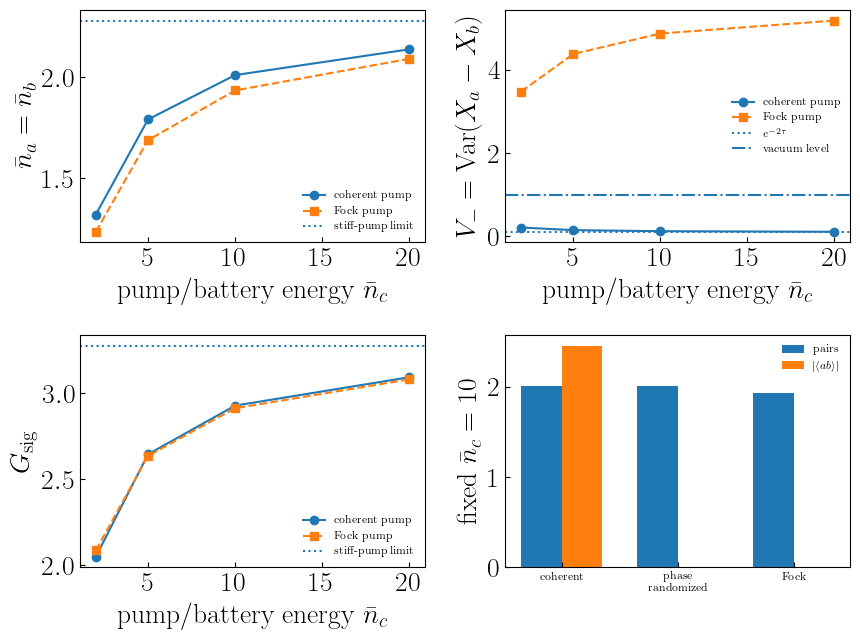

In [13]:
"""
Quantum-battery-powered nondegenerate parametric amplification
Closed trilinear model: first numerical evidence

Hamiltonian in the resonant interaction picture (hbar=1):
    H_I = i g ( c a^dag b^dag - c^dag a b )
where a is the signal mode, b is the idler mode, and c is the finite pump/battery mode.

The code uses the exact block structure of the trilinear Hamiltonian.  The two quantities
    p = n_a + n_c,   q = n_b + n_c
are conserved.  This avoids constructing the full tensor-product Hilbert space.

Conventions:
    X = (a + a^dag)/sqrt(2), P = -i(a - a^dag)/sqrt(2), vacuum variance = 1/2.
    V_- = Var(X_a - X_b) = Var(P_a + P_b) for the phase convention used here.

Author: ChatGPT, prepared for Borhan Ahmadi, 2026-05-21.
"""

from __future__ import annotations
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path


def coherent_coeffs(nmax: int, alpha: complex) -> np.ndarray:
    coeff = np.empty(nmax + 1, dtype=complex)
    coeff[0] = np.exp(-0.5 * abs(alpha) ** 2)
    for n in range(1, nmax + 1):
        coeff[n] = coeff[n - 1] * alpha / np.sqrt(n)
    return coeff / np.linalg.norm(coeff)


def fock_coeffs(nmax: int, n: int) -> np.ndarray:
    if n > nmax:
        raise ValueError("Fock index exceeds cutoff")
    coeff = np.zeros(nmax + 1, dtype=complex)
    coeff[n] = 1.0
    return coeff


def poisson_probs(nmax: int, nbar: float) -> np.ndarray:
    p = np.empty(nmax + 1, dtype=float)
    p[0] = np.exp(-nbar)
    for n in range(1, nmax + 1):
        p[n] = p[n - 1] * nbar / n
    return p / p.sum()


def block_generator(signal_fock_l: int, pump_fock_m: int) -> np.ndarray:
    """Skew-symmetric generator K = A - A^dag in a fixed (p,q) block.

    Initial block is labeled by signal photon number l and pump photon number m,
    with idler initially vacuum.  The block basis is r = n_c = 0,...,m.
    The conserved numbers are p = n_a+n_c = m+l and q = n_b+n_c = m.
    """
    l = signal_fock_l
    m = pump_fock_m
    p = m + l
    q = m
    dim = m + 1
    K = np.zeros((dim, dim), dtype=float)
    for r in range(dim):
        # A = c a^dag b^dag maps r -> r-1.
        if r >= 1:
            coeff = np.sqrt(r) * np.sqrt(p - r + 1) * np.sqrt(q - r + 1)
            K[r - 1, r] += coeff
        # -A^dag = -c^dag a b maps r -> r+1.
        if r + 1 < dim:
            coeff = np.sqrt(r + 1) * np.sqrt(p - r) * np.sqrt(q - r)
            K[r + 1, r] -= coeff
    return K


def evolve_blocks_pure(signal_coeffs: np.ndarray, pump_coeffs: np.ndarray, gt: float) -> dict[tuple[int, int, int], complex]:
    """Evolve a pure initial state |psi_a> |0_b> |psi_c>.

    Returns a sparse dictionary representation of the final pure state in the Fock basis:
        key = (n_a, n_b, n_c), value = amplitude.
    """
    out: dict[tuple[int, int, int], complex] = {}
    for l, c_l in enumerate(signal_coeffs):
        if abs(c_l) < 1e-14:
            continue
        for m, c_m in enumerate(pump_coeffs):
            amp0 = c_l * c_m
            if abs(amp0) < 1e-14:
                continue
            K = block_generator(l, m)
            e_m = np.zeros(m + 1)
            e_m[m] = 1.0
            evolved = spla.expm_multiply(sp.csr_matrix(gt * K), e_m)
            p = m + l
            q = m
            for r, amp_r in enumerate(evolved):
                if abs(amp_r) < 1e-14:
                    continue
                n_a = p - r
                n_b = q - r
                n_c = r
                key = (n_a, n_b, n_c)
                out[key] = out.get(key, 0.0j) + amp0 * amp_r
    norm = np.sqrt(sum(abs(v) ** 2 for v in out.values()))
    return {k: v / norm for k, v in out.items()}


def expect_lower(state: dict[tuple[int, int, int], complex], mode: int) -> complex:
    val = 0.0j
    for key_high, amp_high in state.items():
        ns = list(key_high)
        if ns[mode] == 0:
            continue
        coeff = np.sqrt(ns[mode])
        ns[mode] -= 1
        amp_low = state.get(tuple(ns), 0.0j)
        val += np.conjugate(amp_low) * coeff * amp_high
    return val


def expect_lower2(state: dict[tuple[int, int, int], complex], mode: int) -> complex:
    val = 0.0j
    for key_high, amp_high in state.items():
        ns = list(key_high)
        if ns[mode] < 2:
            continue
        coeff = np.sqrt(ns[mode] * (ns[mode] - 1))
        ns[mode] -= 2
        amp_low = state.get(tuple(ns), 0.0j)
        val += np.conjugate(amp_low) * coeff * amp_high
    return val


def expect_ab(state: dict[tuple[int, int, int], complex]) -> complex:
    val = 0.0j
    for (n_a, n_b, n_c), amp_high in state.items():
        if n_a == 0 or n_b == 0:
            continue
        amp_low = state.get((n_a - 1, n_b - 1, n_c), 0.0j)
        val += np.conjugate(amp_low) * np.sqrt(n_a * n_b) * amp_high
    return val


def moments_pure(state: dict[tuple[int, int, int], complex]) -> dict[str, complex | float]:
    probs = {k: abs(v) ** 2 for k, v in state.items()}
    n_a = sum(k[0] * p for k, p in probs.items())
    n_b = sum(k[1] * p for k, p in probs.items())
    n_c = sum(k[2] * p for k, p in probs.items())
    a = expect_lower(state, 0)
    b = expect_lower(state, 1)
    c = expect_lower(state, 2)
    a2 = expect_lower2(state, 0)
    ab = expect_ab(state)

    X_a = np.sqrt(2.0) * a.real
    P_a = np.sqrt(2.0) * a.imag
    var_X_a = (a2.real + n_a + 0.5) - X_a**2
    var_P_a = (-a2.real + n_a + 0.5) - P_a**2

    # For the states generated from vacuum in the phase convention used here,
    # Var(X_a-X_b)=Var(P_a+P_b)= n_a+n_b+1 - 2 Re <a b>.
    v_minus = n_a + n_b + 1.0 - 2.0 * ab.real
    v_plus = n_a + n_b + 1.0 + 2.0 * ab.real
    return dict(n_a=n_a, n_b=n_b, n_c=n_c, a=a, b=b, c=c, a2=a2, ab=ab,
                var_X_a=var_X_a, var_P_a=var_P_a, V_minus=v_minus, V_plus=v_plus)


def simulate_pure(nbar: float, pump: str, tau: float, alpha_s: complex = 0.0, Lmax: int = 0, Mmax: int | None = None) -> dict[str, float | complex]:
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))
    signal = coherent_coeffs(Lmax, alpha_s)
    if pump == "coherent":
        pump_state = coherent_coeffs(Mmax, np.sqrt(nbar))
    elif pump == "fock":
        pump_state = fock_coeffs(Mmax, int(round(nbar)))
    else:
        raise ValueError("pump must be 'coherent' or 'fock'")
    # Calibration: g sqrt(nbar) = 1, so tau is the classical two-mode squeezing parameter.
    gt = tau / np.sqrt(nbar)
    state = evolve_blocks_pure(signal, pump_state, gt)
    mom = moments_pure(state)
    mom["delta_n_c"] = nbar - mom["n_c"]
    mom["eta_c"] = abs(mom["c"]) ** 2 / mom["n_c"] if mom["n_c"] > 1e-12 else np.nan
    if abs(alpha_s) > 0:
        G = abs(mom["a"]) ** 2 / abs(alpha_s) ** 2
        Nadd = (mom["var_X_a"] + mom["var_P_a"]) / (2 * G) - 0.5
        Nql = 0.5 * (1.0 - 1.0 / G) if G > 1 else np.nan
        mom["G_sig"] = G
        mom["N_add"] = Nadd
        mom["N_QL"] = Nql
        mom["N_excess"] = Nadd - Nql if np.isfinite(Nql) else np.nan
    return mom


def simulate_phase_randomized_coherent(nbar: float, tau: float, alpha_s: complex = 0.0, Lmax: int = 0, Mmax: int | None = None) -> dict[str, float | complex]:
    """Pump state diagonal in Fock basis with Poisson weights.

    This has the same photon-number distribution as a coherent state but no phase coherence.
    For alpha_s=0 this is enough to show: same pair production, zero anomalous <ab>.
    """
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))
    probs = poisson_probs(Mmax, nbar)
    signal = coherent_coeffs(Lmax, alpha_s)
    gt = tau / np.sqrt(nbar)

    avg: dict[str, complex | float] = dict(n_a=0.0, n_b=0.0, n_c=0.0, a=0.0j, b=0.0j, c=0.0j, a2=0.0j, ab=0.0j)
    # For variances of a mixed state we average <X>, <P>, <X^2>, <P^2>.
    X = P = X2 = P2 = 0.0
    for m, p_m in enumerate(probs):
        if p_m < 1e-13:
            continue
        state_m = evolve_blocks_pure(signal, fock_coeffs(Mmax, m), gt)
        mom = moments_pure(state_m)
        for key in avg:
            avg[key] += p_m * mom[key]
        a = mom["a"]
        a2 = mom["a2"]
        n_a = mom["n_a"]
        Xm = np.sqrt(2.0) * a.real
        Pm = np.sqrt(2.0) * a.imag
        X += p_m * Xm
        P += p_m * Pm
        X2 += p_m * (a2.real + n_a + 0.5)
        P2 += p_m * (-a2.real + n_a + 0.5)

    avg["var_X_a"] = X2 - X**2
    avg["var_P_a"] = P2 - P**2
    avg["V_minus"] = avg["n_a"] + avg["n_b"] + 1.0 - 2.0 * avg["ab"].real
    avg["V_plus"] = avg["n_a"] + avg["n_b"] + 1.0 + 2.0 * avg["ab"].real
    avg["delta_n_c"] = nbar - avg["n_c"]
    avg["eta_c"] = abs(avg["c"]) ** 2 / avg["n_c"] if avg["n_c"] > 1e-12 else np.nan
    if abs(alpha_s) > 0:
        G = abs(avg["a"]) ** 2 / abs(alpha_s) ** 2
        Nadd = (avg["var_X_a"] + avg["var_P_a"]) / (2 * G) - 0.5
        Nql = 0.5 * (1.0 - 1.0 / G) if G > 1 else np.nan
        avg["G_sig"] = G
        avg["N_add"] = Nadd
        avg["N_QL"] = Nql
        avg["N_excess"] = Nadd - Nql if np.isfinite(Nql) else np.nan
    return avg


def main() -> None:
    tau = 1.2
    nbar_list = np.array([2, 5, 10, 20], dtype=float)

    classical_pairs = np.sinh(tau) ** 2
    classical_ab = np.sinh(tau) * np.cosh(tau)
    classical_Vminus = np.exp(-2 * tau)
    classical_G = np.cosh(tau) ** 2
    classical_Nql = 0.5 * (1.0 - 1.0 / classical_G)

    coherent_vac = [simulate_pure(n, "coherent", tau=tau, alpha_s=0.0, Lmax=0, Mmax=int(np.ceil(n + 6*np.sqrt(n+1) + 10))) for n in nbar_list]
    fock_vac = [simulate_pure(n, "fock", tau=tau, alpha_s=0.0, Lmax=0, Mmax=int(n + 5)) for n in nbar_list]

    coherent_sig = [simulate_pure(n, "coherent", tau=tau, alpha_s=0.2, Lmax=4, Mmax=int(np.ceil(n + 6*np.sqrt(n+1) + 10))) for n in nbar_list]
    fock_sig = [simulate_pure(n, "fock", tau=tau, alpha_s=0.2, Lmax=4, Mmax=int(n + 8)) for n in nbar_list]

    # Fixed-energy diagnostic at nbar=10.
    fixed_n = 10.0
    fixed = {
        "coherent": simulate_pure(fixed_n, "coherent", tau=tau, alpha_s=0.0, Lmax=0),
        "phase-randomized coherent": simulate_phase_randomized_coherent(fixed_n, tau=tau, alpha_s=0.0, Lmax=0),
        "Fock": simulate_pure(fixed_n, "fock", tau=tau, alpha_s=0.0, Lmax=0, Mmax=15),
    }

    print("Classical stiff-pump benchmarks")
    print(f"  tau = {tau:.3f}")
    print(f"  pair number sinh^2(tau) = {classical_pairs:.6f}")
    print(f"  anomalous correlation sinh(tau)cosh(tau) = {classical_ab:.6f}")
    print(f"  EPR squeezed variance exp(-2 tau) = {classical_Vminus:.6f}")
    print(f"  signal gain cosh^2(tau) = {classical_G:.6f}")
    print(f"  finite-gain quantum-limit added noise = {classical_Nql:.6f}\n")

    print("nbar   n_pair(coh)   |ab|(coh)   Vminus(coh)   Gsig(coh)   Nadd(coh)   excess(coh)")
    for n, rv, rs in zip(nbar_list, coherent_vac, coherent_sig):
        print(f"{n:4.0f}   {rv['n_a']:.6f}     {abs(rv['ab']):.6f}    {rv['V_minus']:.6f}     "
              f"{rs['G_sig']:.6f}    {rs['N_add']:.6f}    {rs['N_excess']:.6f}")

    print("\nFixed energy nbar=10, vacuum signal/idler")
    print("state                      n_pair       |<ab>|       Vminus       eta_c")
    for name, r in fixed.items():
        print(f"{name:26s} {r['n_a']:.6f}    {abs(r['ab']):.6f}    {r['V_minus']:.6f}    {r['eta_c']:.6f}")

    fig, axs = plt.subplots(2, 2, figsize=(9.0, 6.8))

    axs[0, 0].plot(nbar_list, [r["n_a"] for r in coherent_vac], "o-", label="coherent pump")
    axs[0, 0].plot(nbar_list, [r["n_a"] for r in fock_vac], "s--", label="Fock pump")
    axs[0, 0].axhline(classical_pairs, linestyle=":", label="stiff-pump limit")
    axs[0, 0].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[0, 0].set_ylabel(r"$\bar n_a=\bar n_b$")
    axs[0, 0].legend(frameon=False, fontsize=8)

    axs[0, 1].plot(nbar_list, [r["V_minus"] for r in coherent_vac], "o-", label="coherent pump")
    axs[0, 1].plot(nbar_list, [r["V_minus"] for r in fock_vac], "s--", label="Fock pump")
    axs[0, 1].axhline(classical_Vminus, linestyle=":", label=r"$e^{-2\tau}$")
    axs[0, 1].axhline(1.0, linestyle="-.", label="vacuum level")
    axs[0, 1].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[0, 1].set_ylabel(r"$V_-={\rm Var}(X_a-X_b)$")
    axs[0, 1].legend(frameon=False, fontsize=8)

    axs[1, 0].plot(nbar_list, [r["G_sig"] for r in coherent_sig], "o-", label="coherent pump")
    axs[1, 0].plot(nbar_list, [r["G_sig"] for r in fock_sig], "s--", label="Fock pump")
    axs[1, 0].axhline(classical_G, linestyle=":", label="stiff-pump limit")
    axs[1, 0].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[1, 0].set_ylabel(r"$G_{\rm sig}$")
    axs[1, 0].legend(frameon=False, fontsize=8)

    labels = list(fixed.keys())
    x = np.arange(len(labels))
    width = 0.35
    axs[1, 1].bar(x - width / 2, [fixed[k]["n_a"] for k in labels], width, label=r"pairs")
    axs[1, 1].bar(x + width / 2, [abs(fixed[k]["ab"]) for k in labels], width, label=r"$|\langle ab\rangle|$")
    axs[1, 1].set_xticks(x)
    axs[1, 1].set_xticklabels(["coherent", "phase\nrandomized", "Fock"], fontsize=8)
    axs[1, 1].set_ylabel(r"fixed $\bar n_c=10$")
    axs[1, 1].legend(frameon=False, fontsize=8)

    for ax in axs.flat:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_first_evidence.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

if __name__ == "__main__":
    main()

Resource scan for partially phase-randomized coherent pump batteries
tau = 1.200
C_amp = |<ab>|/sqrt(n_pair(n_pair+1)); ideal stiff-pump value = 1
V_minus vacuum level = 1; ideal stiff-pump value = exp(-2 tau)

nbar   eta_in   eta_out   C_amp   V_minus   n_pair
   5   1.000    0.977    0.9921   0.1457    1.7906
   5   0.562    0.549    0.7441   1.2546    1.7906
   5   0.250    0.244    0.4961   2.3635    1.7906
   5   0.062    0.061    0.2480   3.4724    1.7906
   5   0.000    0.000    0.0000   4.5813    1.7906
   5   Fock    0.000    0.0000   4.3766    1.6883

  10   1.000    0.994    0.9961   0.1200    2.0093
  10   0.562    0.559    0.7470   1.3447    2.0093
  10   0.250    0.249    0.4980   2.5694    2.0093
  10   0.062    0.062    0.2490   3.7940    2.0093
  10   0.000    0.000    0.0000   5.0187    2.0093
  10   Fock    0.000    0.0000   4.8672    1.9336

  20   1.000    0.999    0.9980   0.1059    2.1365
  20   0.562    0.562    0.7485   1.3976    2.1365
  20   0.250    0.250   

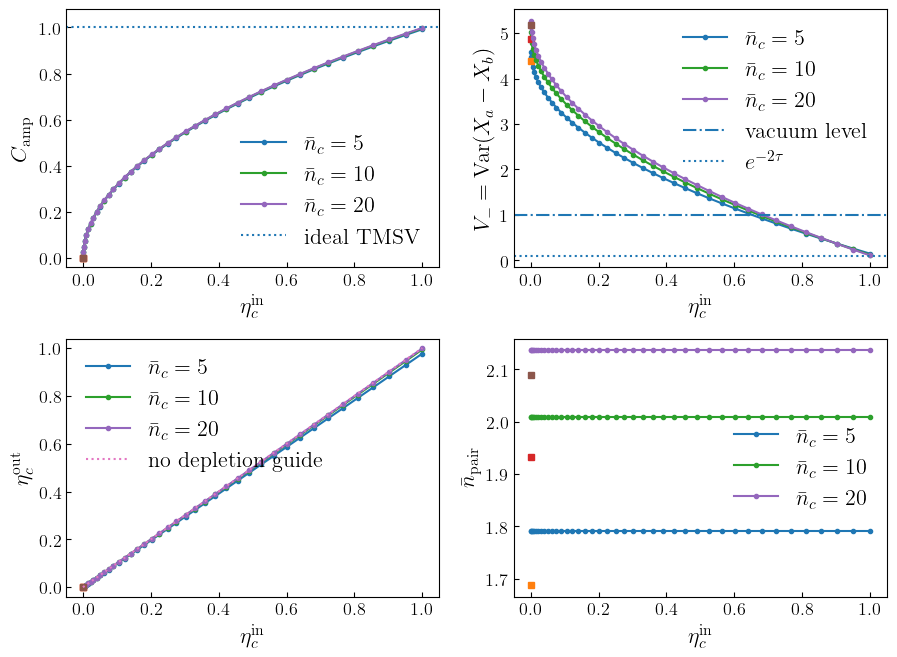

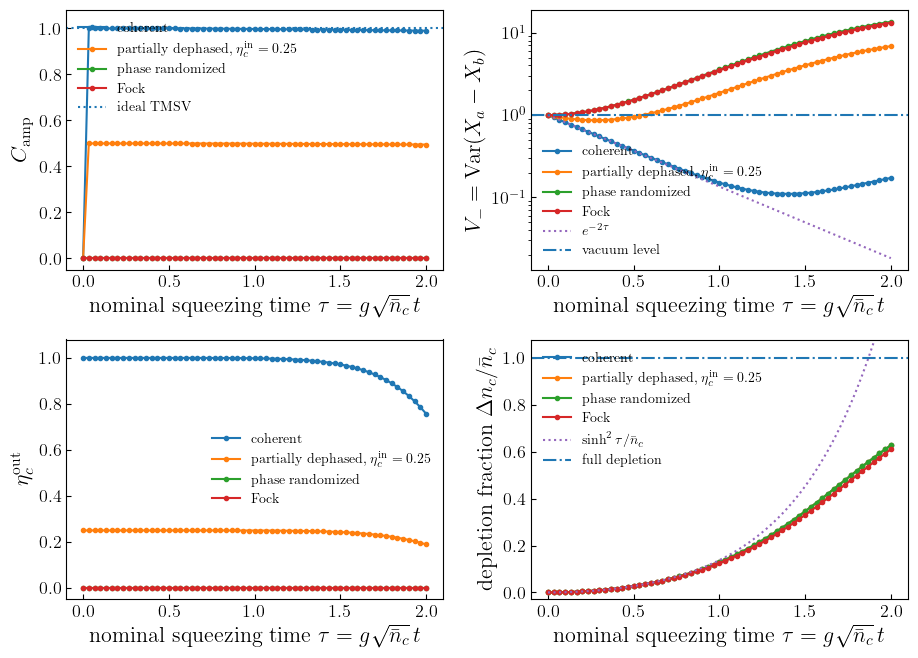

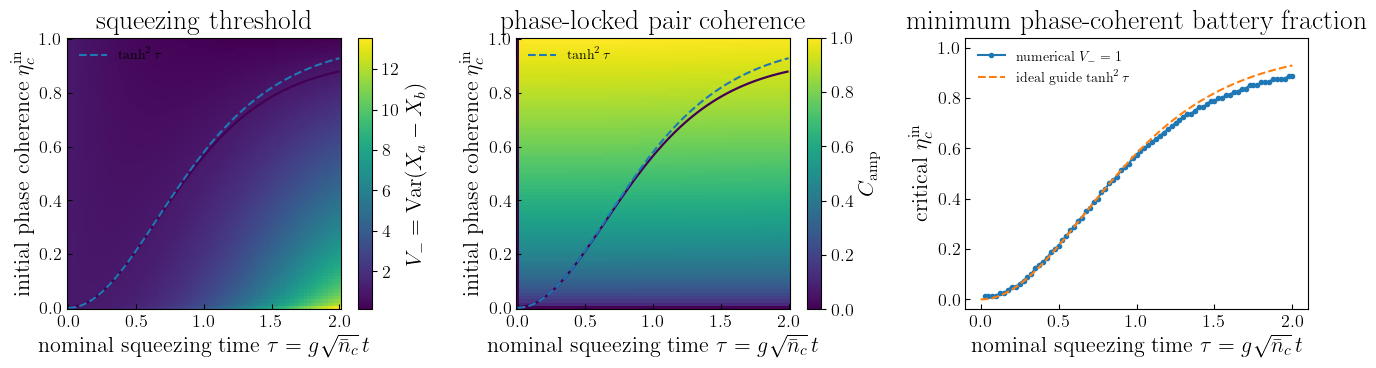

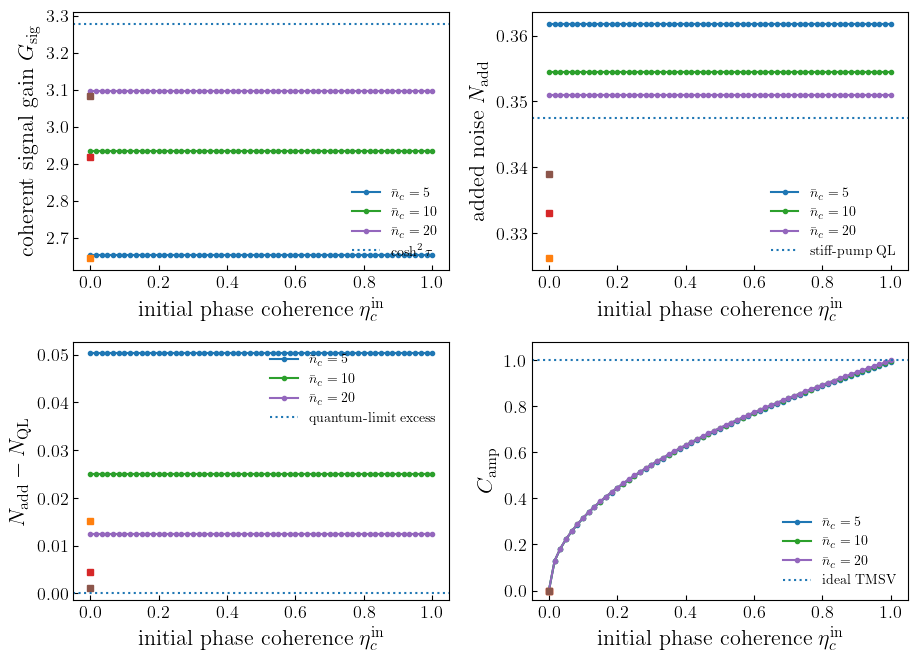

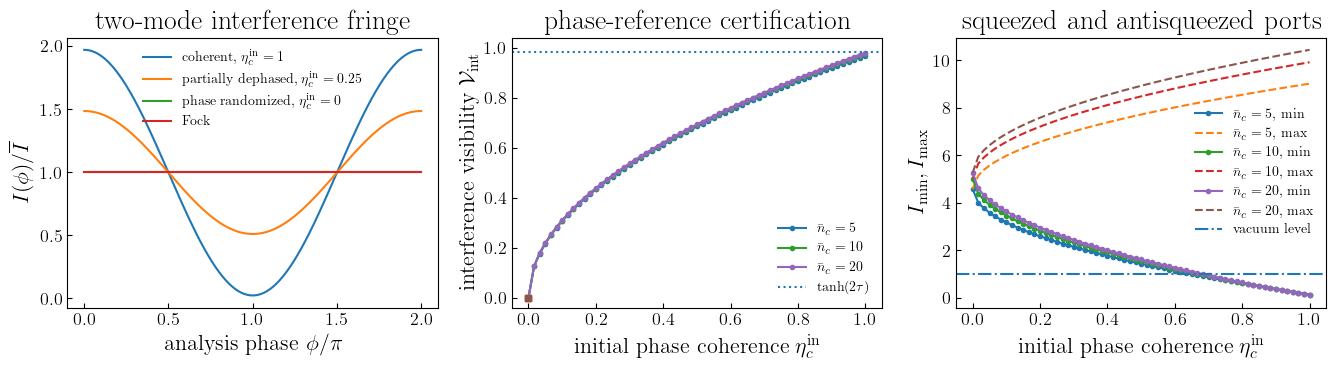

In [20]:
"""
Quantum-battery-powered nondegenerate parametric amplification
Closed trilinear model: resource plot for pump phase coherence

Hamiltonian in the resonant interaction picture (hbar=1):
    H_I = i g ( c a^dag b^dag - c^dag a b )
where a is the signal mode, b is the idler mode, and c is the finite pump/battery mode.

This script extends the first-evidence calculation by scanning a partially phase-randomized
coherent pump battery at fixed mean energy.  The scan interpolates between a fully coherent
battery and a phase-randomized coherent battery with the same photon-number distribution.

The diagnostic quantities are:
    C_amp  = |<a b>| / sqrt(n_pair (n_pair + 1)),  n_pair=(<n_a>+<n_b>)/2.
             This equals 1 for an ideal two-mode squeezed vacuum produced by a stiff pump.
    V_-    = Var(X_a - X_b), with vacuum level 1.
    eta_c  = |<c>|^2 / <c^dag c>.

Author: ChatGPT, prepared for Borhan Ahmadi, 2026-05-21.
"""

from __future__ import annotations

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from pathlib import Path


# -----------------------------------------------------------------------------
# Basic state constructors
# -----------------------------------------------------------------------------

def coherent_coeffs(nmax: int, alpha: complex) -> np.ndarray:
    coeff = np.empty(nmax + 1, dtype=complex)
    coeff[0] = np.exp(-0.5 * abs(alpha) ** 2)
    for n in range(1, nmax + 1):
        coeff[n] = coeff[n - 1] * alpha / np.sqrt(n)
    return coeff / np.linalg.norm(coeff)


def fock_coeffs(nmax: int, n: int) -> np.ndarray:
    if n > nmax:
        raise ValueError("Fock index exceeds cutoff")
    coeff = np.zeros(nmax + 1, dtype=complex)
    coeff[n] = 1.0
    return coeff


def poisson_probs(nmax: int, nbar: float) -> np.ndarray:
    p = np.empty(nmax + 1, dtype=float)
    p[0] = np.exp(-nbar)
    for n in range(1, nmax + 1):
        p[n] = p[n - 1] * nbar / n
    return p / p.sum()


# -----------------------------------------------------------------------------
# Exact block evolution under H_I = i g (c a^dag b^dag - c^dag a b)
# -----------------------------------------------------------------------------

def block_generator(signal_fock_l: int, pump_fock_m: int) -> np.ndarray:
    """Skew-symmetric generator K=A-A^dag in a fixed block.

    Initial block is labelled by signal photon number l and pump photon number m,
    with the idler initially in vacuum.  The conserved quantities are
        p = n_a+n_c = m+l,   q = n_b+n_c = m.
    The block basis is r=n_c=0,...,m.
    """
    l = signal_fock_l
    m = pump_fock_m
    p = m + l
    q = m
    dim = m + 1
    K = np.zeros((dim, dim), dtype=float)

    for r in range(dim):
        # A = c a^dag b^dag maps r -> r-1.
        if r >= 1:
            coeff = np.sqrt(r) * np.sqrt(p - r + 1) * np.sqrt(q - r + 1)
            K[r - 1, r] += coeff

        # -A^dag = -c^dag a b maps r -> r+1.
        if r + 1 < dim:
            coeff = np.sqrt(r + 1) * np.sqrt(p - r) * np.sqrt(q - r)
            K[r + 1, r] -= coeff

    return K


def evolve_blocks_pure(
    signal_coeffs: np.ndarray,
    pump_coeffs: np.ndarray,
    gt: float,
) -> dict[tuple[int, int, int], complex]:
    """Evolve a pure initial state |psi_a>|0_b>|psi_c>.

    Returns a sparse dictionary representation of the final pure state in the Fock basis:
        key = (n_a, n_b, n_c), value = amplitude.
    """
    out: dict[tuple[int, int, int], complex] = {}

    for l, c_l in enumerate(signal_coeffs):
        if abs(c_l) < 1e-14:
            continue

        for m, c_m in enumerate(pump_coeffs):
            amp0 = c_l * c_m
            if abs(amp0) < 1e-14:
                continue

            K = block_generator(l, m)
            e_m = np.zeros(m + 1)
            e_m[m] = 1.0
            evolved = spla.expm_multiply(sp.csr_matrix(gt * K), e_m)

            p = m + l
            q = m
            for r, amp_r in enumerate(evolved):
                if abs(amp_r) < 1e-14:
                    continue
                n_a = p - r
                n_b = q - r
                n_c = r
                key = (n_a, n_b, n_c)
                out[key] = out.get(key, 0.0j) + amp0 * amp_r

    norm = np.sqrt(sum(abs(v) ** 2 for v in out.values()))
    return {k: v / norm for k, v in out.items()}


# -----------------------------------------------------------------------------
# Moments for pure evolved states
# -----------------------------------------------------------------------------

def expect_lower(state: dict[tuple[int, int, int], complex], mode: int) -> complex:
    val = 0.0j
    for key_high, amp_high in state.items():
        ns = list(key_high)
        if ns[mode] == 0:
            continue
        coeff = np.sqrt(ns[mode])
        ns[mode] -= 1
        amp_low = state.get(tuple(ns), 0.0j)
        val += np.conjugate(amp_low) * coeff * amp_high
    return val


def expect_lower2(state: dict[tuple[int, int, int], complex], mode: int) -> complex:
    val = 0.0j
    for key_high, amp_high in state.items():
        ns = list(key_high)
        if ns[mode] < 2:
            continue
        coeff = np.sqrt(ns[mode] * (ns[mode] - 1))
        ns[mode] -= 2
        amp_low = state.get(tuple(ns), 0.0j)
        val += np.conjugate(amp_low) * coeff * amp_high
    return val


def expect_ab(state: dict[tuple[int, int, int], complex]) -> complex:
    val = 0.0j
    for (n_a, n_b, n_c), amp_high in state.items():
        if n_a == 0 or n_b == 0:
            continue
        amp_low = state.get((n_a - 1, n_b - 1, n_c), 0.0j)
        val += np.conjugate(amp_low) * np.sqrt(n_a * n_b) * amp_high
    return val


def moments_pure(state: dict[tuple[int, int, int], complex]) -> dict[str, complex | float]:
    probs = {k: abs(v) ** 2 for k, v in state.items()}
    n_a = sum(k[0] * p for k, p in probs.items())
    n_b = sum(k[1] * p for k, p in probs.items())
    n_c = sum(k[2] * p for k, p in probs.items())

    a = expect_lower(state, 0)
    b = expect_lower(state, 1)
    c = expect_lower(state, 2)
    a2 = expect_lower2(state, 0)
    ab = expect_ab(state)

    X_a = np.sqrt(2.0) * a.real
    P_a = np.sqrt(2.0) * a.imag
    var_X_a = (a2.real + n_a + 0.5) - X_a**2
    var_P_a = (-a2.real + n_a + 0.5) - P_a**2

    out = dict(
        n_a=n_a,
        n_b=n_b,
        n_c=n_c,
        a=a,
        b=b,
        c=c,
        a2=a2,
        ab=ab,
        var_X_a=var_X_a,
        var_P_a=var_P_a,
    )
    return add_diagnostics(out)


# -----------------------------------------------------------------------------
# Mixed-state helper routines and diagnostics
# -----------------------------------------------------------------------------

def add_diagnostics(mom: dict[str, complex | float]) -> dict[str, complex | float]:
    """Add V_-, V_+, eta_c, and C_amp diagnostics to a moment dictionary."""
    n_a = float(np.real(mom["n_a"]))
    n_b = float(np.real(mom["n_b"]))
    n_c = float(np.real(mom["n_c"]))
    ab = complex(mom["ab"])
    c = complex(mom["c"])

    # Phase convention: for the coherent pump chosen here, <ab> is real and positive.
    # More generally one can minimize over the analysis phase and replace Re <ab> by |<ab>|.
    mom["V_minus"] = n_a + n_b + 1.0 - 2.0 * ab.real
    mom["V_plus"] = n_a + n_b + 1.0 + 2.0 * ab.real
    mom["V_minus_opt"] = n_a + n_b + 1.0 - 2.0 * abs(ab)
    mom["eta_c"] = abs(c) ** 2 / n_c if n_c > 1e-14 else np.nan

    # Normalized anomalous pair coherence. For an ideal two-mode squeezed vacuum,
    # |<ab>|=sqrt(n_pair(n_pair+1)), so C_amp=1.
    n_pair = 0.5 * (n_a + n_b)
    mom["n_pair"] = n_pair
    if n_pair > 1e-14:
        mom["C_amp"] = abs(ab) / np.sqrt(n_pair * (n_pair + 1.0))
    else:
        mom["C_amp"] = np.nan
    return mom


def mix_moments(m1: dict[str, complex | float], m2: dict[str, complex | float], weight_1: float) -> dict[str, complex | float]:
    """Convexly mix two moment dictionaries and recompute nonlinear diagnostics.

    The mixed state is rho = weight_1 rho_1 + (1-weight_1) rho_2.
    """
    w = weight_1
    raw_keys = ["n_a", "n_b", "n_c", "a", "b", "c", "a2", "ab", "var_X_a", "var_P_a"]
    mixed = {key: w * m1[key] + (1.0 - w) * m2[key] for key in raw_keys}
    return add_diagnostics(mixed)


def simulate_pure(
    nbar: float,
    pump: str,
    tau: float,
    alpha_s: complex = 0.0,
    Lmax: int = 0,
    Mmax: int | None = None,
) -> dict[str, float | complex]:
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    signal = coherent_coeffs(Lmax, alpha_s)
    if pump == "coherent":
        pump_state = coherent_coeffs(Mmax, np.sqrt(nbar))
    elif pump == "fock":
        pump_state = fock_coeffs(Mmax, int(round(nbar)))
    else:
        raise ValueError("pump must be 'coherent' or 'fock'")

    # Calibration: g sqrt(nbar)=1, so tau is the nominal classical squeezing parameter.
    gt = tau / np.sqrt(nbar)
    state = evolve_blocks_pure(signal, pump_state, gt)
    mom = moments_pure(state)
    mom["delta_n_c"] = nbar - mom["n_c"]
    return mom


def simulate_phase_randomized_coherent(
    nbar: float,
    tau: float,
    alpha_s: complex = 0.0,
    Lmax: int = 0,
    Mmax: int | None = None,
) -> dict[str, float | complex]:
    """Pump diagonal in Fock basis with Poisson weights.

    This has the same photon-number distribution as a coherent state but no first-order
    phase coherence.
    """
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    probs = poisson_probs(Mmax, nbar)
    signal = coherent_coeffs(Lmax, alpha_s)
    gt = tau / np.sqrt(nbar)

    # Average raw moments over the Poisson mixture.
    raw = dict(n_a=0.0, n_b=0.0, n_c=0.0, a=0.0j, b=0.0j, c=0.0j, a2=0.0j, ab=0.0j)

    # Correct mixed-state variances for the signal mode: average <X^2>, <P^2>, then subtract averaged means.
    X = P = X2 = P2 = 0.0

    for m, p_m in enumerate(probs):
        if p_m < 1e-13:
            continue
        state_m = evolve_blocks_pure(signal, fock_coeffs(Mmax, m), gt)
        mom = moments_pure(state_m)
        for key in raw:
            raw[key] += p_m * mom[key]

        a = complex(mom["a"])
        a2 = complex(mom["a2"])
        n_a = float(np.real(mom["n_a"]))
        Xm = np.sqrt(2.0) * a.real
        Pm = np.sqrt(2.0) * a.imag
        X += p_m * Xm
        P += p_m * Pm
        X2 += p_m * (a2.real + n_a + 0.5)
        P2 += p_m * (-a2.real + n_a + 0.5)

    raw["var_X_a"] = X2 - X**2
    raw["var_P_a"] = P2 - P**2
    mom = add_diagnostics(raw)
    mom["delta_n_c"] = nbar - mom["n_c"]
    return mom


def partially_dephased_family(nbar: float, tau: float, q_values: np.ndarray) -> list[dict[str, float | complex]]:
    """Family rho_c(0)=(1-q)|alpha><alpha| + q rho_phase-randomized.

    The mean energy is fixed at nbar for all q.  The initial battery coherence fraction is
        eta_c_initial = |<c>_0|^2/<n_c>_0 = (1-q)^2.
    """
    Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))
    coherent = simulate_pure(nbar, "coherent", tau=tau, alpha_s=0.0, Lmax=0, Mmax=Mmax)
    dephased = simulate_phase_randomized_coherent(nbar, tau=tau, alpha_s=0.0, Lmax=0, Mmax=Mmax)

    family = []
    for q in q_values:
        # weight of the coherent component is 1-q.
        mom = mix_moments(coherent, dephased, weight_1=1.0 - q)
        mom["q_dephase"] = q
        mom["eta_c_initial"] = (1.0 - q) ** 2
        family.append(mom)
    return family


# -----------------------------------------------------------------------------
# Main plotting routine
# -----------------------------------------------------------------------------

def main() -> None:
    tau = 1.2
    nbar_list = [5.0, 10.0, 20.0]
    q_values = np.linspace(0.0, 1.0, 41)

    classical_Vminus = np.exp(-2 * tau)

    families = {nbar: partially_dephased_family(nbar, tau, q_values) for nbar in nbar_list}
    fock_points = {
        nbar: simulate_pure(nbar, "fock", tau=tau, alpha_s=0.0, Lmax=0, Mmax=int(nbar + 8))
        for nbar in nbar_list
    }

    print("Resource scan for partially phase-randomized coherent pump batteries")
    print(f"tau = {tau:.3f}")
    print("C_amp = |<ab>|/sqrt(n_pair(n_pair+1)); ideal stiff-pump value = 1")
    print("V_minus vacuum level = 1; ideal stiff-pump value = exp(-2 tau)")
    print()
    print("nbar   eta_in   eta_out   C_amp   V_minus   n_pair")
    for nbar in nbar_list:
        for idx in [0, 10, 20, 30, 40]:
            r = families[nbar][idx]
            print(
                f"{nbar:4.0f}   {r['eta_c_initial']:.3f}    {r['eta_c']:.3f}    "
                f"{r['C_amp']:.4f}   {r['V_minus']:.4f}    {r['n_pair']:.4f}"
            )
        fp = fock_points[nbar]
        print(
            f"{nbar:4.0f}   Fock    {fp['eta_c']:.3f}    "
            f"{fp['C_amp']:.4f}   {fp['V_minus']:.4f}    {fp['n_pair']:.4f}"
        )
        print()

    fig, axs = plt.subplots(2, 2, figsize=(9.2, 6.8))

    for nbar in nbar_list:
        fam = families[nbar]
        eta_in = np.array([r["eta_c_initial"] for r in fam])
        # q increases, eta decreases. Sort by eta for visually clean curves.
        order = np.argsort(eta_in)
        eta = eta_in[order]
        C = np.array([r["C_amp"] for r in fam])[order]
        V = np.array([r["V_minus"] for r in fam])[order]
        eta_out = np.array([r["eta_c"] for r in fam])[order]
        n_pair = np.array([r["n_pair"] for r in fam])[order]

        label = rf"$\bar n_c={int(nbar)}$"
        axs[0, 0].plot(eta, C, "o-", ms=3, label=label)
        axs[0, 1].plot(eta, V, "o-", ms=3, label=label)
        axs[1, 0].plot(eta, eta_out, "o-", ms=3, label=label)
        axs[1, 1].plot(eta, n_pair, "o-", ms=3, label=label)

        # Fock pump marker: same nominal energy, eta=0, no anomalous phase coherence.
        fp = fock_points[nbar]
        axs[0, 0].plot(0.0, fp["C_amp"], "s", ms=5)
        axs[0, 1].plot(0.0, fp["V_minus"], "s", ms=5)
        axs[1, 0].plot(0.0, fp["eta_c"], "s", ms=5)
        axs[1, 1].plot(0.0, fp["n_pair"], "s", ms=5)

    axs[0, 0].axhline(1.0, linestyle=":", label="ideal TMSV")
    axs[0, 0].set_xlabel(r"$\eta_c^{\rm in}$")
    axs[0, 0].set_ylabel(r"$C_{\rm amp}$")
    axs[0, 0].set_ylim(-0.04, 1.08)

    axs[0, 1].axhline(1.0, linestyle="-.", label="vacuum level")
    axs[0, 1].axhline(classical_Vminus, linestyle=":", label=rf"$e^{{-2\tau}}$")
    axs[0, 1].set_xlabel(r"$\eta_c^{\rm in}$")
    axs[0, 1].set_ylabel(r"$V_-={\rm Var}(X_a-X_b)$")

    axs[1, 0].plot([0, 1], [0, 1], linestyle=":", label="no depletion guide")
    axs[1, 0].set_xlabel(r"$\eta_c^{\rm in}$")
    axs[1, 0].set_ylabel(r"$\eta_c^{\rm out}$")
    axs[1, 0].set_ylim(-0.04, 1.04)

    axs[1, 1].set_xlabel(r"$\eta_c^{\rm in}$")
    axs[1, 1].set_ylabel(r"$\bar n_{\rm pair}$")

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False, fontsize=16)

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)
    pdf_path = outdir / "qb_paramp_resource_plot.pdf"
    png_path = outdir / "qb_paramp_resource_plot.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved resource plot to:\n  {pdf_path}\n")


if __name__ == "__main__":
    main()

# -----------------------------------------------------------------------------
# Time-domain resource/back-action scan
# -----------------------------------------------------------------------------

def partially_dephased_moment(
    nbar: float,
    tau: float,
    q_dephase: float,
    Mmax: int | None = None,
) -> dict[str, float | complex]:
    """Single time point for rho_c=(1-q)|alpha><alpha|+q rho_phase-randomized.

    q=0 gives a coherent pump battery.
    q=1 gives a fully phase-randomized coherent pump battery.
    The initial coherence fraction is eta_c_initial=(1-q)^2.
    """
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    coherent = simulate_pure(
        nbar,
        "coherent",
        tau=tau,
        alpha_s=0.0,
        Lmax=0,
        Mmax=Mmax,
    )

    dephased = simulate_phase_randomized_coherent(
        nbar,
        tau=tau,
        alpha_s=0.0,
        Lmax=0,
        Mmax=Mmax,
    )

    mom = mix_moments(coherent, dephased, weight_1=1.0 - q_dephase)
    mom["q_dephase"] = q_dephase
    mom["eta_c_initial"] = (1.0 - q_dephase) ** 2
    mom["delta_n_c"] = nbar - mom["n_c"]
    return mom


def time_domain_resource_scan(
    nbar: float = 10.0,
    tau_max: float = 2.0,
    n_tau: int = 61,
    q_partial: float = 0.5,
) -> dict[str, object]:
    """Scan C_amp, V_minus, eta_c, and depletion versus nominal squeezing time tau.

    tau = g sqrt(nbar) t is the nominal classical squeezing parameter.
    """
    tau_grid = np.linspace(0.0, tau_max, n_tau)
    Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    data: dict[str, list[dict[str, float | complex]]] = {
        "coherent": [],
        rf"partially dephased, $\eta_c^{{\rm in}}={(1.0-q_partial)**2:.2f}$": [],
        "phase randomized": [],
        "Fock": [],
    }

    for tau in tau_grid:
        data["coherent"].append(
            simulate_pure(
                nbar,
                "coherent",
                tau=tau,
                alpha_s=0.0,
                Lmax=0,
                Mmax=Mmax,
            )
        )

        data[rf"partially dephased, $\eta_c^{{\rm in}}={(1.0-q_partial)**2:.2f}$"].append(
            partially_dephased_moment(
                nbar=nbar,
                tau=tau,
                q_dephase=q_partial,
                Mmax=Mmax,
            )
        )

        data["phase randomized"].append(
            simulate_phase_randomized_coherent(
                nbar,
                tau=tau,
                alpha_s=0.0,
                Lmax=0,
                Mmax=Mmax,
            )
        )

        data["Fock"].append(
            simulate_pure(
                nbar,
                "fock",
                tau=tau,
                alpha_s=0.0,
                Lmax=0,
                Mmax=int(nbar + 8),
            )
        )

    return {
        "tau_grid": tau_grid,
        "nbar": nbar,
        "q_partial": q_partial,
        "data": data,
    }


def _as_real_array(records: list[dict[str, float | complex]], key: str) -> np.ndarray:
    arr = np.array([np.real(r[key]) for r in records], dtype=float)
    arr[~np.isfinite(arr)] = 0.0
    return arr


def main_time_domain() -> None:
    nbar = 10.0
    tau_max = 2.0
    n_tau = 61
    q_partial = 0.5

    scan = time_domain_resource_scan(
        nbar=nbar,
        tau_max=tau_max,
        n_tau=n_tau,
        q_partial=q_partial,
    )

    tau_grid = scan["tau_grid"]
    data = scan["data"]

    classical_Vminus = np.exp(-2.0 * tau_grid)
    classical_pairs = np.sinh(tau_grid) ** 2

    print("Time-domain resource/back-action scan")
    print(f"nbar = {nbar:.0f}")
    print(f"tau range = [0, {tau_max}]")
    print("tau = g sqrt(nbar) t")
    print()
    print("state                          tau     C_amp    V_minus    eta_c     delta_n_c/nbar")
    for name, records in data.items():
        for idx in [0, n_tau // 4, n_tau // 2, 3 * n_tau // 4, n_tau - 1]:
            r = records[idx]
            depletion_fraction = float(np.real(r["delta_n_c"])) / nbar
            print(
                f"{name:30s} {tau_grid[idx]:.3f}   "
                f"{float(np.real(r['C_amp'])):.4f}   "
                f"{float(np.real(r['V_minus'])):.4f}   "
                f"{float(np.real(r['eta_c'])):.4f}   "
                f"{depletion_fraction:.4f}"
            )
        print()

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(2, 2, figsize=(9.4, 6.8))

    for name, records in data.items():
        C = _as_real_array(records, "C_amp")
        V = _as_real_array(records, "V_minus")
        eta = _as_real_array(records, "eta_c")
        delta_frac = _as_real_array(records, "delta_n_c") / nbar

        axs[0, 0].plot(tau_grid, C, "o-", ms=3, label=name)
        axs[0, 1].plot(tau_grid, V, "o-", ms=3, label=name)
        axs[1, 0].plot(tau_grid, eta, "o-", ms=3, label=name)
        axs[1, 1].plot(tau_grid, delta_frac, "o-", ms=3, label=name)

    axs[0, 0].axhline(1.0, linestyle=":", label="ideal TMSV")
    axs[0, 0].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[0, 0].set_ylabel(r"$C_{\rm amp}$")
    axs[0, 0].set_ylim(-0.05, 1.08)

    axs[0, 1].plot(tau_grid, classical_Vminus, linestyle=":", label=r"$e^{-2\tau}$")
    axs[0, 1].axhline(1.0, linestyle="-.", label="vacuum level")
    axs[0, 1].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[0, 1].set_ylabel(r"$V_-={\rm Var}(X_a-X_b)$")
    axs[0, 1].set_yscale("log")

    axs[1, 0].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[1, 0].set_ylabel(r"$\eta_c^{\rm out}$")
    axs[1, 0].set_ylim(-0.05, 1.08)

    axs[1, 1].plot(tau_grid, classical_pairs / nbar, linestyle=":", label=r"$\sinh^2\tau/\bar n_c$")
    axs[1, 1].axhline(1.0, linestyle="-.", label="full depletion")
    axs[1, 1].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[1, 1].set_ylabel(r"depletion fraction $\Delta n_c/\bar n_c$")
    axs[1, 1].set_ylim(-0.03, 1.08)

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False)

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_time_domain_resource.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved time-domain resource plot to:\n  {pdf_path}")


if __name__ == "__main__":
    main_time_domain()

# -----------------------------------------------------------------------------
# Phase-coherence threshold diagram
# -----------------------------------------------------------------------------

def phase_coherence_threshold_scan(
    nbar: float = 10.0,
    tau_max: float = 2.0,
    n_tau: int = 81,
    n_eta: int = 81,
) -> dict[str, np.ndarray]:
    """Scan the partially dephased coherent battery family over (tau, eta_in).

    eta_in = |<c>_0|^2/<n_c>_0 = w^2, where w is the coherent weight in
        rho_c(0) = w |alpha><alpha| + (1-w) rho_phase-randomized.

    This is the cleanest phase-reference resource diagram because all points have
    the same initial mean battery energy nbar and the same photon-number distribution.
    """
    tau_grid = np.linspace(0.0, tau_max, n_tau)
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    C_map = np.zeros((n_eta, n_tau))
    V_map = np.zeros((n_eta, n_tau))
    eta_out_map = np.zeros((n_eta, n_tau))
    n_pair_map = np.zeros((n_eta, n_tau))
    depletion_map = np.zeros((n_eta, n_tau))

    for j, tau in enumerate(tau_grid):
        coherent = simulate_pure(
            nbar,
            "coherent",
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=Mmax,
        )

        dephased = simulate_phase_randomized_coherent(
            nbar,
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=Mmax,
        )

        for i, eta_in in enumerate(eta_grid):
            w = np.sqrt(eta_in)
            mom = mix_moments(coherent, dephased, weight_1=w)
            mom["delta_n_c"] = nbar - mom["n_c"]

            C_map[i, j] = np.nan_to_num(float(np.real(mom["C_amp"])), nan=0.0)
            V_map[i, j] = float(np.real(mom["V_minus"]))
            eta_out_map[i, j] = np.nan_to_num(float(np.real(mom["eta_c"])), nan=0.0)
            n_pair_map[i, j] = float(np.real(mom["n_pair"]))
            depletion_map[i, j] = float(np.real(mom["delta_n_c"])) / nbar

    # Numerical squeezing threshold: smallest eta_in such that V_- < 1.
    eta_threshold = np.full_like(tau_grid, np.nan, dtype=float)
    for j in range(n_tau):
        squeezed = V_map[:, j] < 1.0
        if np.any(squeezed):
            eta_threshold[j] = eta_grid[np.argmax(squeezed)]

    return {
        "nbar": np.array(nbar),
        "tau_grid": tau_grid,
        "eta_grid": eta_grid,
        "C_map": C_map,
        "V_map": V_map,
        "eta_out_map": eta_out_map,
        "n_pair_map": n_pair_map,
        "depletion_map": depletion_map,
        "eta_threshold": eta_threshold,
    }


def main_phase_coherence_threshold() -> None:
    nbar = 10.0
    tau_max = 2.0

    scan = phase_coherence_threshold_scan(
        nbar=nbar,
        tau_max=tau_max,
        n_tau=81,
        n_eta=81,
    )

    tau_grid = scan["tau_grid"]
    eta_grid = scan["eta_grid"]
    T, E = np.meshgrid(tau_grid, eta_grid)

    C_map = scan["C_map"]
    V_map = scan["V_map"]
    eta_threshold = scan["eta_threshold"]

    eta_ideal = np.tanh(tau_grid) ** 2

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.4, 3.9))

    # Panel 1: V_minus resource phase diagram
    im0 = axs[0].pcolormesh(
        T,
        E,
        V_map,
        shading="auto",
    )
    cbar0 = fig.colorbar(im0, ax=axs[0])
    cbar0.set_label(r"$V_-={\rm Var}(X_a-X_b)$")

    axs[0].contour(
        T,
        E,
        V_map,
        levels=[1.0],
        linewidths=1.6,
    )
    axs[0].plot(
        tau_grid,
        eta_ideal,
        linestyle="--",
        label=r"$\tanh^2\tau$",
    )
    axs[0].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[0].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[0].set_title(r"squeezing threshold")
    axs[0].legend(frameon=False)

    # Panel 2: amplifier pair coherence
    im1 = axs[1].pcolormesh(
        T,
        E,
        C_map,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )
    cbar1 = fig.colorbar(im1, ax=axs[1])
    cbar1.set_label(r"$C_{\rm amp}$")

    axs[1].contour(
        T,
        E,
        V_map,
        levels=[1.0],
        linewidths=1.6,
    )
    axs[1].plot(
        tau_grid,
        eta_ideal,
        linestyle="--",
        label=r"$\tanh^2\tau$",
    )
    axs[1].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[1].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1].set_title(r"phase-locked pair coherence")
    axs[1].legend(frameon=False)

    # Panel 3: extracted threshold
    axs[2].plot(
        tau_grid,
        eta_threshold,
        "o-",
        ms=3,
        label=r"numerical $V_-=1$",
    )
    axs[2].plot(
        tau_grid,
        eta_ideal,
        linestyle="--",
        label=r"ideal guide $\tanh^2\tau$",
    )
    axs[2].set_xlabel(r"nominal squeezing time $\tau=g\sqrt{\bar n_c}\,t$")
    axs[2].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[2].set_ylim(-0.04, 1.04)
    axs[2].set_title(r"minimum phase-coherent battery fraction")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_phase_coherence_threshold.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved phase-coherence threshold plot to:\n  {pdf_path}")


if __name__ == "__main__":
    main_phase_coherence_threshold()

# -----------------------------------------------------------------------------
# Seeded amplification resource scan
# -----------------------------------------------------------------------------

def complete_moments_from_raw(raw: dict[str, complex | float]) -> dict[str, complex | float]:
    """Complete a raw moment dictionary by computing variances and diagnostics.

    This is safer than mixing precomputed variances, because variances are nonlinear
    in first moments.  Use this for seeded partially dephased mixtures.
    """
    n_a = float(np.real(raw["n_a"]))
    a = complex(raw["a"])
    a2 = complex(raw["a2"])

    X_a = np.sqrt(2.0) * a.real
    P_a = np.sqrt(2.0) * a.imag

    X2_a = a2.real + n_a + 0.5
    P2_a = -a2.real + n_a + 0.5

    raw["var_X_a"] = X2_a - X_a**2
    raw["var_P_a"] = P2_a - P_a**2

    return add_diagnostics(raw)


def mix_moments_consistent(
    m1: dict[str, complex | float],
    m2: dict[str, complex | float],
    weight_1: float,
) -> dict[str, complex | float]:
    """Convex mixture rho = weight_1 rho_1 + (1-weight_1) rho_2.

    We mix only linear moments and recompute variances afterward.
    """
    w = weight_1
    raw_keys = ["n_a", "n_b", "n_c", "a", "b", "c", "a2", "ab"]
    raw = {key: w * m1[key] + (1.0 - w) * m2[key] for key in raw_keys}
    return complete_moments_from_raw(raw)


def add_seeded_amplifier_diagnostics(
    mom: dict[str, complex | float],
    alpha_s: complex,
) -> dict[str, complex | float]:
    """Add coherent signal gain and phase-preserving added-noise diagnostics."""
    if abs(alpha_s) <= 0:
        raise ValueError("alpha_s must be nonzero for seeded amplification diagnostics.")

    G_sig = abs(complex(mom["a"]))**2 / abs(alpha_s)**2

    if G_sig > 1e-14:
        N_add = (float(np.real(mom["var_X_a"])) + float(np.real(mom["var_P_a"]))) / (2.0 * G_sig) - 0.5
    else:
        N_add = np.nan

    N_QL = 0.5 * (1.0 - 1.0 / G_sig) if G_sig > 1.0 else np.nan

    mom["G_sig"] = G_sig
    mom["N_add"] = N_add
    mom["N_QL"] = N_QL
    mom["N_excess"] = N_add - N_QL if np.isfinite(N_add) and np.isfinite(N_QL) else np.nan

    return mom


def seeded_partially_dephased_family(
    nbar: float,
    tau: float,
    eta_values: np.ndarray,
    alpha_s: complex = 0.1,
    Lmax: int = 5,
) -> list[dict[str, float | complex]]:
    """Seeded amplification scan at fixed nbar and tau.

    eta_in = |<c>_0|^2/<n_c>_0 = w^2.
    The pump family has the same photon-number distribution for all eta_in:
        rho_c = w |alpha><alpha| + (1-w) rho_phase-randomized,
    where w=sqrt(eta_in).
    """
    Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    coherent = simulate_pure(
        nbar,
        "coherent",
        tau=tau,
        alpha_s=alpha_s,
        Lmax=Lmax,
        Mmax=Mmax,
    )

    dephased = simulate_phase_randomized_coherent(
        nbar,
        tau=tau,
        alpha_s=alpha_s,
        Lmax=Lmax,
        Mmax=Mmax,
    )

    family = []
    for eta_in in eta_values:
        w = np.sqrt(eta_in)
        mom = mix_moments_consistent(coherent, dephased, weight_1=w)
        mom["eta_c_initial"] = eta_in
        mom["delta_n_c"] = nbar - mom["n_c"]
        mom = add_seeded_amplifier_diagnostics(mom, alpha_s=alpha_s)
        family.append(mom)

    return family


def seeded_fock_point(
    nbar: float,
    tau: float,
    alpha_s: complex = 0.1,
    Lmax: int = 5,
) -> dict[str, float | complex]:
    mom = simulate_pure(
        nbar,
        "fock",
        tau=tau,
        alpha_s=alpha_s,
        Lmax=Lmax,
        Mmax=int(nbar + Lmax + 10),
    )
    mom = add_seeded_amplifier_diagnostics(mom, alpha_s=alpha_s)
    mom["eta_c_initial"] = 0.0
    return mom


def main_seeded_amplification_resource() -> None:
    tau = 1.2
    alpha_s = 0.1
    Lmax = 5
    nbar_list = [5.0, 10.0, 20.0]
    eta_values = np.linspace(0.0, 1.0, 61)

    classical_G = np.cosh(tau) ** 2
    classical_N_QL = 0.5 * (1.0 - 1.0 / classical_G)
    classical_Vminus = np.exp(-2.0 * tau)

    families = {
        nbar: seeded_partially_dephased_family(
            nbar=nbar,
            tau=tau,
            eta_values=eta_values,
            alpha_s=alpha_s,
            Lmax=Lmax,
        )
        for nbar in nbar_list
    }

    fock_points = {
        nbar: seeded_fock_point(
            nbar=nbar,
            tau=tau,
            alpha_s=alpha_s,
            Lmax=Lmax,
        )
        for nbar in nbar_list
    }

    print("Seeded amplification resource scan")
    print(f"tau = {tau:.3f}")
    print(f"alpha_s = {alpha_s}")
    print(f"classical stiff-pump gain cosh^2(tau) = {classical_G:.6f}")
    print(f"classical finite-gain quantum-limit added noise = {classical_N_QL:.6f}")
    print()
    print("nbar   eta_in   G_sig    N_add    N_excess   C_amp    V_minus")

    for nbar in nbar_list:
        fam = families[nbar]
        for idx in [0, 15, 30, 45, 60]:
            r = fam[idx]
            print(
                f"{nbar:4.0f}   {r['eta_c_initial']:.3f}    "
                f"{r['G_sig']:.4f}   {r['N_add']:.4f}   {r['N_excess']:.4f}   "
                f"{r['C_amp']:.4f}   {r['V_minus']:.4f}"
            )

        fp = fock_points[nbar]
        print(
            f"{nbar:4.0f}   Fock    "
            f"{fp['G_sig']:.4f}   {fp['N_add']:.4f}   {fp['N_excess']:.4f}   "
            f"{fp['C_amp']:.4f}   {fp['V_minus']:.4f}"
        )
        print()

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(2, 2, figsize=(9.4, 6.8))

    for nbar in nbar_list:
        fam = families[nbar]

        eta = np.array([float(np.real(r["eta_c_initial"])) for r in fam])
        G = np.array([float(np.real(r["G_sig"])) for r in fam])
        Nadd = np.array([float(np.real(r["N_add"])) for r in fam])
        Nexcess = np.array([float(np.real(r["N_excess"])) for r in fam])
        Camp = np.array([float(np.real(r["C_amp"])) for r in fam])
        Vminus = np.array([float(np.real(r["V_minus"])) for r in fam])

        label = rf"$\bar n_c={int(nbar)}$"

        axs[0, 0].plot(eta, G, "o-", ms=3, label=label)
        axs[0, 1].plot(eta, Nadd, "o-", ms=3, label=label)
        axs[1, 0].plot(eta, Nexcess, "o-", ms=3, label=label)
        axs[1, 1].plot(eta, Camp, "o-", ms=3, label=label)

        fp = fock_points[nbar]
        axs[0, 0].plot(0.0, fp["G_sig"], "s", ms=5)
        axs[0, 1].plot(0.0, fp["N_add"], "s", ms=5)
        axs[1, 0].plot(0.0, fp["N_excess"], "s", ms=5)
        axs[1, 1].plot(0.0, fp["C_amp"], "s", ms=5)

    axs[0, 0].axhline(classical_G, linestyle=":", label=r"$\cosh^2\tau$")
    axs[0, 0].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[0, 0].set_ylabel(r"coherent signal gain $G_{\rm sig}$")

    axs[0, 1].axhline(classical_N_QL, linestyle=":", label="stiff-pump QL")
    axs[0, 1].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[0, 1].set_ylabel(r"added noise $N_{\rm add}$")

    axs[1, 0].axhline(0.0, linestyle=":", label="quantum-limit excess")
    axs[1, 0].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1, 0].set_ylabel(r"$N_{\rm add}-N_{\rm QL}$")

    axs[1, 1].axhline(1.0, linestyle=":", label="ideal TMSV")
    axs[1, 1].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1, 1].set_ylabel(r"$C_{\rm amp}$")
    axs[1, 1].set_ylim(-0.04, 1.08)

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False)

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_seeded_amplification_resource.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved seeded amplification resource plot to:\n  {pdf_path}")


if __name__ == "__main__":
    main_seeded_amplification_resource()

# -----------------------------------------------------------------------------
# Bergeal-style two-mode interference certifier
# -----------------------------------------------------------------------------

def two_mode_interference_intensity(
    mom: dict[str, complex | float],
    phi: np.ndarray,
) -> np.ndarray:
    """Intensity of the two-mode interference signal.

    We use
        d_phi = a + exp(i phi) b^dag.

    Then
        I(phi) = <d_phi^dag d_phi>
               = n_a + n_b + 1 + 2 Re[ exp(i phi) <a^dag b^dag> ]
               = n_a + n_b + 1 + 2 Re[ exp(-i phi) <a b> ].

    The minimum is V_-^opt = n_a+n_b+1-2|<ab>|.
    The maximum is V_+^opt = n_a+n_b+1+2|<ab>|.
    """
    n_a = float(np.real(mom["n_a"]))
    n_b = float(np.real(mom["n_b"]))
    ab = complex(mom["ab"])

    return n_a + n_b + 1.0 + 2.0 * np.real(np.exp(-1j * phi) * ab)


def two_mode_interference_contrast(
    mom: dict[str, complex | float],
) -> float:
    """Visibility of the two-mode interference fringe.

    Contrast = (I_max-I_min)/(I_max+I_min)
             = 2 |<ab>|/(n_a+n_b+1).
    """
    n_a = float(np.real(mom["n_a"]))
    n_b = float(np.real(mom["n_b"]))
    ab = complex(mom["ab"])

    denom = n_a + n_b + 1.0
    if denom <= 1e-14:
        return np.nan
    return 2.0 * abs(ab) / denom


def partially_dephased_vacuum_moment(
    nbar: float,
    tau: float,
    eta_in: float,
    Mmax: int | None = None,
) -> dict[str, float | complex]:
    """Vacuum signal/idler output for partially phase-randomized coherent pump.

    The family is
        rho_c = w |alpha><alpha| + (1-w) rho_phase-randomized,
    with
        eta_in = w^2.
    """
    if Mmax is None:
        Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    coherent = simulate_pure(
        nbar,
        "coherent",
        tau=tau,
        alpha_s=0.0,
        Lmax=0,
        Mmax=Mmax,
    )

    dephased = simulate_phase_randomized_coherent(
        nbar,
        tau=tau,
        alpha_s=0.0,
        Lmax=0,
        Mmax=Mmax,
    )

    w = np.sqrt(eta_in)
    mom = mix_moments(coherent, dephased, weight_1=w)
    mom["eta_c_initial"] = eta_in
    mom["delta_n_c"] = nbar - mom["n_c"]
    mom["interference_contrast"] = two_mode_interference_contrast(mom)
    return mom


def main_two_mode_interference_certifier() -> None:
    nbar = 10.0
    tau = 1.2

    nbar_list = [5.0, 10.0, 20.0]
    eta_values = np.linspace(0.0, 1.0, 61)
    phi = np.linspace(0.0, 2.0 * np.pi, 401)

    Mmax = int(np.ceil(nbar + 7 * np.sqrt(nbar + 1) + 12))

    states = {
        r"coherent, $\eta_c^{\rm in}=1$": simulate_pure(
            nbar,
            "coherent",
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=Mmax,
        ),
        r"partially dephased, $\eta_c^{\rm in}=0.25$": partially_dephased_vacuum_moment(
            nbar=nbar,
            tau=tau,
            eta_in=0.25,
            Mmax=Mmax,
        ),
        r"phase randomized, $\eta_c^{\rm in}=0$": simulate_phase_randomized_coherent(
            nbar,
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=Mmax,
        ),
        "Fock": simulate_pure(
            nbar,
            "fock",
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=int(nbar + 8),
        ),
    }

    for r in states.values():
        r["interference_contrast"] = two_mode_interference_contrast(r)

    contrast_families = {}
    fock_points = {}

    for nb in nbar_list:
        Mmax_nb = int(np.ceil(nb + 7 * np.sqrt(nb + 1) + 12))

        contrast = []
        vmin = []
        vmax = []
        camp = []

        for eta in eta_values:
            mom = partially_dephased_vacuum_moment(
                nbar=nb,
                tau=tau,
                eta_in=eta,
                Mmax=Mmax_nb,
            )
            contrast.append(two_mode_interference_contrast(mom))
            vmin.append(float(np.real(mom["V_minus_opt"])))
            vmax.append(float(np.real(mom["V_plus"])))
            camp.append(float(np.real(mom["C_amp"])))

        contrast_families[nb] = {
            "contrast": np.array(contrast),
            "vmin": np.array(vmin),
            "vmax": np.array(vmax),
            "camp": np.array(camp),
        }

        fp = simulate_pure(
            nb,
            "fock",
            tau=tau,
            alpha_s=0.0,
            Lmax=0,
            Mmax=int(nb + 8),
        )
        fp["interference_contrast"] = two_mode_interference_contrast(fp)
        fock_points[nb] = fp

    ideal_contrast = np.tanh(2.0 * tau)

    print("Two-mode interference certifier")
    print(f"nbar = {nbar:.0f}, tau = {tau:.3f}")
    print("I(phi)=< [a+exp(i phi)b^dag]^dag [a+exp(i phi)b^dag] >")
    print(f"ideal stiff-pump contrast tanh(2 tau) = {ideal_contrast:.6f}")
    print()
    print("state                                      n_pair     |<ab>|     C_amp     V_int")
    for name, r in states.items():
        print(
            f"{name:42s} "
            f"{float(np.real(r['n_pair'])):.6f}   "
            f"{abs(complex(r['ab'])):.6f}   "
            f"{float(np.real(r['C_amp'])):.6f}   "
            f"{float(np.real(r['interference_contrast'])):.6f}"
        )

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.6, 3.9))

    # Panel 1: actual interference fringes.
    for name, mom in states.items():
        I = two_mode_interference_intensity(mom, phi)
        I_norm = I / np.mean(I)
        axs[0].plot(phi / np.pi, I_norm, label=name)

    axs[0].set_xlabel(r"analysis phase $\phi/\pi$")
    axs[0].set_ylabel(r"$I(\phi)/\overline{I}$")
    axs[0].set_title(r"two-mode interference fringe")
    axs[0].legend(frameon=False)

    # Panel 2: fringe contrast versus input phase coherence.
    for nb in nbar_list:
        label = rf"$\bar n_c={int(nb)}$"
        axs[1].plot(
            eta_values,
            contrast_families[nb]["contrast"],
            "o-",
            ms=3,
            label=label,
        )

        fp = fock_points[nb]
        axs[1].plot(
            0.0,
            fp["interference_contrast"],
            "s",
            ms=5,
        )

    axs[1].axhline(ideal_contrast, linestyle=":", label=r"$\tanh(2\tau)$")
    axs[1].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1].set_ylabel(r"interference visibility $\mathcal V_{\rm int}$")
    axs[1].set_title(r"phase-reference certification")
    axs[1].set_ylim(-0.04, 1.04)
    axs[1].legend(frameon=False)

    # Panel 3: squeezed minimum and antisqueezed maximum.
    for nb in nbar_list:
        label = rf"$\bar n_c={int(nb)}$"
        axs[2].plot(
            eta_values,
            contrast_families[nb]["vmin"],
            "o-",
            ms=3,
            label=label + r", min",
        )
        axs[2].plot(
            eta_values,
            contrast_families[nb]["vmax"],
            "--",
            label=label + r", max",
        )

    axs[2].axhline(1.0, linestyle="-.", label="vacuum level")
    axs[2].set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[2].set_ylabel(r"$I_{\min}, I_{\max}$")
    axs[2].set_title(r"squeezed and antisqueezed ports")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_two_mode_interference_certifier.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved two-mode interference certifier plot to:\n  {pdf_path}")


if __name__ == "__main__":
    main_two_mode_interference_certifier()

Open-system finite-battery parametric amplifier
nbar = 10.000
cutoffs: Na=12, Nb=12, Nc=32
lambda = g sqrt(nbar) = 1.000
g = 0.316228
kappa_a = 2.500, kappa_b = 2.500, kappa_c = 0.020
stiff-pump reduced coupling rho = 2 lambda/sqrt(kappa_a kappa_b) = 0.800
stiff-pump below-threshold power gain estimate G0 = 20.753

Solving case: coherent


/home/borhan/.pyenv/versions/3.13.7/envs/qutip/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


  eta_in=1.000, final Vout=0.6332, final Imin_norm=0.6210, final eta_c=0.9892, Npair_out=3.2131, max edge population=1.03e-07

Solving case: partial
  eta_in=0.250, final Vout=0.3166, final Imin_norm=1.1570, final eta_c=0.2473, Npair_out=3.2131, max edge population=1.52e-07

Solving case: phase_randomized
  eta_in=0.000, final Vout=0.0000, final Imin_norm=1.6929, final eta_c=0.0000, Npair_out=3.2131, max edge population=1.03e-07

Solving case: fock
  eta_in=0.000, final Vout=0.0000, final Imin_norm=1.6628, final eta_c=0.0000, Npair_out=3.0689, max edge population=0.00e+00

Saved PDF figures:
  /mnt/c/Users/Borhan Ahmadi/Dropbox/QBatteries/QBApplication/Josephson/qb_paramp_outputs/qb_paramp_open_system_proxy.pdf
  /mnt/c/Users/Borhan Ahmadi/Dropbox/QBatteries/QBApplication/Josephson/qb_paramp_outputs/qb_paramp_open_system_fringe_snapshot.pdf


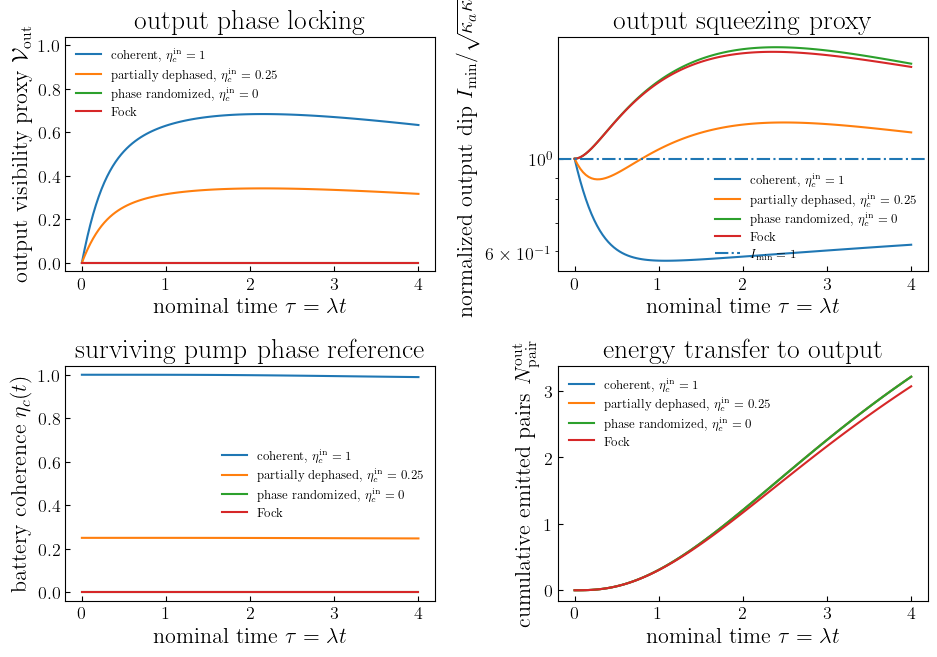

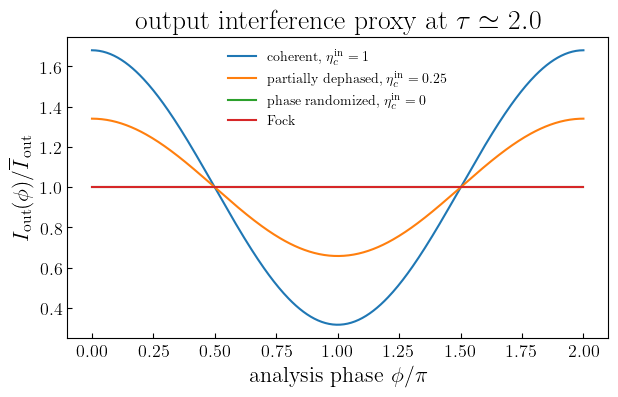

In [22]:
"""
Quantum-battery-powered nondegenerate parametric amplification
Open-system QuTiP master-equation proxy

Hamiltonian in the resonant interaction picture (hbar=1):
    H_I = i g ( c a^dag b^dag - c^dag a b )

Modes:
    a = signal resonator
    b = idler resonator
    c = finite pump / quantum-battery resonator

Open-system model:
    drho/dt = -i[H_I,rho]
             + kappa_a D[a]rho + kappa_b D[b]rho + kappa_c D[c]rho

The script compares coherent, partially dephased, phase-randomized, and Fock pump batteries.
It computes instantaneous output-mode proxies based on
    Phi_a(t) = kappa_a <a^dag a>
    Phi_b(t) = kappa_b <b^dag b>
    M_out(t) = sqrt(kappa_a kappa_b) <a b>

For kappa_a=kappa_b, the normalized interference proxy reduces to the same structure as
in the closed model:
    I_min/sqrt(kappa_a kappa_b) = n_a+n_b+1-2|<ab>|.

Only PDF outputs are saved.

Prepared for Borhan Ahmadi, 2026-05-21.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

try:
    import qutip as qt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This script requires QuTiP. Install it in your environment with, for example,\n"
        "    pip install qutip\n"
        "or run it in the Python environment where you already use QuTiP."
    ) from exc


# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------

@dataclass
class OpenSystemParams:
    # Battery energy and Hilbert-space cutoffs.
    nbar: float = 10.0
    Na: int = 12
    Nb: int = 12
    Nc: int = 32

    # Nominal classical squeezing rate lambda = g sqrt(nbar).
    # We set lambda = 1, so the plotted time tau equals lambda t.
    lambda_nominal: float = 1.0

    # Output-coupling/loss rates in units of lambda_nominal.
    # For a stiff-pump, below-threshold nondegenerate amplifier requires
    # rho = 2 lambda / sqrt(kappa_a kappa_b) < 1.
    kappa_a: float = 2.5
    kappa_b: float = 2.5
    kappa_c: float = 0.02

    # Time grid in nominal squeezing time tau = lambda t.
    tau_max: float = 4.0
    n_tau: int = 121

    # Partially dephased battery coherence fraction.
    eta_partial: float = 0.25

    # Solver tolerances.
    nsteps: int = 20000
    atol: float = 1e-8
    rtol: float = 1e-6

    # Output directory.
    outdir: Path = Path.cwd() / "qb_paramp_outputs"


# -----------------------------------------------------------------------------
# State constructors
# -----------------------------------------------------------------------------

def poisson_probs(nmax: int, nbar: float) -> np.ndarray:
    """Truncated Poisson distribution over n=0,...,nmax."""
    p = np.empty(nmax + 1, dtype=float)
    p[0] = np.exp(-nbar)
    for n in range(1, nmax + 1):
        p[n] = p[n - 1] * nbar / n
    return p / p.sum()


def phase_randomized_coherent_dm(N: int, nbar: float) -> qt.Qobj:
    """Density matrix diagonal in Fock basis with Poisson weights."""
    probs = poisson_probs(N - 1, nbar)
    rho = qt.Qobj(np.diag(probs), dims=[[N], [N]])
    return rho / rho.tr()


def pump_density_matrix(
    N: int,
    nbar: float,
    kind: str,
    eta_partial: float = 0.25,
) -> tuple[qt.Qobj, float]:
    """Return pump density matrix and nominal initial phase coherence eta_in.

    kind options:
        coherent
        partial
        phase_randomized
        fock

    For the partial state,
        rho = w |alpha><alpha| + (1-w) rho_phase_randomized,
    with w=sqrt(eta_partial).  This keeps the same photon-number distribution
    as the coherent state to very high accuracy, while reducing <c>.
    """
    alpha = np.sqrt(nbar)

    if kind == "coherent":
        return qt.coherent_dm(N, alpha), 1.0

    if kind == "phase_randomized":
        return phase_randomized_coherent_dm(N, nbar), 0.0

    if kind == "fock":
        n = int(round(nbar))
        if n >= N:
            raise ValueError("Fock pump photon number exceeds pump cutoff Nc.")
        return qt.fock_dm(N, n), 0.0

    if kind == "partial":
        w = np.sqrt(eta_partial)
        rho_coh = qt.coherent_dm(N, alpha)
        rho_pr = phase_randomized_coherent_dm(N, nbar)
        rho = w * rho_coh + (1.0 - w) * rho_pr
        return rho / rho.tr(), eta_partial

    raise ValueError(f"Unknown pump kind: {kind}")


# -----------------------------------------------------------------------------
# Operators and solver
# -----------------------------------------------------------------------------

def build_operators(p: OpenSystemParams) -> dict[str, qt.Qobj]:
    Ia = qt.qeye(p.Na)
    Ib = qt.qeye(p.Nb)
    Ic = qt.qeye(p.Nc)

    a = qt.tensor(qt.destroy(p.Na), Ib, Ic)
    b = qt.tensor(Ia, qt.destroy(p.Nb), Ic)
    c = qt.tensor(Ia, Ib, qt.destroy(p.Nc))

    na = a.dag() * a
    nb = b.dag() * b
    nc = c.dag() * c
    ab = a * b

    Pa_edge = qt.tensor(qt.fock_dm(p.Na, p.Na - 1), Ib, Ic)
    Pb_edge = qt.tensor(Ia, qt.fock_dm(p.Nb, p.Nb - 1), Ic)
    Pc_edge = qt.tensor(Ia, Ib, qt.fock_dm(p.Nc, p.Nc - 1))

    return dict(
        a=a,
        b=b,
        c=c,
        na=na,
        nb=nb,
        nc=nc,
        ab=ab,
        Pa_edge=Pa_edge,
        Pb_edge=Pb_edge,
        Pc_edge=Pc_edge,
    )


def solver_options(p: OpenSystemParams):
    """QuTiP 4/5 compatible solver options."""
    try:
        return qt.Options(
            nsteps=p.nsteps,
            atol=p.atol,
            rtol=p.rtol,
            store_states=False,
            progress_bar=None,
        )
    except Exception:
        return {"nsteps": p.nsteps, "atol": p.atol, "rtol": p.rtol, "store_states": False}


def initial_density_matrix(p: OpenSystemParams, pump_kind: str) -> tuple[qt.Qobj, float]:
    rho_a = qt.fock_dm(p.Na, 0)
    rho_b = qt.fock_dm(p.Nb, 0)
    rho_c, eta_in = pump_density_matrix(
        p.Nc,
        p.nbar,
        pump_kind,
        eta_partial=p.eta_partial,
    )
    return qt.tensor(rho_a, rho_b, rho_c), eta_in


def solve_open_system_case(
    p: OpenSystemParams,
    pump_kind: str,
    ops: dict[str, qt.Qobj] | None = None,
) -> dict[str, np.ndarray | float | str]:
    """Solve one pump-battery case and return diagnostics."""
    if ops is None:
        ops = build_operators(p)

    a = ops["a"]
    b = ops["b"]
    c = ops["c"]

    g = p.lambda_nominal / np.sqrt(p.nbar)
    H = 1j * g * (c * a.dag() * b.dag() - c.dag() * a * b)

    c_ops = []
    if p.kappa_a > 0:
        c_ops.append(np.sqrt(p.kappa_a) * a)
    if p.kappa_b > 0:
        c_ops.append(np.sqrt(p.kappa_b) * b)
    if p.kappa_c > 0:
        c_ops.append(np.sqrt(p.kappa_c) * c)

    tau_grid = np.linspace(0.0, p.tau_max, p.n_tau)
    tlist = tau_grid / p.lambda_nominal

    rho0, eta_in = initial_density_matrix(p, pump_kind)

    e_ops = [
        ops["na"],
        ops["nb"],
        ops["nc"],
        ops["ab"],
        ops["c"],
        ops["Pa_edge"],
        ops["Pb_edge"],
        ops["Pc_edge"],
    ]

    result = qt.mesolve(
        H,
        rho0,
        tlist,
        c_ops=c_ops,
        e_ops=e_ops,
        options=solver_options(p),
    )

    n_a = np.real(np.asarray(result.expect[0], dtype=complex))
    n_b = np.real(np.asarray(result.expect[1], dtype=complex))
    n_c = np.real(np.asarray(result.expect[2], dtype=complex))
    ab = np.asarray(result.expect[3], dtype=complex)
    c_mean = np.asarray(result.expect[4], dtype=complex)

    edge_a = np.real(np.asarray(result.expect[5], dtype=complex))
    edge_b = np.real(np.asarray(result.expect[6], dtype=complex))
    edge_c = np.real(np.asarray(result.expect[7], dtype=complex))

    n_pair = 0.5 * (n_a + n_b)
    denom_camp = np.sqrt(np.maximum(n_pair * (n_pair + 1.0), 1e-30))
    C_amp = np.abs(ab) / denom_camp
    C_amp[n_pair < 1e-12] = 0.0

    eta_c = np.abs(c_mean) ** 2 / np.maximum(n_c, 1e-30)
    eta_c[n_c < 1e-12] = 0.0

    V_minus_opt = n_a + n_b + 1.0 - 2.0 * np.abs(ab)
    V_plus_opt = n_a + n_b + 1.0 + 2.0 * np.abs(ab)

    Phi_a = p.kappa_a * n_a
    Phi_b = p.kappa_b * n_b
    M_out = np.sqrt(p.kappa_a * p.kappa_b) * ab
    k_ref = np.sqrt(p.kappa_a * p.kappa_b)

    # Mode-matched output interference proxy.  For kappa_a=kappa_b this is
    # exactly kappa times the closed-model I(phi) structure.
    I_mean = Phi_a + Phi_b + k_ref
    I_min = I_mean - 2.0 * np.abs(M_out)
    I_max = I_mean + 2.0 * np.abs(M_out)
    visibility_out = 2.0 * np.abs(M_out) / np.maximum(I_mean, 1e-30)

    N_pair_out = cumulative_trapezoid(0.5 * (Phi_a + Phi_b), tlist, initial=0.0)
    depletion = p.nbar - n_c

    return dict(
        pump_kind=pump_kind,
        eta_in=eta_in,
        tau=tau_grid,
        t=tlist,
        n_a=n_a,
        n_b=n_b,
        n_c=n_c,
        ab=ab,
        c_mean=c_mean,
        n_pair=n_pair,
        C_amp=C_amp,
        eta_c=eta_c,
        V_minus_opt=V_minus_opt,
        V_plus_opt=V_plus_opt,
        Phi_a=Phi_a,
        Phi_b=Phi_b,
        M_out=M_out,
        I_min=I_min,
        I_max=I_max,
        I_min_norm=I_min / k_ref,
        I_max_norm=I_max / k_ref,
        visibility_out=visibility_out,
        N_pair_out=N_pair_out,
        depletion=depletion,
        depletion_fraction=depletion / p.nbar,
        edge_a=edge_a,
        edge_b=edge_b,
        edge_c=edge_c,
        edge_max=max(float(np.max(edge_a)), float(np.max(edge_b)), float(np.max(edge_c))),
    )


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def plot_open_system_proxy(
    p: OpenSystemParams,
    cases: dict[str, dict[str, np.ndarray | float | str]],
) -> Path:
    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(2, 2, figsize=(9.6, 6.8))

    label_map = {
        "coherent": rf"coherent, $\eta_c^{{\rm in}}=1$",
        "partial": rf"partially dephased, $\eta_c^{{\rm in}}={p.eta_partial:.2f}$",
        "phase_randomized": rf"phase randomized, $\eta_c^{{\rm in}}=0$",
        "fock": "Fock",
    }

    for key, dat in cases.items():
        tau = dat["tau"]
        label = label_map.get(key, key)
        axs[0, 0].plot(tau, dat["visibility_out"], label=label)
        axs[0, 1].plot(tau, dat["I_min_norm"], label=label)
        axs[1, 0].plot(tau, dat["eta_c"], label=label)
        axs[1, 1].plot(tau, dat["N_pair_out"], label=label)

    axs[0, 0].set_xlabel(r"nominal time $\tau=\lambda t$")
    axs[0, 0].set_ylabel(r"output visibility proxy $\mathcal V_{\rm out}$")
    axs[0, 0].set_ylim(-0.04, 1.04)
    axs[0, 0].set_title("output phase locking")

    axs[0, 1].axhline(1.0, linestyle="-.", label=r"$I_{\min}=1$")
    axs[0, 1].set_xlabel(r"nominal time $\tau=\lambda t$")
    axs[0, 1].set_ylabel(r"normalized output dip $I_{\min}/\sqrt{\kappa_a\kappa_b}$")
    axs[0, 1].set_yscale("log")
    axs[0, 1].set_title("output squeezing proxy")

    axs[1, 0].set_xlabel(r"nominal time $\tau=\lambda t$")
    axs[1, 0].set_ylabel(r"battery coherence $\eta_c(t)$")
    axs[1, 0].set_ylim(-0.04, 1.04)
    axs[1, 0].set_title("surviving pump phase reference")

    axs[1, 1].set_xlabel(r"nominal time $\tau=\lambda t$")
    axs[1, 1].set_ylabel(r"cumulative emitted pairs $N_{\rm pair}^{\rm out}$")
    axs[1, 1].set_title("energy transfer to output")

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False)

    fig.tight_layout()

    p.outdir.mkdir(parents=True, exist_ok=True)
    pdf_path = p.outdir / "qb_paramp_open_system_proxy.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    return pdf_path


def plot_open_system_fringe_snapshot(
    p: OpenSystemParams,
    cases: dict[str, dict[str, np.ndarray | float | str]],
    tau_star: float = 2.0,
) -> Path:
    phi = np.linspace(0.0, 2.0 * np.pi, 401)
    k_ref = np.sqrt(p.kappa_a * p.kappa_b)

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 10,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    label_map = {
        "coherent": rf"coherent, $\eta_c^{{\rm in}}=1$",
        "partial": rf"partially dephased, $\eta_c^{{\rm in}}={p.eta_partial:.2f}$",
        "phase_randomized": rf"phase randomized, $\eta_c^{{\rm in}}=0$",
        "fock": "Fock",
    }

    for key, dat in cases.items():
        tau = np.asarray(dat["tau"])
        idx = int(np.argmin(np.abs(tau - tau_star)))
        Phi_a = float(np.real(dat["Phi_a"][idx]))
        Phi_b = float(np.real(dat["Phi_b"][idx]))
        M = complex(dat["M_out"][idx])

        I_phi = Phi_a + Phi_b + k_ref + 2.0 * np.real(np.exp(-1j * phi) * M)
        I_phi_norm = I_phi / np.mean(I_phi)
        ax.plot(phi / np.pi, I_phi_norm, label=label_map.get(key, key))

    ax.set_xlabel(r"analysis phase $\phi/\pi$")
    ax.set_ylabel(r"$I_{\rm out}(\phi)/\overline{I}_{\rm out}$")
    ax.set_title(rf"output interference proxy at $\tau\simeq {tau_star:.1f}$")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)
    fig.tight_layout()

    p.outdir.mkdir(parents=True, exist_ok=True)
    pdf_path = p.outdir / "qb_paramp_open_system_fringe_snapshot.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    return pdf_path


# -----------------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------------

def main() -> None:
    p = OpenSystemParams()

    rho_reduced = 2.0 * p.lambda_nominal / np.sqrt(p.kappa_a * p.kappa_b)
    stiff_gain = ((1.0 + rho_reduced**2) / (1.0 - rho_reduced**2)) ** 2 if rho_reduced < 1 else np.inf

    print("Open-system finite-battery parametric amplifier")
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}")
    print(f"lambda = g sqrt(nbar) = {p.lambda_nominal:.3f}")
    print(f"g = {p.lambda_nominal / np.sqrt(p.nbar):.6f}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"stiff-pump reduced coupling rho = 2 lambda/sqrt(kappa_a kappa_b) = {rho_reduced:.3f}")
    if rho_reduced < 1:
        print(f"stiff-pump below-threshold power gain estimate G0 = {stiff_gain:.3f}")
    else:
        print("WARNING: stiff-pump proxy is above threshold; finite battery will still regularize dynamics.")
    print()

    ops = build_operators(p)

    pump_cases = ["coherent", "partial", "phase_randomized", "fock"]
    cases = {}

    for kind in pump_cases:
        print(f"Solving case: {kind}")
        dat = solve_open_system_case(p, kind, ops=ops)
        cases[kind] = dat

        final_idx = -1
        print(
            f"  eta_in={float(dat['eta_in']):.3f}, "
            f"final Vout={float(dat['visibility_out'][final_idx]):.4f}, "
            f"final Imin_norm={float(dat['I_min_norm'][final_idx]):.4f}, "
            f"final eta_c={float(dat['eta_c'][final_idx]):.4f}, "
            f"Npair_out={float(dat['N_pair_out'][final_idx]):.4f}, "
            f"max edge population={float(dat['edge_max']):.2e}"
        )
        if float(dat["edge_max"]) > 1e-3:
            warnings.warn(
                f"Large edge population for {kind}: {float(dat['edge_max']):.2e}. "
                "Increase Na, Nb, or Nc and rerun."
            )
        print()

    pdf1 = plot_open_system_proxy(p, cases)
    pdf2 = plot_open_system_fringe_snapshot(p, cases, tau_star=2.0)


if __name__ == "__main__":
    main()

<>:143: SyntaxWarning: invalid escape sequence '\d'
<>:257: SyntaxWarning: invalid escape sequence '\d'
<>:143: SyntaxWarning: invalid escape sequence '\d'
<>:257: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1945/2234647949.py:143: SyntaxWarning: invalid escape sequence '\d'
  """Coherence fraction eta = |<c>|^2/<c^\dag c> for a single-mode state."""
/tmp/ipykernel_1945/2234647949.py:257: SyntaxWarning: invalid escape sequence '\d'
  Phi_a = kappa_a <a^\dag a>


Time-integrated instantaneous-output proxy
nbar = 5.000
cutoffs: Na=10, Nb=10, Nc=16
lambda = 1.000
g = 0.447214
kappa_a = 2.500, kappa_b = 2.500, kappa_c = 0.020
stiff-pump reduced coupling rho = 0.800
stiff-pump below-threshold power gain estimate G0 = 20.753
tau_max = 4.000, Nt = 101

Solving case: coherent
  eta_in=0.9996, final Vbar=0.5848, final Imin_bar=0.6290, final Cbar=0.7785, final Npair_out=2.5752

Solving case: partial
  eta_in=0.2499, final Vbar=0.2924, final Imin_bar=1.0720, final Cbar=0.3893, final Npair_out=2.5749

Solving case: phase_randomized
  eta_in=0.0000, final Vbar=0.0000, final Imin_bar=1.5149, final Cbar=0.0000, final Npair_out=2.5745

Solving case: fock
  eta_in=0.0000, final Vbar=0.0000, final Imin_bar=1.4875, final Cbar=0.0000, final Npair_out=2.4374

Saved time-integrated proxy plot to:
  /mnt/c/Users/Borhan Ahmadi/Dropbox/QBatteries/QBApplication/Josephson/qb_paramp_outputs/qb_paramp_time_integrated_instantaneous_proxy.pdf
Saved time-integrated fringe pl

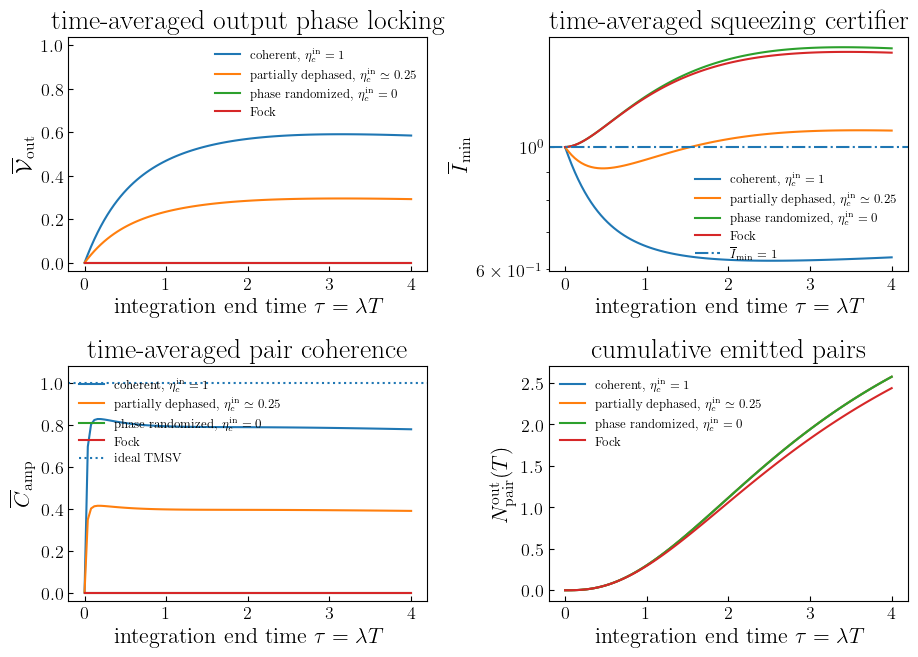

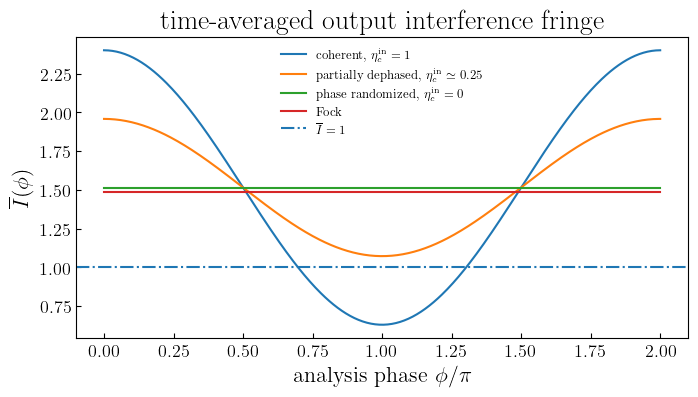

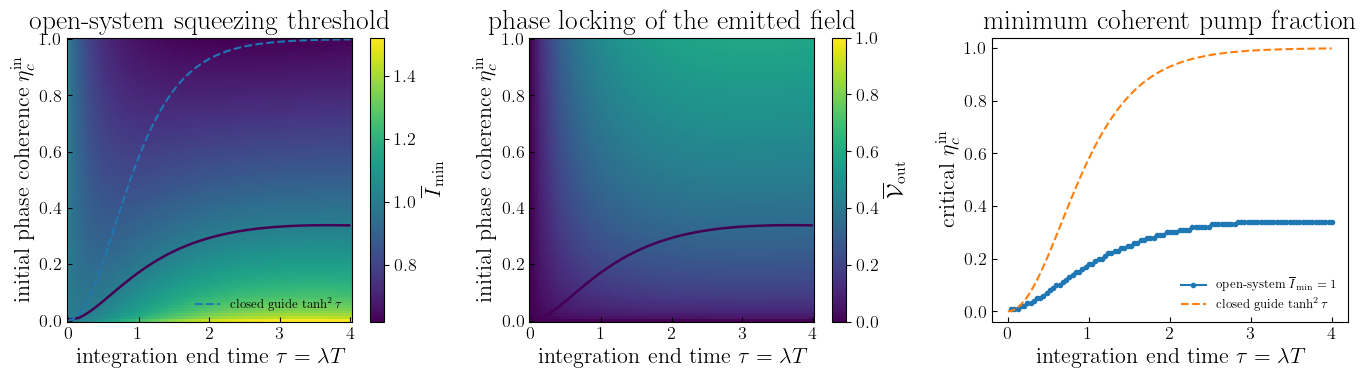

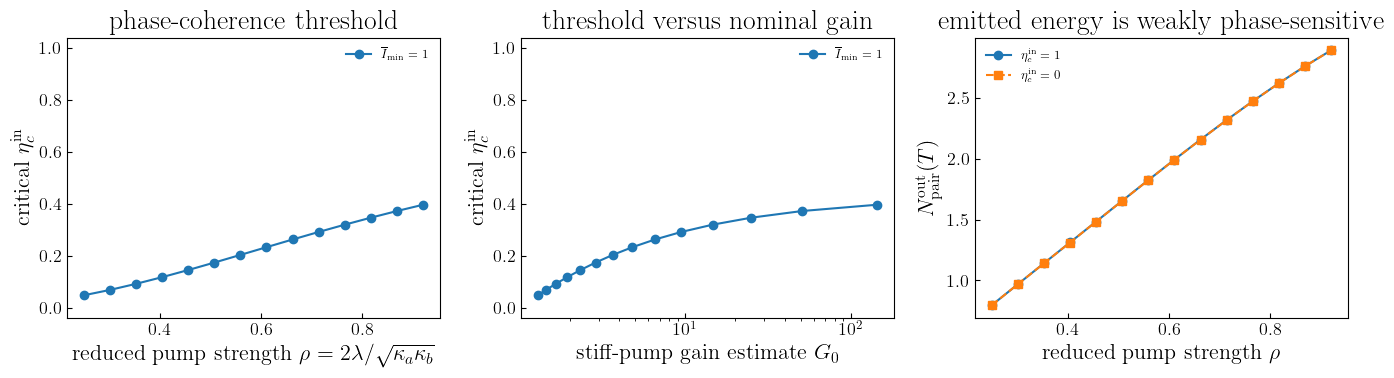

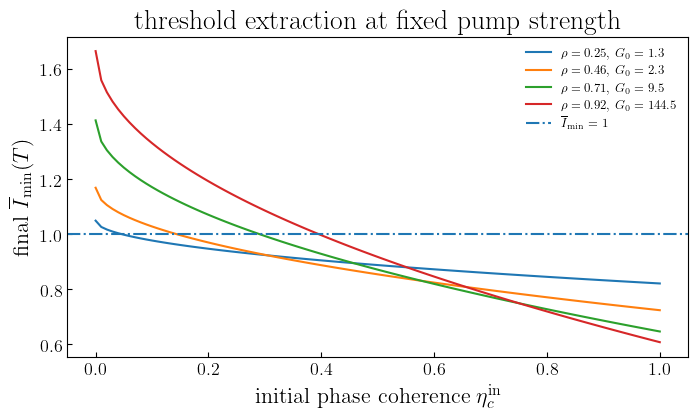

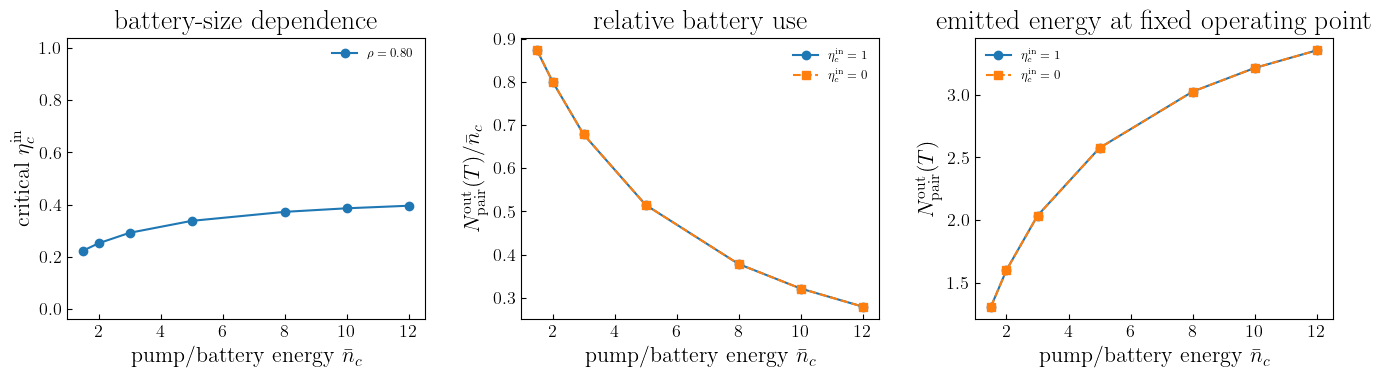

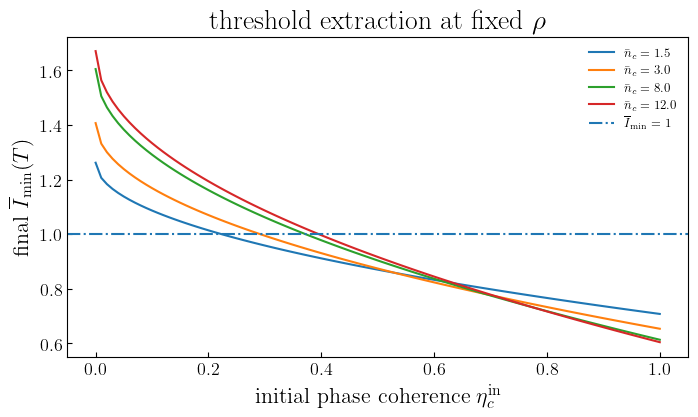

In [3]:
"""
Quantum-battery-powered nondegenerate parametric amplification
Open-system QuTiP model: time-integrated instantaneous-output certifier

Model:
    H_I = i g ( c a^dag b^dag - c^dag a b )

where
    a = signal mode
    b = idler mode
    c = finite pump / quantum battery mode

Master equation:
    d rho/dt =
        -i[H_I, rho]
        + kappa_a D[a] rho
        + kappa_b D[b] rho
        + kappa_c D[c] rho

This script avoids the heavy two-time QRT temporal-mode calculation.
Instead, it computes instantaneous output moments,

    Phi_a(t) = kappa_a <a^dag a>,
    Phi_b(t) = kappa_b <b^dag b>,
    M_out(t) = sqrt(kappa_a kappa_b) <a b>,

and then time-averages these moments over [0,T].

The output interference certifier is

    I_min_bar(T)
    =
    [Phi_a_bar + Phi_b_bar + sqrt(kappa_a kappa_b) - 2 |M_out_bar|]
    / sqrt(kappa_a kappa_b).

The vacuum reference is I_min_bar = 1.

The script saves PDF only.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt


# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------

@dataclass
class Params:
    # Mean pump/battery energy
    nbar: float = 5.0

    # Hilbert-space cutoffs
    Na: int = 10
    Nb: int = 10
    Nc: int = 16

    # Nominal classical pump strength lambda = g sqrt(nbar)
    lam: float = 1.0

    # Output coupling / damping rates
    kappa_a: float = 2.5
    kappa_b: float = 2.5
    kappa_c: float = 0.02

    # Partially dephased coherent pump:
    # rho_c = w |alpha><alpha| + (1-w) rho_phase_randomized
    # eta_partial = w^2
    eta_partial: float = 0.25

    # Time grid in units tau = lambda t
    tau_max: float = 4.0
    Nt: int = 101

    # Solver tolerances
    nsteps: int = 20000
    atol: float = 1e-8
    rtol: float = 1e-7

    @property
    def g(self) -> float:
        return self.lam / np.sqrt(self.nbar)

    @property
    def rho_reduced(self) -> float:
        return 2.0 * self.lam / np.sqrt(self.kappa_a * self.kappa_b)

    @property
    def stiff_pump_gain_estimate(self) -> float:
        rho = self.rho_reduced
        if rho >= 1.0:
            return np.inf
        return ((1.0 + rho**2) / (1.0 - rho**2)) ** 2


# -----------------------------------------------------------------------------
# Single-mode pump/battery states
# -----------------------------------------------------------------------------

def poisson_probs(nmax: int, nbar: float) -> np.ndarray:
    """Poisson probabilities p_n for n=0,...,nmax-1, renormalized."""
    probs = np.empty(nmax, dtype=float)
    probs[0] = np.exp(-nbar)
    for n in range(1, nmax):
        probs[n] = probs[n - 1] * nbar / n
    total = probs.sum()
    if total <= 0:
        raise ValueError("Poisson probabilities underflowed.")
    return probs / total


def coherent_dm(N: int, nbar: float) -> qt.Qobj:
    """Truncated coherent state density matrix."""
    alpha = np.sqrt(nbar)
    ket = qt.coherent(N, alpha)
    return qt.ket2dm(ket)


def phase_randomized_coherent_dm(N: int, nbar: float) -> qt.Qobj:
    """Phase-randomized coherent state with Poisson photon-number distribution."""
    probs = poisson_probs(N, nbar)
    return qt.Qobj(np.diag(probs), dims=[[N], [N]])


def fock_dm(N: int, n: int) -> qt.Qobj:
    """Fock state density matrix."""
    if n >= N:
        raise ValueError(
            f"Fock index n={n} does not fit in cutoff N={N}. "
            "Increase Nc or lower nbar."
        )
    return qt.ket2dm(qt.basis(N, n))


def single_mode_eta(rho: qt.Qobj) -> float:
    """Coherence fraction eta = |<c>|^2/<c^\dag c> for a single-mode state."""
    N = rho.shape[0]
    c = qt.destroy(N)
    n_op = c.dag() * c

    n_mean = float(np.real(qt.expect(n_op, rho)))
    if n_mean <= 1e-14:
        return 0.0

    c_mean = complex(qt.expect(c, rho))
    return abs(c_mean) ** 2 / n_mean


def pump_state_dm(kind: str, p: Params) -> tuple[qt.Qobj, float]:
    """Return pump/battery density matrix and its initial eta_c."""
    if kind == "coherent":
        rho = coherent_dm(p.Nc, p.nbar)

    elif kind == "phase_randomized":
        rho = phase_randomized_coherent_dm(p.Nc, p.nbar)

    elif kind == "partial":
        w = np.sqrt(p.eta_partial)
        rho_coh = coherent_dm(p.Nc, p.nbar)
        rho_deph = phase_randomized_coherent_dm(p.Nc, p.nbar)
        rho = w * rho_coh + (1.0 - w) * rho_deph
        rho = rho / rho.tr()

    elif kind == "fock":
        n = int(round(p.nbar))
        rho = fock_dm(p.Nc, n)

    else:
        raise ValueError(f"Unknown pump kind: {kind}")

    eta = single_mode_eta(rho)
    return rho, eta


# -----------------------------------------------------------------------------
# Model construction
# -----------------------------------------------------------------------------

def build_model(p: Params) -> tuple[qt.Qobj, list[qt.Qobj], qt.Qobj, qt.Qobj, qt.Qobj]:
    """Build Hamiltonian, collapse operators, and mode operators."""
    a = qt.tensor(qt.destroy(p.Na), qt.qeye(p.Nb), qt.qeye(p.Nc))
    b = qt.tensor(qt.qeye(p.Na), qt.destroy(p.Nb), qt.qeye(p.Nc))
    c = qt.tensor(qt.qeye(p.Na), qt.qeye(p.Nb), qt.destroy(p.Nc))

    H = 1j * p.g * (c * a.dag() * b.dag() - c.dag() * a * b)

    c_ops: list[qt.Qobj] = []
    if p.kappa_a > 0:
        c_ops.append(np.sqrt(p.kappa_a) * a)
    if p.kappa_b > 0:
        c_ops.append(np.sqrt(p.kappa_b) * b)
    if p.kappa_c > 0:
        c_ops.append(np.sqrt(p.kappa_c) * c)

    return H, c_ops, a, b, c


def initial_state(kind: str, p: Params) -> tuple[qt.Qobj, float]:
    """Initial state: signal vacuum, idler vacuum, chosen pump/battery state."""
    rho_a = qt.ket2dm(qt.basis(p.Na, 0))
    rho_b = qt.ket2dm(qt.basis(p.Nb, 0))
    rho_c, eta = pump_state_dm(kind, p)

    rho0 = qt.tensor(rho_a, rho_b, rho_c)
    return rho0, eta


# -----------------------------------------------------------------------------
# Time integration helpers
# -----------------------------------------------------------------------------

def prefix_trapz_integral(t: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Prefix trapezoidal integral int_0^t y(t') dt'."""
    y = np.asarray(y)
    out = np.zeros_like(y, dtype=complex)

    for k in range(1, len(t)):
        dt = t[k] - t[k - 1]
        out[k] = out[k - 1] + 0.5 * dt * (y[k] + y[k - 1])

    return out


def prefix_time_average(t: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Prefix time average over [0,t]."""
    y = np.asarray(y)
    integ = prefix_trapz_integral(t, y)
    out = np.zeros_like(y, dtype=complex)

    out[0] = y[0]
    for k in range(1, len(t)):
        T = t[k] - t[0]
        out[k] = integ[k] / T if T > 0 else y[0]

    return out


# -----------------------------------------------------------------------------
# Output certifiers
# -----------------------------------------------------------------------------

def output_certifiers_from_fluxes(
    Phi_a: np.ndarray,
    Phi_b: np.ndarray,
    M_out: np.ndarray,
    sqrt_kab: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute output visibility, Imin, Imax, C_amp, and normalized pair number.

    Phi_a = kappa_a <a^\dag a>
    Phi_b = kappa_b <b^\dag b>
    M_out = sqrt(kappa_a kappa_b) <a b>

    The normalized interference intensity is divided by sqrt(kappa_a kappa_b),
    so the vacuum reference is 1.
    """
    Phi_a = np.asarray(Phi_a, dtype=complex)
    Phi_b = np.asarray(Phi_b, dtype=complex)
    M_out = np.asarray(M_out, dtype=complex)

    denom = np.real(Phi_a + Phi_b + sqrt_kab)

    Imin = (denom - 2.0 * np.abs(M_out)) / sqrt_kab
    Imax = (denom + 2.0 * np.abs(M_out)) / sqrt_kab

    Vout = np.zeros_like(Imin, dtype=float)
    mask = denom > 1e-14
    Vout[mask] = 2.0 * np.abs(M_out[mask]) / denom[mask]

    n_a_eff = np.real(Phi_a) / sqrt_kab
    n_b_eff = np.real(Phi_b) / sqrt_kab
    n_pair = 0.5 * (n_a_eff + n_b_eff)

    M_eff = M_out / sqrt_kab
    C_amp = np.zeros_like(n_pair, dtype=float)
    mask_pair = n_pair > 1e-14
    C_amp[mask_pair] = np.abs(M_eff[mask_pair]) / np.sqrt(
        n_pair[mask_pair] * (n_pair[mask_pair] + 1.0)
    )

    return (
        np.real(Vout),
        np.real(Imin),
        np.real(Imax),
        np.real(C_amp),
        np.real(n_pair),
    )


@dataclass
class IntegratedProxyResult:
    label: str
    eta_in: float
    tlist: np.ndarray
    tau_grid: np.ndarray

    Vout_inst: np.ndarray
    Imin_inst: np.ndarray
    Imax_inst: np.ndarray
    C_inst: np.ndarray
    npair_inst: np.ndarray

    Vout_avg: np.ndarray
    Imin_avg: np.ndarray
    Imax_avg: np.ndarray
    C_avg: np.ndarray
    npair_avg: np.ndarray

    eta_c: np.ndarray
    cumulative_pairs: np.ndarray

    phi: np.ndarray
    I_fringe_final: np.ndarray


def integrated_instantaneous_output_result(kind: str, p: Params) -> IntegratedProxyResult:
    """Run one master-equation solve and build time-integrated output certifiers."""
    H, c_ops, a, b, c = build_model(p)
    rho0, eta_in = initial_state(kind, p)

    tmax = p.tau_max / p.lam
    tlist = np.linspace(0.0, tmax, p.Nt)
    tau_grid = p.lam * tlist

    n_a_op = a.dag() * a
    n_b_op = b.dag() * b
    n_c_op = c.dag() * c
    ab_op = a * b

    options = {
        "nsteps": p.nsteps,
        "atol": p.atol,
        "rtol": p.rtol,
        "store_states": False,
    }

    sol = qt.mesolve(
        H,
        rho0,
        tlist,
        c_ops,
        e_ops=[n_a_op, n_b_op, n_c_op, c, ab_op],
        options=options,
    )

    n_a = np.real(np.asarray(sol.expect[0], dtype=complex))
    n_b = np.real(np.asarray(sol.expect[1], dtype=complex))
    n_c = np.real(np.asarray(sol.expect[2], dtype=complex))
    c_mean = np.asarray(sol.expect[3], dtype=complex)
    ab = np.asarray(sol.expect[4], dtype=complex)

    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Phi_a = p.kappa_a * n_a
    Phi_b = p.kappa_b * n_b
    M_out = sqrt_kab * ab

    Vout_inst, Imin_inst, Imax_inst, C_inst, npair_inst = output_certifiers_from_fluxes(
        Phi_a=Phi_a,
        Phi_b=Phi_b,
        M_out=M_out,
        sqrt_kab=sqrt_kab,
    )

    Phi_a_avg = prefix_time_average(tlist, Phi_a)
    Phi_b_avg = prefix_time_average(tlist, Phi_b)
    M_out_avg = prefix_time_average(tlist, M_out)

    Vout_avg, Imin_avg, Imax_avg, C_avg, npair_avg = output_certifiers_from_fluxes(
        Phi_a=Phi_a_avg,
        Phi_b=Phi_b_avg,
        M_out=M_out_avg,
        sqrt_kab=sqrt_kab,
    )

    eta_c = np.zeros_like(n_c, dtype=float)
    mask = n_c > 1e-14
    eta_c[mask] = np.abs(c_mean[mask]) ** 2 / n_c[mask]

    cumulative_pairs = np.real(prefix_trapz_integral(tlist, 0.5 * (Phi_a + Phi_b)))

    phi = np.linspace(0.0, 2.0 * np.pi, 401)
    final_denom = np.real((Phi_a_avg[-1] + Phi_b_avg[-1] + sqrt_kab) / sqrt_kab)
    final_M = M_out_avg[-1] / sqrt_kab
    I_fringe_final = final_denom + 2.0 * np.real(np.exp(-1j * phi) * final_M)

    return IntegratedProxyResult(
        label=kind,
        eta_in=eta_in,
        tlist=tlist,
        tau_grid=tau_grid,
        Vout_inst=Vout_inst,
        Imin_inst=Imin_inst,
        Imax_inst=Imax_inst,
        C_inst=C_inst,
        npair_inst=npair_inst,
        Vout_avg=Vout_avg,
        Imin_avg=Imin_avg,
        Imax_avg=Imax_avg,
        C_avg=C_avg,
        npair_avg=npair_avg,
        eta_c=eta_c,
        cumulative_pairs=cumulative_pairs,
        phi=phi,
        I_fringe_final=I_fringe_final,
    )


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def plot_integrated_proxy_results(results: dict[str, IntegratedProxyResult], p: Params) -> None:
    label_map = {
        "coherent": r"coherent, $\eta_c^{\rm in}=1$",
        "partial": rf"partially dephased, $\eta_c^{{\rm in}}\simeq {p.eta_partial:.2f}$",
        "phase_randomized": r"phase randomized, $\eta_c^{\rm in}=0$",
        "fock": r"Fock",
    }

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(2, 2, figsize=(9.4, 6.8))

    for kind, r in results.items():
        label = label_map.get(kind, kind)
        tau = r.tau_grid

        axs[0, 0].plot(tau, r.Vout_avg, label=label)
        axs[0, 1].plot(tau, r.Imin_avg, label=label)
        axs[1, 0].plot(tau, r.C_avg, label=label)
        axs[1, 1].plot(tau, r.cumulative_pairs, label=label)

    axs[0, 0].set_title(r"time-averaged output phase locking")
    axs[0, 0].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[0, 0].set_ylabel(r"$\overline{\mathcal V}_{\rm out}$")
    axs[0, 0].set_ylim(-0.04, 1.04)

    axs[0, 1].axhline(1.0, linestyle="-.", label=r"$\overline I_{\min}=1$")
    axs[0, 1].set_title(r"time-averaged squeezing certifier")
    axs[0, 1].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[0, 1].set_ylabel(r"$\overline I_{\min}$")
    axs[0, 1].set_yscale("log")

    axs[1, 0].axhline(1.0, linestyle=":", label="ideal TMSV")
    axs[1, 0].set_title(r"time-averaged pair coherence")
    axs[1, 0].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[1, 0].set_ylabel(r"$\overline C_{\rm amp}$")
    axs[1, 0].set_ylim(-0.04, 1.08)

    axs[1, 1].set_title(r"cumulative emitted pairs")
    axs[1, 1].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[1, 1].set_ylabel(r"$N_{\rm pair}^{\rm out}(T)$")

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False)

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_time_integrated_instantaneous_proxy.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved time-integrated proxy plot to:\n  {pdf_path}")

    fig2, ax = plt.subplots(figsize=(7.2, 4.2))

    for kind, r in results.items():
        label = label_map.get(kind, kind)
        ax.plot(r.phi / np.pi, r.I_fringe_final, label=label)

    ax.axhline(1.0, linestyle="-.", label=r"$\overline I=1$")
    ax.set_xlabel(r"analysis phase $\phi/\pi$")
    ax.set_ylabel(r"$\overline I(\phi)$")
    ax.set_title(r"time-averaged output interference fringe")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

    fig2.tight_layout()

    pdf_path2 = outdir / "qb_paramp_time_integrated_instantaneous_fringe.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")
    print(f"Saved time-integrated fringe plot to:\n  {pdf_path2}")


# -----------------------------------------------------------------------------
# Main
# -----------------------------------------------------------------------------

def main() -> None:
    p = Params()

    print("Time-integrated instantaneous-output proxy")
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}")
    print(f"lambda = {p.lam:.3f}")
    print(f"g = {p.g:.6f}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"stiff-pump reduced coupling rho = {p.rho_reduced:.3f}")
    print(f"stiff-pump below-threshold power gain estimate G0 = {p.stiff_pump_gain_estimate:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print()

    if int(round(p.nbar)) >= p.Nc:
        print("Warning: Fock pump does not fit in Nc cutoff. Removing Fock case for this run.")
        kinds = ["coherent", "partial", "phase_randomized"]
    else:
        kinds = ["coherent", "partial", "phase_randomized", "fock"]

    results: dict[str, IntegratedProxyResult] = {}

    for kind in kinds:
        print(f"Solving case: {kind}")
        results[kind] = integrated_instantaneous_output_result(kind, p)
        r = results[kind]
        print(
            f"  eta_in={r.eta_in:.4f}, "
            f"final Vbar={r.Vout_avg[-1]:.4f}, "
            f"final Imin_bar={r.Imin_avg[-1]:.4f}, "
            f"final Cbar={r.C_avg[-1]:.4f}, "
            f"final Npair_out={r.cumulative_pairs[-1]:.4f}"
        )
        print()

    plot_integrated_proxy_results(results, p)


if __name__ == "__main__":
    main()

# -----------------------------------------------------------------------------
# Open-system phase-coherence threshold diagram: Option A
# Uses time-integrated instantaneous-output certifier.
# Cheap version: only two mesolve calls, coherent and phase-randomized.
# -----------------------------------------------------------------------------

@dataclass
class RawOutputMoments:
    eta_in: float
    tlist: np.ndarray
    tau_grid: np.ndarray
    Phi_a: np.ndarray
    Phi_b: np.ndarray
    M_out: np.ndarray
    cumulative_pairs: np.ndarray


def solve_raw_output_moments(kind: str, p: Params) -> RawOutputMoments:
    """Solve one pump case and return linear output moments.

    These moments can be convexly mixed because the master equation is linear.
    """
    H, c_ops, a, b, c = build_model(p)
    rho0, eta_in = initial_state(kind, p)

    tmax = p.tau_max / p.lam
    tlist = np.linspace(0.0, tmax, p.Nt)
    tau_grid = p.lam * tlist

    n_a_op = a.dag() * a
    n_b_op = b.dag() * b
    ab_op = a * b

    options = {
        "nsteps": p.nsteps,
        "atol": p.atol,
        "rtol": p.rtol,
        "store_states": False,
    }

    sol = qt.mesolve(
        H,
        rho0,
        tlist,
        c_ops,
        e_ops=[n_a_op, n_b_op, ab_op],
        options=options,
    )

    n_a = np.real(np.asarray(sol.expect[0], dtype=complex))
    n_b = np.real(np.asarray(sol.expect[1], dtype=complex))
    ab = np.asarray(sol.expect[2], dtype=complex)

    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Phi_a = p.kappa_a * n_a
    Phi_b = p.kappa_b * n_b
    M_out = sqrt_kab * ab

    cumulative_pairs = np.real(prefix_trapz_integral(tlist, 0.5 * (Phi_a + Phi_b)))

    return RawOutputMoments(
        eta_in=eta_in,
        tlist=tlist,
        tau_grid=tau_grid,
        Phi_a=Phi_a,
        Phi_b=Phi_b,
        M_out=M_out,
        cumulative_pairs=cumulative_pairs,
    )


def open_threshold_scan_optionA(
    p: Params,
    n_eta: int = 81,
) -> dict[str, np.ndarray]:
    """Scan eta_c^in and integration end time using the stable Option-A certifier.

    The pump family is
        rho_c(0) = w |alpha><alpha| + (1-w) rho_phase-randomized,
    with
        eta_c^in = w^2.

    Since the evolution and moments are linear in rho, all eta values are obtained
    from two master-equation solves.
    """
    print("Solving coherent reference for threshold scan...")
    coh = solve_raw_output_moments("coherent", p)

    print("Solving phase-randomized reference for threshold scan...")
    deph = solve_raw_output_moments("phase_randomized", p)

    tau_grid = coh.tau_grid
    eta_grid = np.linspace(0.0, 1.0, n_eta)
    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Nt = len(tau_grid)

    Imin_map = np.zeros((n_eta, Nt))
    Imax_map = np.zeros((n_eta, Nt))
    Vout_map = np.zeros((n_eta, Nt))
    Camp_map = np.zeros((n_eta, Nt))
    npair_map = np.zeros((n_eta, Nt))
    Npair_cum_map = np.zeros((n_eta, Nt))

    # Precompute prefix time averages for the two endpoint states.
    Phi_a_coh_avg = prefix_time_average(coh.tlist, coh.Phi_a)
    Phi_b_coh_avg = prefix_time_average(coh.tlist, coh.Phi_b)
    M_coh_avg = prefix_time_average(coh.tlist, coh.M_out)

    Phi_a_deph_avg = prefix_time_average(deph.tlist, deph.Phi_a)
    Phi_b_deph_avg = prefix_time_average(deph.tlist, deph.Phi_b)
    M_deph_avg = prefix_time_average(deph.tlist, deph.M_out)

    for i, eta_in in enumerate(eta_grid):
        w = np.sqrt(eta_in)

        Phi_a_avg = w * Phi_a_coh_avg + (1.0 - w) * Phi_a_deph_avg
        Phi_b_avg = w * Phi_b_coh_avg + (1.0 - w) * Phi_b_deph_avg
        M_avg = w * M_coh_avg + (1.0 - w) * M_deph_avg

        Vout, Imin, Imax, Camp, npair = output_certifiers_from_fluxes(
            Phi_a=Phi_a_avg,
            Phi_b=Phi_b_avg,
            M_out=M_avg,
            sqrt_kab=sqrt_kab,
        )

        cumulative_pairs = w * coh.cumulative_pairs + (1.0 - w) * deph.cumulative_pairs

        Imin_map[i, :] = Imin
        Imax_map[i, :] = Imax
        Vout_map[i, :] = Vout
        Camp_map[i, :] = Camp
        npair_map[i, :] = npair
        Npair_cum_map[i, :] = cumulative_pairs

    # Critical eta: smallest eta such that Imin_bar < 1.
    eta_threshold = np.full(Nt, np.nan)
    for j in range(Nt):
        good = Imin_map[:, j] < 1.0
        if np.any(good):
            eta_threshold[j] = eta_grid[np.argmax(good)]

    return {
        "tau_grid": tau_grid,
        "eta_grid": eta_grid,
        "Imin_map": Imin_map,
        "Imax_map": Imax_map,
        "Vout_map": Vout_map,
        "Camp_map": Camp_map,
        "npair_map": npair_map,
        "Npair_cum_map": Npair_cum_map,
        "eta_threshold": eta_threshold,
        "coh_eta_in": np.array(coh.eta_in),
        "deph_eta_in": np.array(deph.eta_in),
    }


def main_open_system_threshold_optionA() -> None:
    p = Params()

    print("Open-system phase-coherence threshold diagram: Option A")
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}")
    print(f"lambda = {p.lam:.3f}")
    print(f"g = {p.g:.6f}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"stiff-pump reduced coupling rho = {p.rho_reduced:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print()

    scan = open_threshold_scan_optionA(p, n_eta=101)

    tau = scan["tau_grid"]
    eta = scan["eta_grid"]
    T, E = np.meshgrid(tau, eta)

    Imin_map = scan["Imin_map"]
    Vout_map = scan["Vout_map"]
    Camp_map = scan["Camp_map"]
    eta_threshold = scan["eta_threshold"]

    # For comparison only: closed stiff-pump guide.
    eta_closed_guide = np.tanh(tau) ** 2

    print()
    print("Selected threshold values")
    print("tau     eta_threshold    closed_guide_tanh2")
    for idx in np.linspace(0, len(tau) - 1, 8, dtype=int):
        print(
            f"{tau[idx]:.3f}   "
            f"{eta_threshold[idx] if np.isfinite(eta_threshold[idx]) else np.nan:.4f}          "
            f"{eta_closed_guide[idx]:.4f}"
        )

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))

    # Panel 1: time-averaged squeezing threshold
    im0 = axs[0].pcolormesh(
        T,
        E,
        Imin_map,
        shading="auto",
    )
    cbar0 = fig.colorbar(im0, ax=axs[0])
    cbar0.set_label(r"$\overline I_{\min}$")

    axs[0].contour(
        T,
        E,
        Imin_map,
        levels=[1.0],
        linewidths=1.8,
    )
    axs[0].plot(
        tau,
        eta_closed_guide,
        linestyle="--",
        label=r"closed guide $\tanh^2\tau$",
    )
    axs[0].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[0].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[0].set_title(r"open-system squeezing threshold")
    axs[0].legend(frameon=False)

    # Panel 2: output phase locking
    im1 = axs[1].pcolormesh(
        T,
        E,
        Vout_map,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )
    cbar1 = fig.colorbar(im1, ax=axs[1])
    cbar1.set_label(r"$\overline{\mathcal V}_{\rm out}$")

    axs[1].contour(
        T,
        E,
        Imin_map,
        levels=[1.0],
        linewidths=1.8,
    )
    axs[1].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[1].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1].set_title(r"phase locking of the emitted field")

    # Panel 3: extracted threshold curve
    axs[2].plot(
        tau,
        eta_threshold,
        "o-",
        ms=3,
        label=r"open-system $\overline I_{\min}=1$",
    )
    axs[2].plot(
        tau,
        eta_closed_guide,
        linestyle="--",
        label=r"closed guide $\tanh^2\tau$",
    )
    axs[2].set_xlabel(r"integration end time $\tau=\lambda T$")
    axs[2].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[2].set_ylim(-0.04, 1.04)
    axs[2].set_title(r"minimum coherent pump fraction")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_open_system_threshold_optionA.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"\nSaved open-system threshold diagram to:\n  {pdf_path}")


if __name__ == "__main__":
    main_open_system_threshold_optionA()

# -----------------------------------------------------------------------------
# Gain / pump-strength threshold scan: eta_crit versus rho and G0
# Option A: stable time-integrated instantaneous-output certifier
# -----------------------------------------------------------------------------

from dataclasses import replace


def stiff_pump_gain_from_rho(rho: np.ndarray | float) -> np.ndarray | float:
    """Below-threshold stiff-pump gain estimate."""
    rho = np.asarray(rho)
    out = np.full_like(rho, np.inf, dtype=float)
    mask = rho < 1.0
    out[mask] = ((1.0 + rho[mask] ** 2) / (1.0 - rho[mask] ** 2)) ** 2
    return out


def crossing_threshold(
    eta_grid: np.ndarray,
    y_values: np.ndarray,
    target: float = 1.0,
) -> float:
    """Find smallest eta where y_values crosses below target.

    Linear interpolation is used between neighboring eta-grid points.
    Returns nan if no crossing exists.
    """
    y = np.asarray(y_values, dtype=float)
    good = y < target

    if not np.any(good):
        return np.nan

    idx = int(np.argmax(good))

    if idx == 0:
        return float(eta_grid[0])

    x0, x1 = eta_grid[idx - 1], eta_grid[idx]
    y0, y1 = y[idx - 1], y[idx]

    if abs(y1 - y0) < 1e-14:
        return float(x1)

    return float(x0 + (target - y0) * (x1 - x0) / (y1 - y0))


def threshold_for_single_rho(
    p_base: Params,
    rho_value: float,
    eta_grid: np.ndarray,
) -> dict[str, float | np.ndarray]:
    """Compute eta_crit for one reduced pump strength rho.

    We vary lambda at fixed kappa_a,kappa_b:

        lambda = rho sqrt(kappa_a kappa_b)/2.

    Only two master-equation solves are needed: coherent and phase-randomized.
    All intermediate eta values are constructed by convex mixing.
    """
    lam_value = 0.5 * rho_value * np.sqrt(p_base.kappa_a * p_base.kappa_b)
    p = replace(p_base, lam=lam_value)

    coh = solve_raw_output_moments("coherent", p)
    deph = solve_raw_output_moments("phase_randomized", p)

    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Phi_a_coh_avg = prefix_time_average(coh.tlist, coh.Phi_a)
    Phi_b_coh_avg = prefix_time_average(coh.tlist, coh.Phi_b)
    M_coh_avg = prefix_time_average(coh.tlist, coh.M_out)

    Phi_a_deph_avg = prefix_time_average(deph.tlist, deph.Phi_a)
    Phi_b_deph_avg = prefix_time_average(deph.tlist, deph.Phi_b)
    M_deph_avg = prefix_time_average(deph.tlist, deph.M_out)

    Imin_final = np.zeros_like(eta_grid)
    Vout_final = np.zeros_like(eta_grid)
    Camp_final = np.zeros_like(eta_grid)
    npair_final = np.zeros_like(eta_grid)
    Npair_cum_final = np.zeros_like(eta_grid)

    for i, eta_in in enumerate(eta_grid):
        w = np.sqrt(eta_in)

        Phi_a_avg = w * Phi_a_coh_avg + (1.0 - w) * Phi_a_deph_avg
        Phi_b_avg = w * Phi_b_coh_avg + (1.0 - w) * Phi_b_deph_avg
        M_avg = w * M_coh_avg + (1.0 - w) * M_deph_avg

        Vout, Imin, Imax, Camp, npair = output_certifiers_from_fluxes(
            Phi_a=Phi_a_avg,
            Phi_b=Phi_b_avg,
            M_out=M_avg,
            sqrt_kab=sqrt_kab,
        )

        cumulative_pairs = w * coh.cumulative_pairs + (1.0 - w) * deph.cumulative_pairs

        Imin_final[i] = Imin[-1]
        Vout_final[i] = Vout[-1]
        Camp_final[i] = Camp[-1]
        npair_final[i] = npair[-1]
        Npair_cum_final[i] = cumulative_pairs[-1]

    eta_crit = crossing_threshold(eta_grid, Imin_final, target=1.0)

    return {
        "rho": float(rho_value),
        "lambda": float(lam_value),
        "G0": float(stiff_pump_gain_from_rho(float(rho_value))),
        "eta_crit": eta_crit,
        "Imin_eta0": float(Imin_final[0]),
        "Imin_eta025": float(np.interp(0.25, eta_grid, Imin_final)),
        "Imin_eta1": float(Imin_final[-1]),
        "Vout_eta1": float(Vout_final[-1]),
        "Camp_eta1": float(Camp_final[-1]),
        "Npair_eta0": float(Npair_cum_final[0]),
        "Npair_eta1": float(Npair_cum_final[-1]),
        "eta_grid": eta_grid.copy(),
        "Imin_final": Imin_final.copy(),
        "Vout_final": Vout_final.copy(),
        "Camp_final": Camp_final.copy(),
        "Npair_cum_final": Npair_cum_final.copy(),
    }


def gain_threshold_scan_optionA(
    p_base: Params,
    rho_values: np.ndarray,
    n_eta: int = 101,
) -> list[dict[str, float | np.ndarray]]:
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    results = []

    for rho_value in rho_values:
        print(f"Scanning rho = {rho_value:.3f} ...")
        out = threshold_for_single_rho(
            p_base=p_base,
            rho_value=float(rho_value),
            eta_grid=eta_grid,
        )
        results.append(out)

        eta_crit = out["eta_crit"]
        eta_msg = f"{eta_crit:.4f}" if np.isfinite(eta_crit) else "nan"

        print(
            f"  G0={out['G0']:.3f}, "
            f"eta_crit={eta_msg}, "
            f"Imin(eta=1)={out['Imin_eta1']:.4f}, "
            f"Imin(eta=0)={out['Imin_eta0']:.4f}, "
            f"Npair eta1/eta0={out['Npair_eta1']:.4f}/{out['Npair_eta0']:.4f}"
        )

    return results


def main_gain_threshold_scan_optionA() -> None:
    p = Params()

    # For a first run, keep this modest. Increase the number of rho points later.
    rho_values = np.linspace(0.25, 0.92, 14)

    print("Gain / pump-strength threshold scan: Option A")
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print("lambda is varied through rho = 2 lambda/sqrt(kappa_a kappa_b).")
    print()

    scan = gain_threshold_scan_optionA(
        p_base=p,
        rho_values=rho_values,
        n_eta=101,
    )

    rho = np.array([r["rho"] for r in scan], dtype=float)
    G0 = np.array([r["G0"] for r in scan], dtype=float)
    eta_crit = np.array([r["eta_crit"] for r in scan], dtype=float)
    Imin_eta0 = np.array([r["Imin_eta0"] for r in scan], dtype=float)
    Imin_eta025 = np.array([r["Imin_eta025"] for r in scan], dtype=float)
    Imin_eta1 = np.array([r["Imin_eta1"] for r in scan], dtype=float)
    Npair_eta0 = np.array([r["Npair_eta0"] for r in scan], dtype=float)
    Npair_eta1 = np.array([r["Npair_eta1"] for r in scan], dtype=float)
    Vout_eta1 = np.array([r["Vout_eta1"] for r in scan], dtype=float)
    Camp_eta1 = np.array([r["Camp_eta1"] for r in scan], dtype=float)

    print()
    print("Summary table")
    print("rho     G0        eta_crit    Imin_eta1    Imin_eta0    Npair_eta1    Npair_eta0")
    for i in range(len(rho)):
        print(
            f"{rho[i]:.3f}   {G0[i]:8.3f}   "
            f"{eta_crit[i] if np.isfinite(eta_crit[i]) else np.nan:.4f}      "
            f"{Imin_eta1[i]:.4f}       {Imin_eta0[i]:.4f}       "
            f"{Npair_eta1[i]:.4f}       {Npair_eta0[i]:.4f}"
        )

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))

    # Panel 1: eta_crit versus rho.
    axs[0].plot(rho, eta_crit, "o-", label=r"$\overline I_{\min}=1$")
    axs[0].set_xlabel(r"reduced pump strength $\rho=2\lambda/\sqrt{\kappa_a\kappa_b}$")
    axs[0].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[0].set_title(r"phase-coherence threshold")
    axs[0].set_ylim(-0.04, 1.04)
    axs[0].legend(frameon=False)

    # Panel 2: eta_crit versus gain estimate.
    axs[1].plot(G0, eta_crit, "o-", label=r"$\overline I_{\min}=1$")
    axs[1].set_xscale("log")
    axs[1].set_xlabel(r"stiff-pump gain estimate $G_0$")
    axs[1].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[1].set_title(r"threshold versus nominal gain")
    axs[1].set_ylim(-0.04, 1.04)
    axs[1].legend(frameon=False)

    # Panel 3: output-energy blindness to phase coherence.
    axs[2].plot(rho, Npair_eta1, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[2].plot(rho, Npair_eta0, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[2].set_xlabel(r"reduced pump strength $\rho$")
    axs[2].set_ylabel(r"$N_{\rm pair}^{\rm out}(T)$")
    axs[2].set_title(r"emitted energy is weakly phase-sensitive")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_gain_threshold_optionA.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"\nSaved gain-threshold figure to:\n  {pdf_path}")

    # Optional second figure: Imin curves for selected rho values.
    selected_indices = [0, len(scan) // 3, 2 * len(scan) // 3, len(scan) - 1]

    fig2, ax = plt.subplots(figsize=(7.2, 4.4))

    for idx in selected_indices:
        rdict = scan[idx]
        ax.plot(
            rdict["eta_grid"],
            rdict["Imin_final"],
            label=rf"$\rho={rdict['rho']:.2f}$, $G_0={rdict['G0']:.1f}$",
        )

    ax.axhline(1.0, linestyle="-.", label=r"$\overline I_{\min}=1$")
    ax.set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    ax.set_ylabel(r"final $\overline I_{\min}(T)$")
    ax.set_title(r"threshold extraction at fixed pump strength")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

    fig2.tight_layout()

    pdf_path2 = outdir / "qb_paramp_gain_threshold_extraction_optionA.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")

    print(f"Saved threshold-extraction figure to:\n  {pdf_path2}")


if __name__ == "__main__":
    main_gain_threshold_scan_optionA()

# -----------------------------------------------------------------------------
# Battery-size scan: eta_crit versus nbar at fixed reduced pump strength rho
# Option A: stable time-integrated instantaneous-output certifier
# -----------------------------------------------------------------------------

from dataclasses import replace


def auto_cutoffs_for_nbar(
    nbar: float,
    Na_min: int = 10,
    Nb_min: int = 10,
    Nc_min: int = 12,
) -> tuple[int, int, int]:
    """Choose conservative but not too expensive cutoffs for a given nbar.

    For this open-system scan, the emitted signal/idler photon number is modest,
    so Na,Nb do not need to scale strongly with nbar. The pump cutoff must include
    the coherent-state photon-number tail.
    """
    Na = Na_min
    Nb = Nb_min

    # Coherent-state tail cutoff. This is usually enough for debugging/production
    # at the nbar values below. Increase the 5.5 or +6 if convergence demands it.
    Nc_tail = int(np.ceil(nbar + 5.5 * np.sqrt(nbar + 1.0) + 6.0))
    Nc_fock_safe = int(round(nbar)) + 4
    Nc = max(Nc_min, Nc_tail, Nc_fock_safe)

    return Na, Nb, Nc


def nbar_threshold_single_point(
    p_base: Params,
    nbar_value: float,
    rho_fixed: float,
    eta_grid: np.ndarray,
    Na_min: int = 10,
    Nb_min: int = 10,
    Nc_min: int = 12,
) -> dict[str, float | np.ndarray]:
    """Compute eta_crit for one nbar at fixed reduced pump strength rho.

    The reduced pump strength is fixed by setting

        lambda = rho sqrt(kappa_a kappa_b)/2,

    and the microscopic trilinear coupling is then

        g = lambda/sqrt(nbar).

    Only two master-equation solves are needed: coherent and phase-randomized.
    """
    lam_value = 0.5 * rho_fixed * np.sqrt(p_base.kappa_a * p_base.kappa_b)
    Na, Nb, Nc = auto_cutoffs_for_nbar(
        nbar=nbar_value,
        Na_min=Na_min,
        Nb_min=Nb_min,
        Nc_min=Nc_min,
    )

    p = replace(
        p_base,
        nbar=float(nbar_value),
        lam=float(lam_value),
        Na=Na,
        Nb=Nb,
        Nc=Nc,
    )

    coh = solve_raw_output_moments("coherent", p)
    deph = solve_raw_output_moments("phase_randomized", p)

    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Phi_a_coh_avg = prefix_time_average(coh.tlist, coh.Phi_a)
    Phi_b_coh_avg = prefix_time_average(coh.tlist, coh.Phi_b)
    M_coh_avg = prefix_time_average(coh.tlist, coh.M_out)

    Phi_a_deph_avg = prefix_time_average(deph.tlist, deph.Phi_a)
    Phi_b_deph_avg = prefix_time_average(deph.tlist, deph.Phi_b)
    M_deph_avg = prefix_time_average(deph.tlist, deph.M_out)

    Imin_final = np.zeros_like(eta_grid)
    Vout_final = np.zeros_like(eta_grid)
    Camp_final = np.zeros_like(eta_grid)
    npair_final = np.zeros_like(eta_grid)
    Npair_cum_final = np.zeros_like(eta_grid)

    for i, eta_in in enumerate(eta_grid):
        w = np.sqrt(eta_in)

        Phi_a_avg = w * Phi_a_coh_avg + (1.0 - w) * Phi_a_deph_avg
        Phi_b_avg = w * Phi_b_coh_avg + (1.0 - w) * Phi_b_deph_avg
        M_avg = w * M_coh_avg + (1.0 - w) * M_deph_avg

        Vout, Imin, Imax, Camp, npair = output_certifiers_from_fluxes(
            Phi_a=Phi_a_avg,
            Phi_b=Phi_b_avg,
            M_out=M_avg,
            sqrt_kab=sqrt_kab,
        )

        cumulative_pairs = w * coh.cumulative_pairs + (1.0 - w) * deph.cumulative_pairs

        Imin_final[i] = Imin[-1]
        Vout_final[i] = Vout[-1]
        Camp_final[i] = Camp[-1]
        npair_final[i] = npair[-1]
        Npair_cum_final[i] = cumulative_pairs[-1]

    eta_crit = crossing_threshold(eta_grid, Imin_final, target=1.0)

    # For this family, eta=1 and eta=0 have the same photon-number distribution.
    # Any difference in emitted energy is a finite-cutoff/numerical/depletion correction.
    Npair_eta1 = float(Npair_cum_final[-1])
    Npair_eta0 = float(Npair_cum_final[0])

    return {
        "nbar": float(nbar_value),
        "rho": float(rho_fixed),
        "lambda": float(lam_value),
        "g": float(p.g),
        "G0": float(stiff_pump_gain_from_rho(float(rho_fixed))),
        "Na": float(Na),
        "Nb": float(Nb),
        "Nc": float(Nc),
        "eta_crit": float(eta_crit) if np.isfinite(eta_crit) else np.nan,
        "Imin_eta1": float(Imin_final[-1]),
        "Imin_eta0": float(Imin_final[0]),
        "Vout_eta1": float(Vout_final[-1]),
        "Camp_eta1": float(Camp_final[-1]),
        "Npair_eta1": Npair_eta1,
        "Npair_eta0": Npair_eta0,
        "depletion_fraction_eta1": Npair_eta1 / float(nbar_value),
        "depletion_fraction_eta0": Npair_eta0 / float(nbar_value),
        "eta_grid": eta_grid.copy(),
        "Imin_final": Imin_final.copy(),
        "Vout_final": Vout_final.copy(),
        "Camp_final": Camp_final.copy(),
        "Npair_cum_final": Npair_cum_final.copy(),
    }


def nbar_threshold_scan_optionA(
    p_base: Params,
    nbar_values: np.ndarray,
    rho_fixed: float = 0.8,
    n_eta: int = 101,
    Na_min: int = 10,
    Nb_min: int = 10,
    Nc_min: int = 12,
) -> list[dict[str, float | np.ndarray]]:
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    results = []

    for nbar_value in nbar_values:
        Na, Nb, Nc = auto_cutoffs_for_nbar(
            nbar=nbar_value,
            Na_min=Na_min,
            Nb_min=Nb_min,
            Nc_min=Nc_min,
        )
        print(
            f"Scanning nbar = {nbar_value:.3f} "
            f"with cutoffs Na={Na}, Nb={Nb}, Nc={Nc} ..."
        )

        out = nbar_threshold_single_point(
            p_base=p_base,
            nbar_value=float(nbar_value),
            rho_fixed=rho_fixed,
            eta_grid=eta_grid,
            Na_min=Na_min,
            Nb_min=Nb_min,
            Nc_min=Nc_min,
        )
        results.append(out)

        eta_msg = f"{out['eta_crit']:.4f}" if np.isfinite(out["eta_crit"]) else "nan"

        print(
            f"  g={out['g']:.5f}, "
            f"eta_crit={eta_msg}, "
            f"Imin(eta=1)={out['Imin_eta1']:.4f}, "
            f"Imin(eta=0)={out['Imin_eta0']:.4f}, "
            f"Npair eta1/eta0={out['Npair_eta1']:.4f}/{out['Npair_eta0']:.4f}, "
            f"depletion frac={out['depletion_fraction_eta1']:.4f}"
        )

    return results


def main_nbar_threshold_scan_optionA() -> None:
    p = Params()

    # Fixed amplifier operating point.
    rho_fixed = 0.8

    # First production-friendly scan. If too slow, use [2, 3, 5, 8, 10].
    nbar_values = np.array([1.5, 2.0, 3.0, 5.0, 8.0, 10.0, 12.0], dtype=float)

    print("Battery-size threshold scan: Option A")
    print(f"fixed rho = {rho_fixed:.3f}")
    print(f"fixed nominal G0 = {stiff_pump_gain_from_rho(rho_fixed):.3f}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print("lambda is fixed by rho; g=lambda/sqrt(nbar) changes with nbar.")
    print()

    scan = nbar_threshold_scan_optionA(
        p_base=p,
        nbar_values=nbar_values,
        rho_fixed=rho_fixed,
        n_eta=101,
        Na_min=10,
        Nb_min=10,
        Nc_min=12,
    )

    nbar = np.array([r["nbar"] for r in scan], dtype=float)
    eta_crit = np.array([r["eta_crit"] for r in scan], dtype=float)
    Imin_eta1 = np.array([r["Imin_eta1"] for r in scan], dtype=float)
    Imin_eta0 = np.array([r["Imin_eta0"] for r in scan], dtype=float)
    Npair_eta1 = np.array([r["Npair_eta1"] for r in scan], dtype=float)
    Npair_eta0 = np.array([r["Npair_eta0"] for r in scan], dtype=float)
    depletion_eta1 = np.array([r["depletion_fraction_eta1"] for r in scan], dtype=float)
    depletion_eta0 = np.array([r["depletion_fraction_eta0"] for r in scan], dtype=float)
    g_values = np.array([r["g"] for r in scan], dtype=float)
    Nc_values = np.array([r["Nc"] for r in scan], dtype=float)

    print()
    print("Summary table")
    print("nbar   g        Nc    eta_crit   Imin_eta1   Imin_eta0   Npair_eta1   Npair_eta0   dep_frac")
    for i in range(len(nbar)):
        print(
            f"{nbar[i]:5.2f}  {g_values[i]:.5f}  {int(Nc_values[i]):3d}   "
            f"{eta_crit[i] if np.isfinite(eta_crit[i]) else np.nan:.4f}      "
            f"{Imin_eta1[i]:.4f}      {Imin_eta0[i]:.4f}      "
            f"{Npair_eta1[i]:.4f}      {Npair_eta0[i]:.4f}      "
            f"{depletion_eta1[i]:.4f}"
        )

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))

    # Panel 1: threshold versus battery size.
    axs[0].plot(nbar, eta_crit, "o-", label=rf"$\rho={rho_fixed:.2f}$")
    axs[0].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[0].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[0].set_title(r"battery-size dependence")
    axs[0].set_ylim(-0.04, 1.04)
    axs[0].legend(frameon=False)

    # Panel 2: depletion fraction.
    axs[1].plot(nbar, depletion_eta1, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[1].plot(nbar, depletion_eta0, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[1].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[1].set_ylabel(r"$N_{\rm pair}^{\rm out}(T)/\bar n_c$")
    axs[1].set_title(r"relative battery use")
    axs[1].legend(frameon=False)

    # Panel 3: emitted energy blindness to phase coherence.
    axs[2].plot(nbar, Npair_eta1, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[2].plot(nbar, Npair_eta0, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[2].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[2].set_ylabel(r"$N_{\rm pair}^{\rm out}(T)$")
    axs[2].set_title(r"emitted energy at fixed operating point")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_nbar_threshold_optionA.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"\nSaved nbar-threshold figure to:\n  {pdf_path}")

    # Optional second figure: threshold extraction curves for selected nbar.
    selected_indices = [0, len(scan) // 3, 2 * len(scan) // 3, len(scan) - 1]

    fig2, ax = plt.subplots(figsize=(7.2, 4.4))

    for idx in selected_indices:
        rdict = scan[idx]
        ax.plot(
            rdict["eta_grid"],
            rdict["Imin_final"],
            label=rf"$\bar n_c={rdict['nbar']:.1f}$",
        )

    ax.axhline(1.0, linestyle="-.", label=r"$\overline I_{\min}=1$")
    ax.set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    ax.set_ylabel(r"final $\overline I_{\min}(T)$")
    ax.set_title(r"threshold extraction at fixed $\rho$")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

    fig2.tight_layout()

    pdf_path2 = outdir / "qb_paramp_nbar_threshold_extraction_optionA.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")

    print(f"Saved nbar threshold-extraction figure to:\n  {pdf_path2}")


if __name__ == "__main__":
    main_nbar_threshold_scan_optionA()

Open-system phase-coherence threshold diagram: Option A
nbar = 5.000
cutoffs: Na=12, Nb=12, Nc=18
lambda = 1.000
g = 0.447214
kappa_a = 2.500, kappa_b = 2.500, kappa_c = 0.020
stiff-pump reduced coupling rho = 0.800
tau_max = 4.000, Nt = 101

Solving coherent reference for threshold scan...
Solving phase-randomized reference for threshold scan...

Selected threshold values
tau     eta_threshold    closed_guide_tanh2
0.000   nan          0.0000
0.560   0.0900          0.2580
1.120   0.2000          0.6522
1.680   0.2700          0.8702
2.280   0.3200          0.9590
2.840   0.3400          0.9864
3.400   0.3400          0.9956
4.000   0.3400          0.9987

Saved open-system threshold diagram to:
  /mnt/c/Users/Borhan Ahmadi/Dropbox/QBatteries/QBApplication/Josephson/qb_paramp_outputs/qb_paramp_open_system_threshold_optionA.pdf


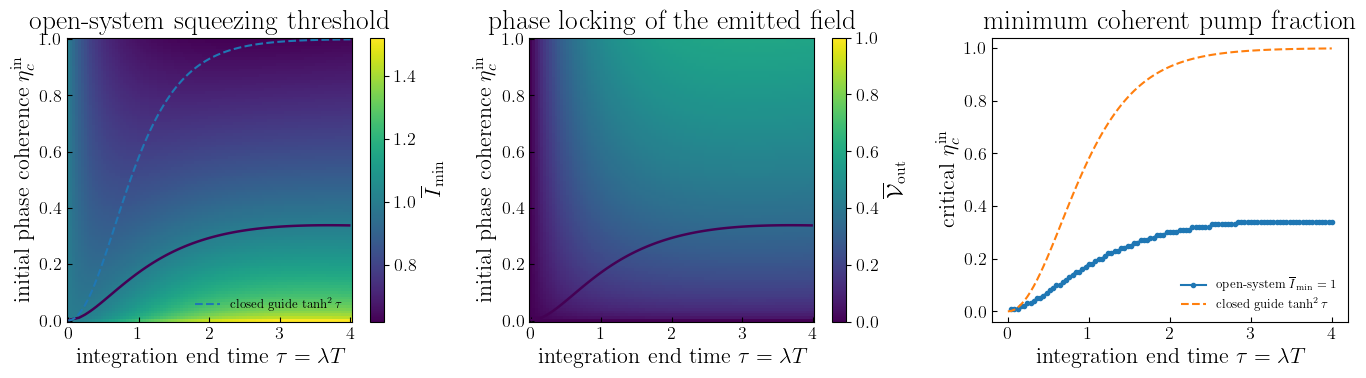

In [10]:
"""
Quantum-battery-powered nondegenerate parametric amplification
Option B: cascaded output-collector temporal-mode calculation

This is the rigorous output-filter/collector version of the open-system calculation.
Instead of reconstructing temporal modes from two-time output correlations, we append
auxiliary collector modes A and B downstream of the signal and idler output ports.
The collector modes absorb filtered temporal modes of the emitted fields.

Source modes:
    a = signal resonator mode
    b = idler resonator mode
    c = finite pump / quantum-battery mode

Collector modes:
    A = signal-output temporal-mode collector
    B = idler-output temporal-mode collector

Source Hamiltonian:
    H_I = i g ( c a^dag b^dag - c^dag a b )

Source master equation without collectors:
    d rho/dt = -i[H_I,rho]
              + kappa_a D[a] rho
              + kappa_b D[b] rho
              + kappa_c D[c] rho

Cascaded collector construction:
    L_s,a = sqrt(kappa_a) a,      L_A = sqrt(gamma_A) A
    L_s,b = sqrt(kappa_b) b,      L_B = sqrt(gamma_B) B

For the unidirectional cascade source -> collector, each channel is represented by
    L_tot = L_s + L_col,
    H_cas = (i/2) (L_s^dag L_col - L_col^dag L_s).

The final collector moments give a canonical temporal-mode output witness:
    N_A = <A^dag A>,
    N_B = <B^dag B>,
    M_AB = <A B>,
    I_min = N_A + N_B + 1 - 2 |M_AB|,
    V_int = 2 |M_AB|/(N_A + N_B + 1),
    C_amp = |M_AB|/sqrt(n_pair(n_pair+1)), n_pair=(N_A+N_B)/2.

This is more rigorous than the time-integrated equal-time proxy because A and B are
actual canonical quantum modes. The price is a much larger Hilbert space.

The script saves PDF only.

Recommended cluster workflow:
    python qb_paramp_optionB_cascaded_collectors.py --mode basic
    python qb_paramp_optionB_cascaded_collectors.py --mode threshold
    python qb_paramp_optionB_cascaded_collectors.py --mode gain
    python qb_paramp_optionB_cascaded_collectors.py --mode nbar

For high-resolution production, increase Na,Nb,Nc,NAf,NBf,Nt after checking the
printed edge populations and the physical bounds I_min >= 0 and C_amp <= 1.
"""

from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
import argparse
import time

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt


# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------

@dataclass
class Params:
    # Mean pump/battery energy
    nbar: float = 5.0

    # Source-mode Hilbert-space cutoffs
    Na: int = 8
    Nb: int = 8
    Nc: int = 18

    # Collector-mode Hilbert-space cutoffs.
    # The collector stores emitted photons; choose enough states to cover N_A,N_B.
    NAf: int = 6
    NBf: int = 6

    # Nominal classical pump strength lambda = g sqrt(nbar)
    lam: float = 1.0

    # Source output/leakage rates
    kappa_a: float = 2.5
    kappa_b: float = 2.5
    kappa_c: float = 0.02

    # Collector/filter bandwidths.  gamma_f ~ lambda is a sensible first choice.
    # The collector implements an exponential temporal filter ending at the final time.
    gamma_A: float = 1.0
    gamma_B: float = 1.0

    # Partially dephased coherent pump:
    # rho_c = w |alpha><alpha| + (1-w) rho_phase_randomized, eta_partial=w^2.
    eta_partial: float = 0.25

    # Time grid in units tau=lambda t
    tau_max: float = 4.0
    Nt: int = 101

    # Solver tolerances
    nsteps: int = 50000
    atol: float = 1e-8
    rtol: float = 1e-7

    # Plot/output
    outdir: str = "qb_paramp_outputs_optionB"

    @property
    def g(self) -> float:
        return self.lam / np.sqrt(self.nbar)

    @property
    def rho_reduced(self) -> float:
        return 2.0 * self.lam / np.sqrt(self.kappa_a * self.kappa_b)

    @property
    def stiff_pump_gain_estimate(self) -> float:
        rho = self.rho_reduced
        if rho >= 1.0:
            return np.inf
        return ((1.0 + rho**2) / (1.0 - rho**2)) ** 2

    @property
    def hilbert_dim(self) -> int:
        return self.Na * self.Nb * self.Nc * self.NAf * self.NBf


# -----------------------------------------------------------------------------
# Pump/battery states
# -----------------------------------------------------------------------------

def poisson_probs(nmax: int, nbar: float) -> np.ndarray:
    probs = np.empty(nmax, dtype=float)
    probs[0] = np.exp(-nbar)
    for n in range(1, nmax):
        probs[n] = probs[n - 1] * nbar / n
    total = probs.sum()
    if total <= 0:
        raise ValueError("Poisson probabilities underflowed.")
    return probs / total


def coherent_dm(N: int, nbar: float) -> qt.Qobj:
    ket = qt.coherent(N, np.sqrt(nbar))
    return qt.ket2dm(ket)


def phase_randomized_coherent_dm(N: int, nbar: float) -> qt.Qobj:
    probs = poisson_probs(N, nbar)
    return qt.Qobj(np.diag(probs), dims=[[N], [N]])


def fock_dm(N: int, n: int) -> qt.Qobj:
    if n >= N:
        raise ValueError(
            f"Fock index n={n} does not fit in cutoff N={N}. Increase Nc or lower nbar."
        )
    return qt.ket2dm(qt.basis(N, n))


def single_mode_eta(rho: qt.Qobj) -> float:
    N = rho.shape[0]
    c = qt.destroy(N)
    n_op = c.dag() * c
    n_mean = float(np.real(qt.expect(n_op, rho)))
    if n_mean <= 1e-14:
        return 0.0
    c_mean = complex(qt.expect(c, rho))
    return abs(c_mean) ** 2 / n_mean


def pump_state_dm(kind: str, p: Params) -> tuple[qt.Qobj, float]:
    if kind == "coherent":
        rho = coherent_dm(p.Nc, p.nbar)
    elif kind == "phase_randomized":
        rho = phase_randomized_coherent_dm(p.Nc, p.nbar)
    elif kind == "partial":
        w = np.sqrt(p.eta_partial)
        rho_coh = coherent_dm(p.Nc, p.nbar)
        rho_deph = phase_randomized_coherent_dm(p.Nc, p.nbar)
        rho = w * rho_coh + (1.0 - w) * rho_deph
        rho = rho / rho.tr()
    elif kind == "fock":
        rho = fock_dm(p.Nc, int(round(p.nbar)))
    else:
        raise ValueError(f"Unknown pump kind: {kind}")
    return rho, single_mode_eta(rho)


# -----------------------------------------------------------------------------
# Tensor-mode construction
# -----------------------------------------------------------------------------

def tensor_op(single_op: qt.Qobj, slot: int, dims: list[int]) -> qt.Qobj:
    ops = [qt.qeye(d) for d in dims]
    ops[slot] = single_op
    return qt.tensor(*ops)


@dataclass
class Operators:
    a: qt.Qobj
    b: qt.Qobj
    c: qt.Qobj
    A: qt.Qobj
    B: qt.Qobj


def build_operators(p: Params) -> Operators:
    dims = [p.Na, p.Nb, p.Nc, p.NAf, p.NBf]
    a = tensor_op(qt.destroy(p.Na), 0, dims)
    b = tensor_op(qt.destroy(p.Nb), 1, dims)
    c = tensor_op(qt.destroy(p.Nc), 2, dims)
    A = tensor_op(qt.destroy(p.NAf), 3, dims)
    B = tensor_op(qt.destroy(p.NBf), 4, dims)
    return Operators(a=a, b=b, c=c, A=A, B=B)


def build_cascaded_model(p: Params) -> tuple[qt.Qobj, list[qt.Qobj], Operators]:
    op = build_operators(p)
    a, b, c, A, B = op.a, op.b, op.c, op.A, op.B

    H_source = 1j * p.g * (c * a.dag() * b.dag() - c.dag() * a * b)

    # Cascaded signal-output channel: source a -> collector A.
    Ls_a = np.sqrt(p.kappa_a) * a
    Lc_A = np.sqrt(p.gamma_A) * A
    H_cas_a = 0.5j * (Ls_a.dag() * Lc_A - Lc_A.dag() * Ls_a)
    Ltot_a = Ls_a + Lc_A

    # Cascaded idler-output channel: source b -> collector B.
    Ls_b = np.sqrt(p.kappa_b) * b
    Lc_B = np.sqrt(p.gamma_B) * B
    H_cas_b = 0.5j * (Ls_b.dag() * Lc_B - Lc_B.dag() * Ls_b)
    Ltot_b = Ls_b + Lc_B

    H = H_source + H_cas_a + H_cas_b

    c_ops: list[qt.Qobj] = [Ltot_a, Ltot_b]
    if p.kappa_c > 0:
        c_ops.append(np.sqrt(p.kappa_c) * c)

    return H, c_ops, op


def initial_state(kind: str, p: Params) -> tuple[qt.Qobj, float]:
    rho_a = qt.ket2dm(qt.basis(p.Na, 0))
    rho_b = qt.ket2dm(qt.basis(p.Nb, 0))
    rho_c, eta = pump_state_dm(kind, p)
    rho_A = qt.ket2dm(qt.basis(p.NAf, 0))
    rho_B = qt.ket2dm(qt.basis(p.NBf, 0))
    return qt.tensor(rho_a, rho_b, rho_c, rho_A, rho_B), eta


# -----------------------------------------------------------------------------
# Collector diagnostics
# -----------------------------------------------------------------------------

def temporal_certifiers_from_collectors(
    N_A: np.ndarray,
    N_B: np.ndarray,
    M_AB: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    N_A = np.real(np.asarray(N_A, dtype=complex))
    N_B = np.real(np.asarray(N_B, dtype=complex))
    M_AB = np.asarray(M_AB, dtype=complex)

    denom = N_A + N_B + 1.0
    Imin = denom - 2.0 * np.abs(M_AB)
    Imax = denom + 2.0 * np.abs(M_AB)

    V = np.zeros_like(Imin, dtype=float)
    mask = denom > 1e-14
    V[mask] = 2.0 * np.abs(M_AB[mask]) / denom[mask]

    n_pair = 0.5 * (N_A + N_B)
    C = np.zeros_like(n_pair, dtype=float)
    mask_pair = n_pair > 1e-14
    C[mask_pair] = np.abs(M_AB[mask_pair]) / np.sqrt(
        n_pair[mask_pair] * (n_pair[mask_pair] + 1.0)
    )

    return V, Imin, Imax, C, n_pair


def physicality_report(label: str, Imin: np.ndarray, C: np.ndarray) -> None:
    min_I = float(np.nanmin(Imin))
    max_C = float(np.nanmax(C))
    print(f"    physicality check for {label}: min Imin={min_I:.6g}, max C={max_C:.6g}")
    if min_I < -1e-6:
        print("    WARNING: Imin < 0. Increase cutoffs or check cascade convention.")
    if max_C > 1.0 + 1e-5:
        print("    WARNING: C_amp > 1. Increase cutoffs or check cascade convention.")


@dataclass
class CollectorResult:
    label: str
    eta_in: float
    tlist: np.ndarray
    tau_grid: np.ndarray
    N_A: np.ndarray
    N_B: np.ndarray
    M_AB: np.ndarray
    V: np.ndarray
    Imin: np.ndarray
    Imax: np.ndarray
    C: np.ndarray
    n_pair: np.ndarray
    eta_c: np.ndarray
    source_n_a: np.ndarray
    source_n_b: np.ndarray
    source_n_c: np.ndarray
    edge_source_a: np.ndarray
    edge_source_b: np.ndarray
    edge_pump_c: np.ndarray
    edge_col_A: np.ndarray
    edge_col_B: np.ndarray
    phi: np.ndarray
    I_fringe_final: np.ndarray


def solve_collector_case(kind: str, p: Params) -> CollectorResult:
    H, c_ops, op = build_cascaded_model(p)
    rho0, eta_in = initial_state(kind, p)

    tmax = p.tau_max / p.lam
    tlist = np.linspace(0.0, tmax, p.Nt)
    tau_grid = p.lam * tlist

    a, b, c, A, B = op.a, op.b, op.c, op.A, op.B

    n_a_op = a.dag() * a
    n_b_op = b.dag() * b
    n_c_op = c.dag() * c
    n_A_op = A.dag() * A
    n_B_op = B.dag() * B
    AB_op = A * B
    c_mean_op = c

    # Edge-population projectors to diagnose cutoffs.
    P_a_edge = tensor_op(qt.basis(p.Na, p.Na - 1) * qt.basis(p.Na, p.Na - 1).dag(), 0, [p.Na, p.Nb, p.Nc, p.NAf, p.NBf])
    P_b_edge = tensor_op(qt.basis(p.Nb, p.Nb - 1) * qt.basis(p.Nb, p.Nb - 1).dag(), 1, [p.Na, p.Nb, p.Nc, p.NAf, p.NBf])
    P_c_edge = tensor_op(qt.basis(p.Nc, p.Nc - 1) * qt.basis(p.Nc, p.Nc - 1).dag(), 2, [p.Na, p.Nb, p.Nc, p.NAf, p.NBf])
    P_A_edge = tensor_op(qt.basis(p.NAf, p.NAf - 1) * qt.basis(p.NAf, p.NAf - 1).dag(), 3, [p.Na, p.Nb, p.Nc, p.NAf, p.NBf])
    P_B_edge = tensor_op(qt.basis(p.NBf, p.NBf - 1) * qt.basis(p.NBf, p.NBf - 1).dag(), 4, [p.Na, p.Nb, p.Nc, p.NAf, p.NBf])

    e_ops = [
        n_A_op, n_B_op, AB_op,
        n_a_op, n_b_op, n_c_op, c_mean_op,
        P_a_edge, P_b_edge, P_c_edge, P_A_edge, P_B_edge,
    ]

    options = {
        "nsteps": p.nsteps,
        "atol": p.atol,
        "rtol": p.rtol,
        "store_states": False,
    }

    print(
        f"  mesolve {kind}: Hilbert D={p.hilbert_dim}, "
        f"Liouville size~{p.hilbert_dim**2:.3e}, Nt={p.Nt}"
    )
    tic = time.time()
    sol = qt.mesolve(H, rho0, tlist, c_ops, e_ops=e_ops, options=options)
    toc = time.time()
    print(f"  finished {kind} in {toc - tic:.1f} s")

    N_A = np.real(np.asarray(sol.expect[0], dtype=complex))
    N_B = np.real(np.asarray(sol.expect[1], dtype=complex))
    M_AB = np.asarray(sol.expect[2], dtype=complex)
    n_a = np.real(np.asarray(sol.expect[3], dtype=complex))
    n_b = np.real(np.asarray(sol.expect[4], dtype=complex))
    n_c = np.real(np.asarray(sol.expect[5], dtype=complex))
    c_mean = np.asarray(sol.expect[6], dtype=complex)

    edge_source_a = np.real(np.asarray(sol.expect[7], dtype=complex))
    edge_source_b = np.real(np.asarray(sol.expect[8], dtype=complex))
    edge_pump_c = np.real(np.asarray(sol.expect[9], dtype=complex))
    edge_col_A = np.real(np.asarray(sol.expect[10], dtype=complex))
    edge_col_B = np.real(np.asarray(sol.expect[11], dtype=complex))

    V, Imin, Imax, C, n_pair = temporal_certifiers_from_collectors(N_A, N_B, M_AB)

    eta_c = np.zeros_like(n_c, dtype=float)
    mask = n_c > 1e-14
    eta_c[mask] = np.abs(c_mean[mask]) ** 2 / n_c[mask]

    phi = np.linspace(0.0, 2.0 * np.pi, 401)
    denom_final = N_A[-1] + N_B[-1] + 1.0
    M_final = M_AB[-1]
    I_fringe_final = denom_final + 2.0 * np.real(np.exp(-1j * phi) * M_final)

    physicality_report(kind, Imin, C)
    print(
        f"    final: eta_in={eta_in:.4f}, V={V[-1]:.4f}, Imin={Imin[-1]:.4f}, "
        f"C={C[-1]:.4f}, n_pair={n_pair[-1]:.4f}, "
        f"edge max source/collector="
        f"{max(edge_source_a.max(), edge_source_b.max(), edge_pump_c.max()):.2e}/"
        f"{max(edge_col_A.max(), edge_col_B.max()):.2e}"
    )

    return CollectorResult(
        label=kind,
        eta_in=eta_in,
        tlist=tlist,
        tau_grid=tau_grid,
        N_A=N_A,
        N_B=N_B,
        M_AB=M_AB,
        V=V,
        Imin=Imin,
        Imax=Imax,
        C=C,
        n_pair=n_pair,
        eta_c=eta_c,
        source_n_a=n_a,
        source_n_b=n_b,
        source_n_c=n_c,
        edge_source_a=edge_source_a,
        edge_source_b=edge_source_b,
        edge_pump_c=edge_pump_c,
        edge_col_A=edge_col_A,
        edge_col_B=edge_col_B,
        phi=phi,
        I_fringe_final=I_fringe_final,
    )


# -----------------------------------------------------------------------------
# Linear mixing for the partially dephased family
# -----------------------------------------------------------------------------

@dataclass
class RawCollectorMoments:
    eta_in: float
    tlist: np.ndarray
    tau_grid: np.ndarray
    N_A: np.ndarray
    N_B: np.ndarray
    M_AB: np.ndarray
    n_pair: np.ndarray


def to_raw_collector(r: CollectorResult) -> RawCollectorMoments:
    return RawCollectorMoments(
        eta_in=r.eta_in,
        tlist=r.tlist,
        tau_grid=r.tau_grid,
        N_A=r.N_A,
        N_B=r.N_B,
        M_AB=r.M_AB,
        n_pair=r.n_pair,
    )


def mixed_collector_certifiers(
    coh: RawCollectorMoments,
    deph: RawCollectorMoments,
    eta_grid: np.ndarray,
) -> dict[str, np.ndarray]:
    Nt = len(coh.tau_grid)
    Imin_map = np.zeros((len(eta_grid), Nt))
    V_map = np.zeros((len(eta_grid), Nt))
    C_map = np.zeros((len(eta_grid), Nt))
    n_pair_map = np.zeros((len(eta_grid), Nt))

    for i, eta in enumerate(eta_grid):
        w = np.sqrt(eta)
        N_A = w * coh.N_A + (1.0 - w) * deph.N_A
        N_B = w * coh.N_B + (1.0 - w) * deph.N_B
        M_AB = w * coh.M_AB + (1.0 - w) * deph.M_AB
        V, Imin, Imax, C, n_pair = temporal_certifiers_from_collectors(N_A, N_B, M_AB)
        Imin_map[i, :] = Imin
        V_map[i, :] = V
        C_map[i, :] = C
        n_pair_map[i, :] = n_pair

    eta_threshold = np.full(Nt, np.nan)
    for j in range(Nt):
        good = Imin_map[:, j] < 1.0
        if np.any(good):
            idx = int(np.argmax(good))
            if idx == 0:
                eta_threshold[j] = eta_grid[0]
            else:
                # Linear interpolation in eta for a smoother threshold.
                x0, x1 = eta_grid[idx - 1], eta_grid[idx]
                y0, y1 = Imin_map[idx - 1, j], Imin_map[idx, j]
                if abs(y1 - y0) > 1e-14:
                    eta_threshold[j] = x0 + (1.0 - y0) * (x1 - x0) / (y1 - y0)
                else:
                    eta_threshold[j] = x1

    return {
        "eta_grid": eta_grid,
        "tau_grid": coh.tau_grid,
        "Imin_map": Imin_map,
        "V_map": V_map,
        "C_map": C_map,
        "n_pair_map": n_pair_map,
        "eta_threshold": eta_threshold,
    }


def crossing_threshold(eta_grid: np.ndarray, y_values: np.ndarray, target: float = 1.0) -> float:
    y = np.asarray(y_values, dtype=float)
    good = y < target
    if not np.any(good):
        return np.nan
    idx = int(np.argmax(good))
    if idx == 0:
        return float(eta_grid[0])
    x0, x1 = eta_grid[idx - 1], eta_grid[idx]
    y0, y1 = y[idx - 1], y[idx]
    if abs(y1 - y0) < 1e-14:
        return float(x1)
    return float(x0 + (target - y0) * (x1 - x0) / (y1 - y0))


def stiff_pump_gain_from_rho(rho: np.ndarray | float) -> np.ndarray | float:
    rho_arr = np.asarray(rho)
    out = np.full_like(rho_arr, np.inf, dtype=float)
    mask = rho_arr < 1.0
    out[mask] = ((1.0 + rho_arr[mask] ** 2) / (1.0 - rho_arr[mask] ** 2)) ** 2
    if np.ndim(rho) == 0:
        return float(out)
    return out


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def ensure_outdir(p: Params) -> Path:
    outdir = Path.cwd() / p.outdir
    outdir.mkdir(parents=True, exist_ok=True)
    return outdir


def label_for_kind(kind: str, p: Params) -> str:
    return {
        "coherent": r"coherent, $\eta_c^{\rm in}=1$",
        "partial": rf"partially dephased, $\eta_c^{{\rm in}}\simeq {p.eta_partial:.2f}$",
        "phase_randomized": r"phase randomized, $\eta_c^{\rm in}=0$",
        "fock": r"Fock",
    }.get(kind, kind)


def set_plot_style() -> None:
    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })


def plot_basic_collectors(results: dict[str, CollectorResult], p: Params) -> None:
    set_plot_style()
    fig, axs = plt.subplots(2, 2, figsize=(9.4, 6.8))

    for kind, r in results.items():
        label = label_for_kind(kind, p)
        tau = r.tau_grid
        axs[0, 0].plot(tau, r.V, label=label)
        axs[0, 1].plot(tau, r.Imin, label=label)
        axs[1, 0].plot(tau, r.C, label=label)
        axs[1, 1].plot(tau, r.n_pair, label=label)

    axs[0, 0].set_title(r"collector-mode phase locking")
    axs[0, 0].set_xlabel(r"final time $\tau=\lambda T$")
    axs[0, 0].set_ylabel(r"${\cal V}_{f}$")
    axs[0, 0].set_ylim(-0.04, 1.04)

    axs[0, 1].axhline(1.0, linestyle="-.", label=r"$I_{\min}^{(f)}=1$")
    axs[0, 1].set_title(r"collector-mode squeezing certifier")
    axs[0, 1].set_xlabel(r"final time $\tau=\lambda T$")
    axs[0, 1].set_ylabel(r"$I_{\min}^{(f)}$")
    axs[0, 1].set_yscale("log")

    axs[1, 0].axhline(1.0, linestyle=":", label="ideal TMSV")
    axs[1, 0].set_title(r"collector-mode pair coherence")
    axs[1, 0].set_xlabel(r"final time $\tau=\lambda T$")
    axs[1, 0].set_ylabel(r"$C_f$")
    axs[1, 0].set_ylim(-0.04, 1.08)

    axs[1, 1].set_title(r"photons in collected output modes")
    axs[1, 1].set_xlabel(r"final time $\tau=\lambda T$")
    axs[1, 1].set_ylabel(r"$n_f=(N_A+N_B)/2$")

    for ax in axs.flat:
        ax.tick_params(direction="in")
        ax.legend(frameon=False)

    fig.tight_layout()
    pdf_path = ensure_outdir(p) / "qb_paramp_optionB_collectors_basic.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved collector basic figure to:\n  {pdf_path}")

    fig2, ax = plt.subplots(figsize=(7.2, 4.2))
    for kind, r in results.items():
        ax.plot(r.phi / np.pi, r.I_fringe_final, label=label_for_kind(kind, p))
    ax.axhline(1.0, linestyle="-.", label=r"$I=1$")
    ax.set_xlabel(r"analysis phase $\phi/\pi$")
    ax.set_ylabel(r"$I_f(\phi)$")
    ax.set_title(r"collector-mode output interference fringe")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)
    fig2.tight_layout()
    pdf_path2 = ensure_outdir(p) / "qb_paramp_optionB_collectors_fringe.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")
    print(f"Saved collector fringe figure to:\n  {pdf_path2}")


def plot_threshold_map(scan: dict[str, np.ndarray], p: Params, filename: str) -> None:
    set_plot_style()
    tau = scan["tau_grid"]
    eta = scan["eta_grid"]
    T, E = np.meshgrid(tau, eta)
    Imin = scan["Imin_map"]
    V = scan["V_map"]
    eta_thr = scan["eta_threshold"]
    closed = np.tanh(tau) ** 2

    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))
    im0 = axs[0].pcolormesh(T, E, Imin, shading="auto")
    cbar0 = fig.colorbar(im0, ax=axs[0])
    cbar0.set_label(r"$I_{\min}^{(f)}$")
    axs[0].contour(T, E, Imin, levels=[1.0], linewidths=1.8)
    axs[0].plot(tau, closed, linestyle="--", label=r"closed guide $\tanh^2\tau$")
    axs[0].set_xlabel(r"final time $\tau=\lambda T$")
    axs[0].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[0].set_title(r"collector-mode squeezing threshold")
    axs[0].legend(frameon=False)

    im1 = axs[1].pcolormesh(T, E, V, shading="auto", vmin=0.0, vmax=1.0)
    cbar1 = fig.colorbar(im1, ax=axs[1])
    cbar1.set_label(r"${\cal V}_{f}$")
    axs[1].contour(T, E, Imin, levels=[1.0], linewidths=1.8)
    axs[1].set_xlabel(r"final time $\tau=\lambda T$")
    axs[1].set_ylabel(r"initial phase coherence $\eta_c^{\rm in}$")
    axs[1].set_title(r"phase locking of collected modes")

    axs[2].plot(tau, eta_thr, "o-", ms=3, label=r"collector $I_{\min}^{(f)}=1$")
    axs[2].plot(tau, closed, linestyle="--", label=r"closed guide $\tanh^2\tau$")
    axs[2].set_xlabel(r"final time $\tau=\lambda T$")
    axs[2].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[2].set_ylim(-0.04, 1.04)
    axs[2].set_title(r"minimum coherent pump fraction")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()
    pdf_path = ensure_outdir(p) / filename
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved collector threshold map to:\n  {pdf_path}")


# -----------------------------------------------------------------------------
# Modes/runs
# -----------------------------------------------------------------------------

def print_params(p: Params, title: str) -> None:
    print(title)
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}, NAf={p.NAf}, NBf={p.NBf}")
    print(f"Hilbert dimension D = {p.hilbert_dim}; Liouville dimension D^2 ~ {p.hilbert_dim**2:.3e}")
    print(f"lambda = {p.lam:.6f}, g = {p.g:.6f}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"gamma_A = {p.gamma_A:.3f}, gamma_B = {p.gamma_B:.3f}")
    print(f"rho = {p.rho_reduced:.3f}, G0 = {p.stiff_pump_gain_estimate:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print()


def run_basic(p: Params, kinds: list[str]) -> None:
    print_params(p, "Option B: cascaded collector basic run")
    results: dict[str, CollectorResult] = {}
    for kind in kinds:
        print(f"Solving collector case: {kind}")
        results[kind] = solve_collector_case(kind, p)
        print()
    plot_basic_collectors(results, p)


def run_threshold(p: Params, n_eta: int = 101) -> None:
    print_params(p, "Option B: collector phase-coherence threshold map")
    coh = solve_collector_case("coherent", p)
    deph = solve_collector_case("phase_randomized", p)
    eta_grid = np.linspace(0.0, 1.0, n_eta)
    scan = mixed_collector_certifiers(to_raw_collector(coh), to_raw_collector(deph), eta_grid)
    print("Selected collector threshold values")
    for idx in np.linspace(0, len(scan["tau_grid"]) - 1, 8, dtype=int):
        tau = scan["tau_grid"][idx]
        et = scan["eta_threshold"][idx]
        print(f"  tau={tau:.3f}, eta_crit={et if np.isfinite(et) else np.nan:.4f}")
    plot_threshold_map(scan, p, "qb_paramp_optionB_collectors_threshold.pdf")


def run_gain_scan(p_base: Params, rho_values: np.ndarray, n_eta: int = 101) -> None:
    print_params(p_base, "Option B: collector gain-threshold scan")
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    rho_list = []
    G0_list = []
    eta_crit_list = []
    n_pair_eta0_list = []
    n_pair_eta1_list = []
    I0_list = []
    I1_list = []

    selected_curves = []

    for rix, rho in enumerate(rho_values):
        lam = 0.5 * float(rho) * np.sqrt(p_base.kappa_a * p_base.kappa_b)
        p = replace(p_base, lam=lam)
        print(f"\nScanning rho={rho:.3f}, lambda={lam:.4f}, G0={stiff_pump_gain_from_rho(float(rho)):.3f}")
        coh = solve_collector_case("coherent", p)
        deph = solve_collector_case("phase_randomized", p)
        mix = mixed_collector_certifiers(to_raw_collector(coh), to_raw_collector(deph), eta_grid)
        I_final = mix["Imin_map"][:, -1]
        eta_crit = crossing_threshold(eta_grid, I_final, 1.0)
        rho_list.append(float(rho))
        G0_list.append(float(stiff_pump_gain_from_rho(float(rho))))
        eta_crit_list.append(eta_crit)
        I0_list.append(float(I_final[0]))
        I1_list.append(float(I_final[-1]))
        n_pair_eta0_list.append(float(mix["n_pair_map"][0, -1]))
        n_pair_eta1_list.append(float(mix["n_pair_map"][-1, -1]))
        print(
            f"  eta_crit={eta_crit if np.isfinite(eta_crit) else np.nan:.4f}, "
            f"Imin eta0/eta1={I_final[0]:.4f}/{I_final[-1]:.4f}, "
            f"n_pair eta0/eta1={mix['n_pair_map'][0,-1]:.4f}/{mix['n_pair_map'][-1,-1]:.4f}"
        )
        if rix in {0, len(rho_values)//3, 2*len(rho_values)//3, len(rho_values)-1}:
            selected_curves.append((float(rho), float(stiff_pump_gain_from_rho(float(rho))), I_final.copy()))

    rho_arr = np.array(rho_list)
    G0_arr = np.array(G0_list)
    eta_arr = np.array(eta_crit_list)
    n0 = np.array(n_pair_eta0_list)
    n1 = np.array(n_pair_eta1_list)

    set_plot_style()
    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))
    axs[0].plot(rho_arr, eta_arr, "o-", label=r"$I_{\min}^{(f)}=1$")
    axs[0].set_xlabel(r"reduced pump strength $\rho=2\lambda/\sqrt{\kappa_a\kappa_b}$")
    axs[0].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[0].set_title(r"collector threshold")
    axs[0].set_ylim(-0.04, 1.04)
    axs[0].legend(frameon=False)

    axs[1].plot(G0_arr, eta_arr, "o-", label=r"$I_{\min}^{(f)}=1$")
    axs[1].set_xscale("log")
    axs[1].set_xlabel(r"stiff-pump gain estimate $G_0$")
    axs[1].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[1].set_title(r"threshold versus nominal gain")
    axs[1].set_ylim(-0.04, 1.04)
    axs[1].legend(frameon=False)

    axs[2].plot(rho_arr, n1, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[2].plot(rho_arr, n0, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[2].set_xlabel(r"reduced pump strength $\rho$")
    axs[2].set_ylabel(r"collected pair number $n_f$")
    axs[2].set_title(r"collected energy is weakly phase-sensitive")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")
    fig.tight_layout()
    pdf_path = ensure_outdir(p_base) / "qb_paramp_optionB_collectors_gain_threshold.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved collector gain-threshold figure to:\n  {pdf_path}")

    fig2, ax = plt.subplots(figsize=(7.2, 4.4))
    for rho, G0, Icurve in selected_curves:
        ax.plot(eta_grid, Icurve, label=rf"$\rho={rho:.2f}$, $G_0={G0:.1f}$")
    ax.axhline(1.0, linestyle="-.", label=r"$I_{\min}^{(f)}=1$")
    ax.set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    ax.set_ylabel(r"final $I_{\min}^{(f)}(T)$")
    ax.set_title(r"collector threshold extraction")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)
    fig2.tight_layout()
    pdf_path2 = ensure_outdir(p_base) / "qb_paramp_optionB_collectors_gain_extraction.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")
    print(f"Saved collector gain-extraction figure to:\n  {pdf_path2}")


def auto_cutoffs_for_nbar_optionB(
    nbar: float,
    Na_min: int,
    Nb_min: int,
    NAf: int,
    NBf: int,
) -> tuple[int, int, int, int, int]:
    Nc_tail = int(np.ceil(nbar + 5.5 * np.sqrt(nbar + 1.0) + 6.0))
    Nc_fock_safe = int(round(nbar)) + 4
    Nc = max(12, Nc_tail, Nc_fock_safe)
    return Na_min, Nb_min, Nc, NAf, NBf


def run_nbar_scan(p_base: Params, nbar_values: np.ndarray, rho_fixed: float, n_eta: int = 101) -> None:
    print_params(p_base, "Option B: collector nbar-threshold scan")
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    nbar_list = []
    eta_crit_list = []
    dep0_list = []
    dep1_list = []
    n0_list = []
    n1_list = []
    selected_curves = []

    for nix, nbar in enumerate(nbar_values):
        Na, Nb, Nc, NAf, NBf = auto_cutoffs_for_nbar_optionB(
            float(nbar), p_base.Na, p_base.Nb, p_base.NAf, p_base.NBf
        )
        lam = 0.5 * rho_fixed * np.sqrt(p_base.kappa_a * p_base.kappa_b)
        p = replace(p_base, nbar=float(nbar), lam=lam, Na=Na, Nb=Nb, Nc=Nc, NAf=NAf, NBf=NBf)
        print(f"\nScanning nbar={nbar:.3f}, cutoffs Na={Na},Nb={Nb},Nc={Nc},NAf={NAf},NBf={NBf}")
        coh = solve_collector_case("coherent", p)
        deph = solve_collector_case("phase_randomized", p)
        mix = mixed_collector_certifiers(to_raw_collector(coh), to_raw_collector(deph), eta_grid)
        I_final = mix["Imin_map"][:, -1]
        eta_crit = crossing_threshold(eta_grid, I_final, 1.0)
        n0 = float(mix["n_pair_map"][0, -1])
        n1 = float(mix["n_pair_map"][-1, -1])
        nbar_list.append(float(nbar))
        eta_crit_list.append(eta_crit)
        n0_list.append(n0)
        n1_list.append(n1)
        dep0_list.append(n0 / float(nbar))
        dep1_list.append(n1 / float(nbar))
        print(
            f"  eta_crit={eta_crit if np.isfinite(eta_crit) else np.nan:.4f}, "
            f"Imin eta0/eta1={I_final[0]:.4f}/{I_final[-1]:.4f}, n_pair eta0/eta1={n0:.4f}/{n1:.4f}"
        )
        if nix in {0, len(nbar_values)//3, 2*len(nbar_values)//3, len(nbar_values)-1}:
            selected_curves.append((float(nbar), I_final.copy()))

    nbar_arr = np.array(nbar_list)
    eta_arr = np.array(eta_crit_list)
    n0_arr = np.array(n0_list)
    n1_arr = np.array(n1_list)
    dep0_arr = np.array(dep0_list)
    dep1_arr = np.array(dep1_list)

    set_plot_style()
    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))
    axs[0].plot(nbar_arr, eta_arr, "o-", label=rf"$\rho={rho_fixed:.2f}$")
    axs[0].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[0].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[0].set_title(r"collector battery-size dependence")
    axs[0].set_ylim(-0.04, 1.04)
    axs[0].legend(frameon=False)

    axs[1].plot(nbar_arr, dep1_arr, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[1].plot(nbar_arr, dep0_arr, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[1].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[1].set_ylabel(r"collected pair number$/\bar n_c$")
    axs[1].set_title(r"relative battery use")
    axs[1].legend(frameon=False)

    axs[2].plot(nbar_arr, n1_arr, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[2].plot(nbar_arr, n0_arr, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[2].set_xlabel(r"pump/battery energy $\bar n_c$")
    axs[2].set_ylabel(r"collected pair number $n_f$")
    axs[2].set_title(r"collected energy at fixed operating point")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")
    fig.tight_layout()
    pdf_path = ensure_outdir(p_base) / "qb_paramp_optionB_collectors_nbar_threshold.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved collector nbar-threshold figure to:\n  {pdf_path}")

    fig2, ax = plt.subplots(figsize=(7.2, 4.4))
    for nbar, Icurve in selected_curves:
        ax.plot(eta_grid, Icurve, label=rf"$\bar n_c={nbar:.1f}$")
    ax.axhline(1.0, linestyle="-.", label=r"$I_{\min}^{(f)}=1$")
    ax.set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    ax.set_ylabel(r"final $I_{\min}^{(f)}(T)$")
    ax.set_title(r"collector threshold extraction at fixed $\rho$")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)
    fig2.tight_layout()
    pdf_path2 = ensure_outdir(p_base) / "qb_paramp_optionB_collectors_nbar_extraction.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")
    print(f"Saved collector nbar-extraction figure to:\n  {pdf_path2}")


# -----------------------------------------------------------------------------
# CLI
# -----------------------------------------------------------------------------

def make_params_from_args(args: argparse.Namespace) -> Params:
    return Params(
        nbar=args.nbar,
        Na=args.Na,
        Nb=args.Nb,
        Nc=args.Nc,
        NAf=args.NAf,
        NBf=args.NBf,
        lam=args.lam,
        kappa_a=args.kappa_a,
        kappa_b=args.kappa_b,
        kappa_c=args.kappa_c,
        gamma_A=args.gamma_A,
        gamma_B=args.gamma_B,
        eta_partial=args.eta_partial,
        tau_max=args.tau_max,
        Nt=args.Nt,
        nsteps=args.nsteps,
        atol=args.atol,
        rtol=args.rtol,
        outdir=args.outdir,
    )


def parse_float_list(s: str) -> np.ndarray:
    return np.array([float(x.strip()) for x in s.split(",") if x.strip()], dtype=float)


def main() -> None:
    parser = argparse.ArgumentParser(description="Option B cascaded-collector simulation for QB-powered parametric amplifier")
    parser.add_argument("--mode", choices=["basic", "threshold", "gain", "nbar", "all"], default="basic")

    parser.add_argument("--nbar", type=float, default=5.0)
    parser.add_argument("--Na", type=int, default=8)
    parser.add_argument("--Nb", type=int, default=8)
    parser.add_argument("--Nc", type=int, default=18)
    parser.add_argument("--NAf", type=int, default=6)
    parser.add_argument("--NBf", type=int, default=6)
    parser.add_argument("--lam", type=float, default=1.0)

    parser.add_argument("--kappa_a", type=float, default=2.5)
    parser.add_argument("--kappa_b", type=float, default=2.5)
    parser.add_argument("--kappa_c", type=float, default=0.02)
    parser.add_argument("--gamma_A", type=float, default=1.0)
    parser.add_argument("--gamma_B", type=float, default=1.0)
    parser.add_argument("--eta_partial", type=float, default=0.25)

    parser.add_argument("--tau_max", type=float, default=4.0)
    parser.add_argument("--Nt", type=int, default=101)
    parser.add_argument("--nsteps", type=int, default=50000)
    parser.add_argument("--atol", type=float, default=1e-8)
    parser.add_argument("--rtol", type=float, default=1e-7)
    parser.add_argument("--outdir", type=str, default="qb_paramp_outputs_optionB")

    parser.add_argument("--kinds", type=str, default="coherent,partial,phase_randomized,fock")
    parser.add_argument("--n_eta", type=int, default=101)
    parser.add_argument("--rho_values", type=str, default="0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.92")
    parser.add_argument("--nbar_values", type=str, default="1.5,2.0,3.0,5.0,8.0,10.0,12.0")
    parser.add_argument("--rho_fixed", type=float, default=0.8)

    args = parser.parse_args()
    p = make_params_from_args(args)

    kinds = [k.strip() for k in args.kinds.split(",") if k.strip()]
    if int(round(p.nbar)) >= p.Nc and "fock" in kinds:
        print("Warning: Fock pump does not fit in Nc cutoff. Removing Fock case.")
        kinds = [k for k in kinds if k != "fock"]

    if p.mode in {"basic", "all"}:
        run_basic(p, kinds)
    if p.mode in {"threshold", "all"}:
        run_threshold(p, n_eta=args.n_eta)
    if p.mode in {"gain", "all"}:
        run_gain_scan(p, parse_float_list(args.rho_values), n_eta=args.n_eta)
    if p.mode in {"nbar", "all"}:
        run_nbar_scan(p, parse_float_list(args.nbar_values), rho_fixed=args.rho_fixed, n_eta=args.n_eta)


if __name__ == "__main__":
    main()

Gain / pump-strength threshold scan: Option A
nbar = 5.000
cutoffs: Na=12, Nb=12, Nc=18
kappa_a = 2.500, kappa_b = 2.500, kappa_c = 0.020
tau_max = 4.000, Nt = 101
lambda is varied through rho = 2 lambda/sqrt(kappa_a kappa_b).

Scanning rho = 0.250 ...
  G0=1.284, eta_crit=0.0476, Imin(eta=1)=0.8216, Imin(eta=0)=1.0497, Npair eta1/eta0=0.7958/0.7958
Scanning rho = 0.302 ...
  G0=1.440, eta_crit=0.0683, Imin(eta=1)=0.7934, Imin(eta=0)=1.0730, Npair eta1/eta0=0.9689/0.9689
Scanning rho = 0.353 ...
  G0=1.651, eta_crit=0.0917, Imin(eta=1)=0.7680, Imin(eta=0)=1.1007, Npair eta1/eta0=1.1410/1.1410
Scanning rho = 0.405 ...
  G0=1.936, eta_crit=0.1174, Imin(eta=1)=0.7451, Imin(eta=0)=1.1328, Npair eta1/eta0=1.3128/1.3128
Scanning rho = 0.456 ...
  G0=2.327, eta_crit=0.1449, Imin(eta=1)=0.7244, Imin(eta=0)=1.1693, Npair eta1/eta0=1.4845/1.4845
Scanning rho = 0.508 ...
  G0=2.871, eta_crit=0.1736, Imin(eta=1)=0.7057, Imin(eta=0)=1.2101, Npair eta1/eta0=1.6557/1.6557
Scanning rho = 0.559 ...
  G

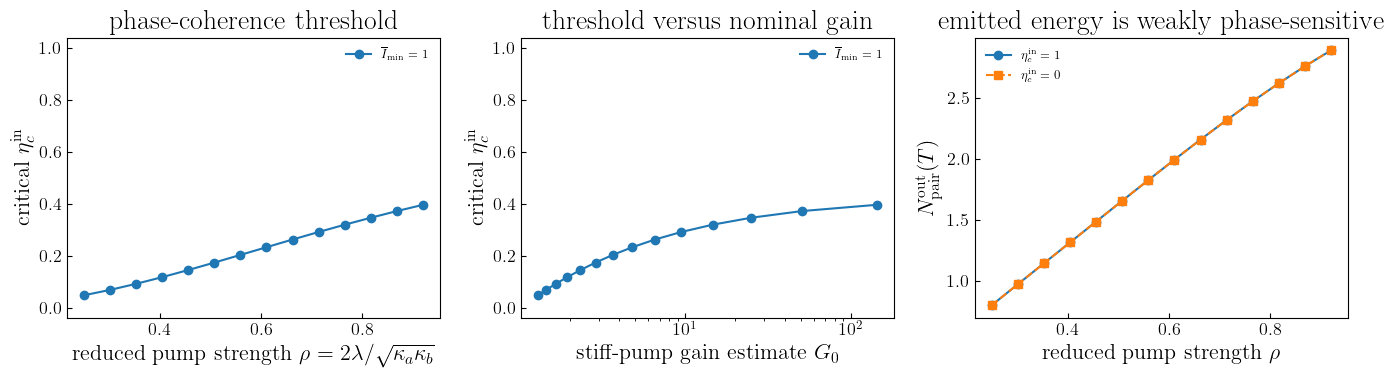

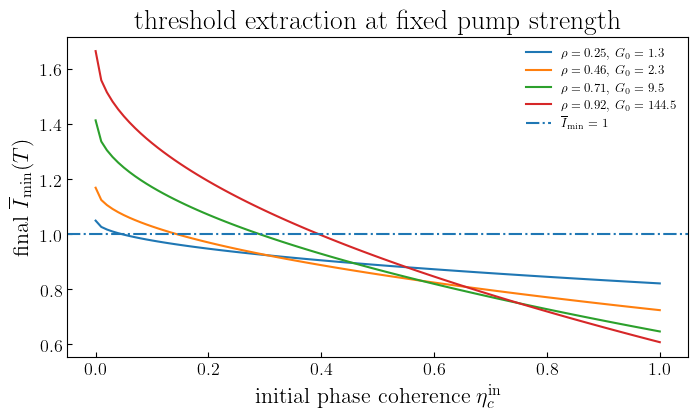

In [11]:
# -----------------------------------------------------------------------------
# Gain / pump-strength threshold scan: eta_crit versus rho and G0
# Option A: stable time-integrated instantaneous-output certifier
# -----------------------------------------------------------------------------

from dataclasses import replace


def stiff_pump_gain_from_rho(rho: np.ndarray | float) -> np.ndarray | float:
    """Below-threshold stiff-pump gain estimate."""
    rho = np.asarray(rho)
    out = np.full_like(rho, np.inf, dtype=float)
    mask = rho < 1.0
    out[mask] = ((1.0 + rho[mask] ** 2) / (1.0 - rho[mask] ** 2)) ** 2
    return out


def crossing_threshold(
    eta_grid: np.ndarray,
    y_values: np.ndarray,
    target: float = 1.0,
) -> float:
    """Find smallest eta where y_values crosses below target.

    Linear interpolation is used between neighboring eta-grid points.
    Returns nan if no crossing exists.
    """
    y = np.asarray(y_values, dtype=float)
    good = y < target

    if not np.any(good):
        return np.nan

    idx = int(np.argmax(good))

    if idx == 0:
        return float(eta_grid[0])

    x0, x1 = eta_grid[idx - 1], eta_grid[idx]
    y0, y1 = y[idx - 1], y[idx]

    if abs(y1 - y0) < 1e-14:
        return float(x1)

    return float(x0 + (target - y0) * (x1 - x0) / (y1 - y0))


def threshold_for_single_rho(
    p_base: Params,
    rho_value: float,
    eta_grid: np.ndarray,
) -> dict[str, float | np.ndarray]:
    """Compute eta_crit for one reduced pump strength rho.

    We vary lambda at fixed kappa_a,kappa_b:

        lambda = rho sqrt(kappa_a kappa_b)/2.

    Only two master-equation solves are needed: coherent and phase-randomized.
    All intermediate eta values are constructed by convex mixing.
    """
    lam_value = 0.5 * rho_value * np.sqrt(p_base.kappa_a * p_base.kappa_b)
    p = replace(p_base, lam=lam_value)

    coh = solve_raw_output_moments("coherent", p)
    deph = solve_raw_output_moments("phase_randomized", p)

    sqrt_kab = np.sqrt(p.kappa_a * p.kappa_b)

    Phi_a_coh_avg = prefix_time_average(coh.tlist, coh.Phi_a)
    Phi_b_coh_avg = prefix_time_average(coh.tlist, coh.Phi_b)
    M_coh_avg = prefix_time_average(coh.tlist, coh.M_out)

    Phi_a_deph_avg = prefix_time_average(deph.tlist, deph.Phi_a)
    Phi_b_deph_avg = prefix_time_average(deph.tlist, deph.Phi_b)
    M_deph_avg = prefix_time_average(deph.tlist, deph.M_out)

    Imin_final = np.zeros_like(eta_grid)
    Vout_final = np.zeros_like(eta_grid)
    Camp_final = np.zeros_like(eta_grid)
    npair_final = np.zeros_like(eta_grid)
    Npair_cum_final = np.zeros_like(eta_grid)

    for i, eta_in in enumerate(eta_grid):
        w = np.sqrt(eta_in)

        Phi_a_avg = w * Phi_a_coh_avg + (1.0 - w) * Phi_a_deph_avg
        Phi_b_avg = w * Phi_b_coh_avg + (1.0 - w) * Phi_b_deph_avg
        M_avg = w * M_coh_avg + (1.0 - w) * M_deph_avg

        Vout, Imin, Imax, Camp, npair = output_certifiers_from_fluxes(
            Phi_a=Phi_a_avg,
            Phi_b=Phi_b_avg,
            M_out=M_avg,
            sqrt_kab=sqrt_kab,
        )

        cumulative_pairs = w * coh.cumulative_pairs + (1.0 - w) * deph.cumulative_pairs

        Imin_final[i] = Imin[-1]
        Vout_final[i] = Vout[-1]
        Camp_final[i] = Camp[-1]
        npair_final[i] = npair[-1]
        Npair_cum_final[i] = cumulative_pairs[-1]

    eta_crit = crossing_threshold(eta_grid, Imin_final, target=1.0)

    return {
        "rho": float(rho_value),
        "lambda": float(lam_value),
        "G0": float(stiff_pump_gain_from_rho(float(rho_value))),
        "eta_crit": eta_crit,
        "Imin_eta0": float(Imin_final[0]),
        "Imin_eta025": float(np.interp(0.25, eta_grid, Imin_final)),
        "Imin_eta1": float(Imin_final[-1]),
        "Vout_eta1": float(Vout_final[-1]),
        "Camp_eta1": float(Camp_final[-1]),
        "Npair_eta0": float(Npair_cum_final[0]),
        "Npair_eta1": float(Npair_cum_final[-1]),
        "eta_grid": eta_grid.copy(),
        "Imin_final": Imin_final.copy(),
        "Vout_final": Vout_final.copy(),
        "Camp_final": Camp_final.copy(),
        "Npair_cum_final": Npair_cum_final.copy(),
    }


def gain_threshold_scan_optionA(
    p_base: Params,
    rho_values: np.ndarray,
    n_eta: int = 101,
) -> list[dict[str, float | np.ndarray]]:
    eta_grid = np.linspace(0.0, 1.0, n_eta)

    results = []

    for rho_value in rho_values:
        print(f"Scanning rho = {rho_value:.3f} ...")
        out = threshold_for_single_rho(
            p_base=p_base,
            rho_value=float(rho_value),
            eta_grid=eta_grid,
        )
        results.append(out)

        eta_crit = out["eta_crit"]
        eta_msg = f"{eta_crit:.4f}" if np.isfinite(eta_crit) else "nan"

        print(
            f"  G0={out['G0']:.3f}, "
            f"eta_crit={eta_msg}, "
            f"Imin(eta=1)={out['Imin_eta1']:.4f}, "
            f"Imin(eta=0)={out['Imin_eta0']:.4f}, "
            f"Npair eta1/eta0={out['Npair_eta1']:.4f}/{out['Npair_eta0']:.4f}"
        )

    return results


def main_gain_threshold_scan_optionA() -> None:
    p = Params()

    # For a first run, keep this modest. Increase the number of rho points later.
    rho_values = np.linspace(0.25, 0.92, 14)

    print("Gain / pump-strength threshold scan: Option A")
    print(f"nbar = {p.nbar:.3f}")
    print(f"cutoffs: Na={p.Na}, Nb={p.Nb}, Nc={p.Nc}")
    print(f"kappa_a = {p.kappa_a:.3f}, kappa_b = {p.kappa_b:.3f}, kappa_c = {p.kappa_c:.3f}")
    print(f"tau_max = {p.tau_max:.3f}, Nt = {p.Nt}")
    print("lambda is varied through rho = 2 lambda/sqrt(kappa_a kappa_b).")
    print()

    scan = gain_threshold_scan_optionA(
        p_base=p,
        rho_values=rho_values,
        n_eta=101,
    )

    rho = np.array([r["rho"] for r in scan], dtype=float)
    G0 = np.array([r["G0"] for r in scan], dtype=float)
    eta_crit = np.array([r["eta_crit"] for r in scan], dtype=float)
    Imin_eta0 = np.array([r["Imin_eta0"] for r in scan], dtype=float)
    Imin_eta025 = np.array([r["Imin_eta025"] for r in scan], dtype=float)
    Imin_eta1 = np.array([r["Imin_eta1"] for r in scan], dtype=float)
    Npair_eta0 = np.array([r["Npair_eta0"] for r in scan], dtype=float)
    Npair_eta1 = np.array([r["Npair_eta1"] for r in scan], dtype=float)
    Vout_eta1 = np.array([r["Vout_eta1"] for r in scan], dtype=float)
    Camp_eta1 = np.array([r["Camp_eta1"] for r in scan], dtype=float)

    print()
    print("Summary table")
    print("rho     G0        eta_crit    Imin_eta1    Imin_eta0    Npair_eta1    Npair_eta0")
    for i in range(len(rho)):
        print(
            f"{rho[i]:.3f}   {G0[i]:8.3f}   "
            f"{eta_crit[i] if np.isfinite(eta_crit[i]) else np.nan:.4f}      "
            f"{Imin_eta1[i]:.4f}       {Imin_eta0[i]:.4f}       "
            f"{Npair_eta1[i]:.4f}       {Npair_eta0[i]:.4f}"
        )

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
    })

    fig, axs = plt.subplots(1, 3, figsize=(13.8, 4.0))

    # Panel 1: eta_crit versus rho.
    axs[0].plot(rho, eta_crit, "o-", label=r"$\overline I_{\min}=1$")
    axs[0].set_xlabel(r"reduced pump strength $\rho=2\lambda/\sqrt{\kappa_a\kappa_b}$")
    axs[0].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[0].set_title(r"phase-coherence threshold")
    axs[0].set_ylim(-0.04, 1.04)
    axs[0].legend(frameon=False)

    # Panel 2: eta_crit versus gain estimate.
    axs[1].plot(G0, eta_crit, "o-", label=r"$\overline I_{\min}=1$")
    axs[1].set_xscale("log")
    axs[1].set_xlabel(r"stiff-pump gain estimate $G_0$")
    axs[1].set_ylabel(r"critical $\eta_c^{\rm in}$")
    axs[1].set_title(r"threshold versus nominal gain")
    axs[1].set_ylim(-0.04, 1.04)
    axs[1].legend(frameon=False)

    # Panel 3: output-energy blindness to phase coherence.
    axs[2].plot(rho, Npair_eta1, "o-", label=r"$\eta_c^{\rm in}=1$")
    axs[2].plot(rho, Npair_eta0, "s--", label=r"$\eta_c^{\rm in}=0$")
    axs[2].set_xlabel(r"reduced pump strength $\rho$")
    axs[2].set_ylabel(r"$N_{\rm pair}^{\rm out}(T)$")
    axs[2].set_title(r"emitted energy is weakly phase-sensitive")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in")

    fig.tight_layout()

    outdir = Path.cwd() / "qb_paramp_outputs"
    outdir.mkdir(parents=True, exist_ok=True)

    pdf_path = outdir / "qb_paramp_gain_threshold_optionA.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"\nSaved gain-threshold figure to:\n  {pdf_path}")

    # Optional second figure: Imin curves for selected rho values.
    selected_indices = [0, len(scan) // 3, 2 * len(scan) // 3, len(scan) - 1]

    fig2, ax = plt.subplots(figsize=(7.2, 4.4))

    for idx in selected_indices:
        rdict = scan[idx]
        ax.plot(
            rdict["eta_grid"],
            rdict["Imin_final"],
            label=rf"$\rho={rdict['rho']:.2f}$, $G_0={rdict['G0']:.1f}$",
        )

    ax.axhline(1.0, linestyle="-.", label=r"$\overline I_{\min}=1$")
    ax.set_xlabel(r"initial phase coherence $\eta_c^{\rm in}$")
    ax.set_ylabel(r"final $\overline I_{\min}(T)$")
    ax.set_title(r"threshold extraction at fixed pump strength")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

    fig2.tight_layout()

    pdf_path2 = outdir / "qb_paramp_gain_threshold_extraction_optionA.pdf"
    fig2.savefig(pdf_path2, bbox_inches="tight")

    print(f"Saved threshold-extraction figure to:\n  {pdf_path2}")


if __name__ == "__main__":
    main_gain_threshold_scan_optionA()